<a href="https://colab.research.google.com/github/CharalampiaKal/cicids2017-progressive-feature-reduction/blob/main/notebooks/01_data_audit_and_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progressive Feature Reduction for Machine-Learning-Based Network Intrusion Detection

## Notebook 01: Data Audit and Cleaning

This notebook prepares the corrected CICIDS2017 dataset for the dissertation experiment. It downloads the improved dataset from the official DistriNet research source, verifies the five daily CSV files, audits their schemas and label distributions, and constructs the binary classification target while retaining the corrected attack labels for per-attack evaluation.

### Key methodological decisions

- Flows identified as attempted attacks are treated as BENIGN, following the recommendation of the corrected dataset's authors.
- The row ID, Flow ID, source and destination IP addresses, and timestamp are excluded to reduce identifier-based shortcut learning and data leakage.
- The raw dataset is downloaded during execution and is not stored in the GitHub repository.
- Source and destination ports and protocol are provisionally retained as behavioral network-flow features.


In [ ]:
from pathlib import Path

# Create temporary dataset folders in the Colab runtime
DATA_DIR = Path("/content/data")
RAW_DIR = DATA_DIR / "raw"

DATA_DIR.mkdir(exist_ok=True)
RAW_DIR.mkdir(exist_ok=True)

# Official corrected CICIDS2017 dataset
DATASET_URL = (
    "https://intrusion-detection.distrinet-research.be/"
    "CNS2022/Datasets/CICIDS2017_improved.zip"
)
ZIP_PATH = DATA_DIR / "CICIDS2017_improved.zip"

# Download the dataset directly to Colab
!wget -c "$DATASET_URL" -O "$ZIP_PATH"

# Verify the download
print("\nDataset downloaded:", ZIP_PATH.exists())

if ZIP_PATH.exists():
    size_mb = ZIP_PATH.stat().st_size / (1024 ** 2)
    print(f"File size: {size_mb:.2f} MB")

--2026-08-27 19:04:21--  https://intrusion-detection.distrinet-research.be/CNS2022/Datasets/CICIDS2017_improved.zip
Resolving intrusion-detection.distrinet-research.be (intrusion-detection.distrinet-research.be)... 134.58.40.205
Connecting to intrusion-detection.distrinet-research.be (intrusion-detection.distrinet-research.be)|134.58.40.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 343549013 (328M) [application/zip]
Saving to: ‘/content/data/CICIDS2017_improved.zip’

/content/data/CICID 100%[===================>] 327.63M  28.7MB/s    in 12s     

2026-08-27 19:04:34 (26.7 MB/s) - ‘/content/data/CICIDS2017_improved.zip’ saved [343549013/343549013]


Dataset downloaded: True
File size: 327.63 MB


In [ ]:
import zipfile

# Extract the corrected dataset
with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
    zip_file.extractall(RAW_DIR)

# Find and display all extracted CSV files
csv_files = sorted(RAW_DIR.rglob("*.csv"))

print("CSV files extracted:", len(csv_files))

for file_path in csv_files:
    size_mb = file_path.stat().st_size / (1024 ** 2)
    print(f"{file_path.name}: {size_mb:.2f} MB")

CSV files extracted: 5
friday.csv: 271.98 MB
monday.csv: 198.25 MB
thursday.csv: 180.74 MB
tuesday.csv: 170.13 MB
wednesday.csv: 277.80 MB


In [ ]:
import pandas as pd

# Read only the column names without loading the full dataset
schemas = {}

for file_path in csv_files:
    columns = pd.read_csv(file_path, nrows=0).columns.str.strip().tolist()
    schemas[file_path.name] = columns

# Use the first file as the reference schema
reference_file = csv_files[0].name
reference_columns = schemas[reference_file]

for filename, columns in schemas.items():
    print(
        f"{filename}: {len(columns)} columns | "
        f"Matches reference: {columns == reference_columns}"
    )

print("\nAll files have the same schema:",
      all(columns == reference_columns for columns in schemas.values()))

print("\nFirst 10 columns:")
print(reference_columns[:10])

print("\nLast 10 columns:")
print(reference_columns[-10:])

friday.csv: 91 columns | Matches reference: True
monday.csv: 91 columns | Matches reference: True
thursday.csv: 91 columns | Matches reference: True
tuesday.csv: 91 columns | Matches reference: True
wednesday.csv: 91 columns | Matches reference: True

All files have the same schema: True

First 10 columns:
['id', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet']

Last 10 columns:
['Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'ICMP Code', 'ICMP Type', 'Total TCP Flow Time', 'Label', 'Attempted Category']


In [ ]:
from collections import Counter

file_audit = []
provided_label_counts = Counter()
modeling_label_counts = Counter()
attempted_category_counts = Counter()

# Process the dataset in chunks to avoid memory problems
for file_path in csv_files:
    file_rows = 0
    file_attempted = 0

    for chunk in pd.read_csv(
        file_path,
        usecols=["Label", "Attempted Category"],
        chunksize=200_000,
        low_memory=False
    ):
        labels = chunk["Label"].astype(str).str.strip()

        attempted_categories = pd.to_numeric(
            chunk["Attempted Category"],
            errors="coerce"
        ).fillna(-1).astype(int)

        is_attempted = attempted_categories.ne(-1)

        # Preserve the labels supplied in the dataset
        provided_label_counts.update(labels.value_counts().to_dict())

        # Following the dataset authors' recommendation,
        # attempted attacks will be treated as benign
        modeling_labels = labels.mask(is_attempted, "BENIGN")
        modeling_label_counts.update(modeling_labels.value_counts().to_dict())

        attempted_category_counts.update(
            attempted_categories[is_attempted].value_counts().to_dict()
        )

        file_rows += len(chunk)
        file_attempted += int(is_attempted.sum())

    file_audit.append({
        "File": file_path.name,
        "Rows": file_rows,
        "Attempted flows": file_attempted
    })

file_audit_df = pd.DataFrame(file_audit)

modeling_distribution_df = (
    pd.DataFrame(
        modeling_label_counts.items(),
        columns=["Label", "Count"]
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

print("Total rows:", file_audit_df["Rows"].sum())
print("Total attempted flows:", file_audit_df["Attempted flows"].sum())

print("\nRows and attempted flows per file:")
display(file_audit_df)

print("\nClass distribution after attempted flows are treated as benign:")
display(modeling_distribution_df)

Total rows: 2099976
Total attempted flows: 11979

Rows and attempted flows per file:


,File,Rows,Attempted flows
0,friday.csv,547557,4067
1,monday.csv,371624,0
2,thursday.csv,362076,1997
3,tuesday.csv,322078,39
4,wednesday.csv,496641,5876



Class distribution after attempted flows are treated as benign:


,Label,Count
0,BENIGN,1594545
1,Portscan,159066
2,DoS Hulk,158468
3,DDoS,95144
4,Infiltration - Portscan,71767
5,DoS GoldenEye,7567
6,FTP-Patator,3972
7,DoS Slowloris,3859
8,SSH-Patator,2961
9,DoS Slowhttptest,1740


In [ ]:
# Load a small sample from every file for structural inspection
sample_parts = []

for file_path in csv_files:
    sample = pd.read_csv(file_path, nrows=1_000, low_memory=False)
    sample.columns = sample.columns.str.strip()
    sample["source_file"] = file_path.name
    sample_parts.append(sample)

sample_df = pd.concat(sample_parts, ignore_index=True)

print("Sample shape:", sample_df.shape)

print("\nColumn types:")
print(sample_df.dtypes.value_counts())

non_numeric_columns = sample_df.select_dtypes(exclude="number").columns.tolist()

print("\nNon-numeric columns:")
print(non_numeric_columns)

print("\nSelected sample values:")
display(
    sample_df[
        ["Label", "Attempted Category", "source_file"]
    ].head(10)
)

Sample shape: (5000, 92)

Column types:
int64      61
float64    25
object      6
Name: count, dtype: int64

Non-numeric columns:
['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'source_file']

Selected sample values:


,Label,Attempted Category,source_file
0,BENIGN,-1,friday.csv
1,BENIGN,-1,friday.csv
2,BENIGN,-1,friday.csv
3,BENIGN,-1,friday.csv
4,BENIGN,-1,friday.csv
5,BENIGN,-1,friday.csv
6,BENIGN,-1,friday.csv
7,BENIGN,-1,friday.csv
8,BENIGN,-1,friday.csv
9,BENIGN,-1,friday.csv


In [ ]:
import numpy as np

# Columns excluded from machine-learning features
identifier_columns = [
    "id",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp"
]

metadata_columns = ["Label", "Attempted Category"]

model_feature_columns = [
    column for column in reference_columns
    if column not in identifier_columns + metadata_columns
]

print("Identifier columns excluded:", identifier_columns)
print("Model features retained:", len(model_feature_columns))

data_parts = []

# Load the dataset in manageable chunks
for file_path in csv_files:
    for chunk in pd.read_csv(
        file_path,
        usecols=model_feature_columns + metadata_columns,
        chunksize=100_000,
        low_memory=False
    ):
        provided_labels = chunk["Label"].astype(str).str.strip()

        attempted_categories = pd.to_numeric(
            chunk["Attempted Category"],
            errors="coerce"
        ).fillna(-1).astype("int8")

        # Dataset authors recommend treating attempted attacks as benign
        diagnostic_labels = provided_labels.mask(
            attempted_categories.ne(-1),
            "BENIGN"
        )

        prepared_chunk = chunk[model_feature_columns].apply(
            pd.to_numeric,
            errors="coerce"
        )

        prepared_chunk["provided_label"] = provided_labels
        prepared_chunk["diagnostic_label"] = diagnostic_labels
        prepared_chunk["binary_target"] = (
            diagnostic_labels.ne("BENIGN").astype("int8")
        )
        prepared_chunk["attempted_category"] = attempted_categories
        prepared_chunk["source_file"] = file_path.name

        data_parts.append(prepared_chunk)

    print(f"Loaded: {file_path.name}")

full_df = pd.concat(data_parts, ignore_index=True)
del data_parts

# Reduce memory used by repeated text values
for column in ["provided_label", "diagnostic_label", "source_file"]:
    full_df[column] = full_df[column].astype("category")

memory_gb = full_df.memory_usage(deep=True).sum() / (1024 ** 3)

print("\nFull dataset shape:", full_df.shape)
print("Machine-learning features:", len(model_feature_columns))
print(f"Memory usage: {memory_gb:.2f} GB")

print("\nBinary target distribution:")
print(full_df["binary_target"].value_counts().sort_index())

Identifier columns excluded: ['id', 'Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
Model features retained: 84
Loaded: friday.csv
Loaded: monday.csv
Loaded: thursday.csv
Loaded: tuesday.csv
Loaded: wednesday.csv

Full dataset shape: (2099976, 89)
Machine-learning features: 84
Memory usage: 1.32 GB

Binary target distribution:
binary_target
0    1594545
1     505431
Name: count, dtype: int64


## Data Quality Audit

This section examines the candidate model features for missing values, infinite values, and globally constant columns. The audit describes the complete corrected dataset. Any preprocessing parameters used for modelling will later be learned from the training partition only to prevent data leakage.

In [ ]:
quality_records = []

for column in model_feature_columns:
    series = full_df[column]

    quality_records.append({
        "Feature": column,
        "Data type": str(series.dtype),
        "Missing values": int(series.isna().sum()),
        "Infinite values": int(np.isinf(series.to_numpy()).sum()),
        "Unique values": int(series.nunique(dropna=True))
    })

quality_audit_df = pd.DataFrame(quality_records)

quality_audit_df["Constant"] = (
    quality_audit_df["Unique values"] <= 1
)

problematic_quality_df = quality_audit_df[
    (quality_audit_df["Missing values"] > 0) |
    (quality_audit_df["Infinite values"] > 0) |
    (quality_audit_df["Constant"])
].reset_index(drop=True)

print("Total missing values:",
      quality_audit_df["Missing values"].sum())

print("Total infinite values:",
      quality_audit_df["Infinite values"].sum())

print("Globally constant features:",
      quality_audit_df["Constant"].sum())

print("\nFeatures requiring attention:")
display(problematic_quality_df)

Total missing values: 0
Total infinite values: 10
Globally constant features: 0

Features requiring attention:


,Feature,Data type,Missing values,Infinite values,Unique values,Constant
0,Flow Bytes/s,float64,0,5,1375061,False
1,Flow Packets/s,float64,0,5,1002315,False


## Duplicate-Flow Audit

Exact duplicates are identified using the 84 candidate model features together with the corrected diagnostic label. Identifier fields and the source filename are excluded from the duplicate definition. Duplicates are removed before partitioning to prevent identical observations from appearing in both training and evaluation data.

In [ ]:
duplicate_subset = model_feature_columns + ["diagnostic_label"]

rows_before_duplicates = len(full_df)

# Keep the first occurrence of every identical feature-label combination
duplicate_mask = full_df.duplicated(
    subset=duplicate_subset,
    keep="first"
)

exact_duplicate_count = int(duplicate_mask.sum())
duplicate_percentage = (
    exact_duplicate_count / rows_before_duplicates * 100
)

duplicates_by_file_df = (
    full_df.loc[duplicate_mask]
    .groupby("source_file", observed=True)
    .size()
    .rename("Duplicates removed")
    .reset_index()
)

print("Rows before duplicate removal:", rows_before_duplicates)
print("Exact duplicates:", exact_duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

print("\nDuplicates by source file:")
display(duplicates_by_file_df)

# Remove duplicates only from the in-memory working dataset
full_df = (
    full_df.loc[~duplicate_mask]
    .copy()
    .reset_index(drop=True)
)

del duplicate_mask

print("\nRows after duplicate removal:", len(full_df))

print("\nClass distribution after duplicate removal:")
post_duplicate_distribution_df = (
    full_df["diagnostic_label"]
    .value_counts()
    .rename_axis("Label")
    .reset_index(name="Count")
)

display(post_duplicate_distribution_df)

Rows before duplicate removal: 2099976
Exact duplicates: 15255
Duplicate percentage: 0.73%

Duplicates by source file:


,source_file,Duplicates removed
0,friday.csv,1549
1,monday.csv,2117
2,thursday.csv,5839
3,tuesday.csv,2716
4,wednesday.csv,3034



Rows after duplicate removal: 2084721

Class distribution after duplicate removal:


,Label,Count
0,BENIGN,1582444
1,Portscan,159059
2,DoS Hulk,158468
3,DDoS,95144
4,Infiltration - Portscan,68620
5,DoS GoldenEye,7567
6,FTP-Patator,3972
7,DoS Slowloris,3859
8,SSH-Patator,2961
9,DoS Slowhttptest,1740


## Stratified Training, Validation and Test Split

The deduplicated dataset is divided into 70% training, 15% validation, and 15% test partitions. Stratification uses the corrected diagnostic attack label rather than only the binary target. This helps preserve rare attack categories across the partitions wherever their limited support permits. The test partition will remain untouched during preprocessing, feature ranking, hyperparameter selection, and knee-point selection.

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_SEEDS = [42, 123, 456, 789, 2024]
PRIMARY_SEED = RANDOM_SEEDS[0]

all_indices = np.arange(len(full_df))
stratification_labels = (
    full_df["diagnostic_label"].astype(str).to_numpy()
)

# First split: 70% training and 30% temporary data
train_indices, temporary_indices = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=PRIMARY_SEED,
    stratify=stratification_labels
)

# Second split: divide temporary data equally into validation and test
validation_indices, test_indices = train_test_split(
    temporary_indices,
    test_size=0.50,
    random_state=PRIMARY_SEED,
    stratify=stratification_labels[temporary_indices]
)

split_names = np.empty(len(full_df), dtype=object)
split_names[train_indices] = "Train"
split_names[validation_indices] = "Validation"
split_names[test_indices] = "Test"

split_distribution_df = pd.crosstab(
    full_df["diagnostic_label"],
    pd.Series(split_names, name="Split")
)

split_distribution_df["Total"] = split_distribution_df.sum(axis=1)
split_distribution_df = split_distribution_df.sort_values(
    "Total",
    ascending=False
)

print("Training rows:", len(train_indices))
print("Validation rows:", len(validation_indices))
print("Test rows:", len(test_indices))
print("Total rows:", (
    len(train_indices) +
    len(validation_indices) +
    len(test_indices)
))

print("\nAttack-label support in every partition:")
display(
    split_distribution_df[
        ["Train", "Validation", "Test", "Total"]
    ]
)

Training rows: 1459304
Validation rows: 312708
Test rows: 312709
Total rows: 2084721

Attack-label support in every partition:


Split,Train,Validation,Test,Total
diagnostic_label,,,,
BENIGN,1107710,237367,237367,1582444
Portscan,111341,23859,23859,159059
DoS Hulk,110928,23770,23770,158468
DDoS,66601,14271,14272,95144
Infiltration - Portscan,48034,10293,10293,68620
DoS GoldenEye,5297,1135,1135,7567
FTP-Patator,2780,596,596,3972
DoS Slowloris,2701,579,579,3859
SSH-Patator,2073,444,444,2961


## Training-Derived Imputation

Infinite values are converted to missing values before modelling. A median imputer is fitted exclusively on the training partition and then applied unchanged to the validation and test partitions. This prevents information from the evaluation data influencing preprocessing. The resulting feature matrices are stored as 32-bit floating-point values to reduce memory use without changing the experimental design. Scaling is not applied here because it will be included only in the Logistic Regression pipeline.

In [ ]:
from sklearn.impute import SimpleImputer
import gc

# Create feature matrices for the primary split
X_train_raw = (
    full_df.loc[train_indices, model_feature_columns]
    .replace([np.inf, -np.inf], np.nan)
    .astype(np.float32)
)

X_validation_raw = (
    full_df.loc[validation_indices, model_feature_columns]
    .replace([np.inf, -np.inf], np.nan)
    .astype(np.float32)
)

X_test_raw = (
    full_df.loc[test_indices, model_feature_columns]
    .replace([np.inf, -np.inf], np.nan)
    .astype(np.float32)
)

# Create binary targets
y_train = full_df.loc[
    train_indices, "binary_target"
].to_numpy(dtype=np.int8)

y_validation = full_df.loc[
    validation_indices, "binary_target"
].to_numpy(dtype=np.int8)

y_test = full_df.loc[
    test_indices, "binary_target"
].to_numpy(dtype=np.int8)

# Retain corrected labels for later per-attack test evaluation
diagnostic_labels_test = (
    full_df.loc[test_indices, "diagnostic_label"]
    .astype(str)
    .to_numpy()
)

# Fit preprocessing only on training data
median_imputer = SimpleImputer(strategy="median")

X_train = median_imputer.fit_transform(
    X_train_raw
).astype(np.float32)

X_validation = median_imputer.transform(
    X_validation_raw
).astype(np.float32)

X_test = median_imputer.transform(
    X_test_raw
).astype(np.float32)

feature_names = np.array(model_feature_columns)

# Remove temporary copies
del X_train_raw, X_validation_raw, X_test_raw
gc.collect()

affected_features = quality_audit_df.loc[
    quality_audit_df["Infinite values"] > 0,
    "Feature"
].tolist()

imputation_summary_df = pd.DataFrame({
    "Feature": feature_names,
    "Training median": median_imputer.statistics_
})

imputation_summary_df = imputation_summary_df[
    imputation_summary_df["Feature"].isin(affected_features)
].reset_index(drop=True)

print("Training matrix:", X_train.shape)
print("Validation matrix:", X_validation.shape)
print("Test matrix:", X_test.shape)

remaining_missing = (
    np.isnan(X_train).sum() +
    np.isnan(X_validation).sum() +
    np.isnan(X_test).sum()
)

remaining_infinite = (
    np.isinf(X_train).sum() +
    np.isinf(X_validation).sum() +
    np.isinf(X_test).sum()
)

print("Remaining missing values:", remaining_missing)
print("Remaining infinite values:", remaining_infinite)

print("\nTraining-derived medians for affected features:")
display(imputation_summary_df)

Training matrix: (1459304, 84)
Validation matrix: (312708, 84)
Test matrix: (312709, 84)
Remaining missing values: 0
Remaining infinite values: 0

Training-derived medians for affected features:


,Feature,Training median
0,Flow Bytes/s,3844.659668
1,Flow Packets/s,72.288284


## Mutual Information Feature Ranking

Mutual Information is calculated using only the imputed training partition. Features with no more than 20 distinct training values are treated as discrete indicators; the remaining features are treated as continuous. The ranking is model-independent and does not use validation or test information. Features are ordered from highest to lowest Mutual Information score, with alphabetical ordering used to resolve exact ties reproducibly.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from time import perf_counter
import inspect
import sklearn

# Identify low-cardinality features using training data only
training_unique_counts = np.array([
    np.unique(X_train[:, feature_index]).size
    for feature_index in range(X_train.shape[1])
])

discrete_feature_mask = training_unique_counts <= 20

print("Scikit-learn version:", sklearn.__version__)
print("Features treated as discrete:",
      int(discrete_feature_mask.sum()))
print("Features treated as continuous:",
      int((~discrete_feature_mask).sum()))

# Use all processor cores when supported by the installed version
mi_arguments = {
    "X": X_train,
    "y": y_train,
    "discrete_features": discrete_feature_mask,
    "n_neighbors": 3,
    "random_state": PRIMARY_SEED
}

if "n_jobs" in inspect.signature(
    mutual_info_classif
).parameters:
    mi_arguments["n_jobs"] = -1

start_time = perf_counter()

mutual_information_scores = mutual_info_classif(
    **mi_arguments
)

mi_runtime_seconds = perf_counter() - start_time

mutual_information_df = pd.DataFrame({
    "Feature": feature_names,
    "Mutual Information": mutual_information_scores,
    "Discrete": discrete_feature_mask,
    "Training unique values": training_unique_counts
})

mutual_information_df = (
    mutual_information_df
    .sort_values(
        ["Mutual Information", "Feature"],
        ascending=[False, True],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

mutual_information_df.insert(
    0,
    "Rank",
    np.arange(1, len(mutual_information_df) + 1)
)

ranked_feature_names = mutual_information_df[
    "Feature"
].to_numpy()

print(f"\nMutual Information runtime: "
      f"{mi_runtime_seconds / 60:.2f} minutes")

print("\nTop 20 ranked features:")
display(mutual_information_df.head(20))

NameError: name 'np' is not defined

## Duplicate Feature-Column Audit

Some CICIDS2017 features may express identical information under different names. Retaining exact duplicate columns would give the same underlying measurement multiple positions in the feature ranking and could distort the progressive reduction analysis. Duplicate-feature decisions are based only on the training partition and are then checked, but not selected, using validation and test data.

In [ ]:
import hashlib
from collections import defaultdict

def create_column_signature(values):
    contiguous_values = np.ascontiguousarray(values)
    return hashlib.sha256(
        contiguous_values.tobytes()
    ).hexdigest()

# Generate signatures using training data only
signature_groups = defaultdict(list)

for feature_index, feature_name in enumerate(feature_names):
    signature = create_column_signature(
        X_train[:, feature_index]
    )
    signature_groups[signature].append(feature_name)

duplicate_feature_groups = [
    sorted(group)
    for group in signature_groups.values()
    if len(group) > 1
]

duplicate_feature_groups = sorted(
    duplicate_feature_groups,
    key=lambda group: group[0]
)

verification_records = []

for group_number, group in enumerate(
    duplicate_feature_groups,
    start=1
):
    representative = group[0]
    representative_index = np.where(
        feature_names == representative
    )[0][0]

    for duplicate_feature in group[1:]:
        duplicate_index = np.where(
            feature_names == duplicate_feature
        )[0][0]

        verification_records.append({
            "Group": group_number,
            "Representative": representative,
            "Duplicate feature": duplicate_feature,
            "Identical in training": np.array_equal(
                X_train[:, representative_index],
                X_train[:, duplicate_index]
            ),
            "Identical in validation": np.array_equal(
                X_validation[:, representative_index],
                X_validation[:, duplicate_index]
            ),
            "Identical in test": np.array_equal(
                X_test[:, representative_index],
                X_test[:, duplicate_index]
            )
        })

duplicate_feature_audit_df = pd.DataFrame(
    verification_records
)

print("Duplicate feature groups:",
      len(duplicate_feature_groups))

print("Individual duplicate columns:",
      len(duplicate_feature_audit_df))

display(duplicate_feature_audit_df)

Duplicate feature groups: 3
Individual duplicate columns: 3


,Group,Representative,Duplicate feature,Identical in training,Identical in validation,Identical in test
0,1,Average Packet Size,Packet Length Mean,True,True,True
1,2,Bwd Packet Length Mean,Bwd Segment Size Avg,True,True,True
2,3,Fwd Packet Length Mean,Fwd Segment Size Avg,True,True,True


### Duplicate-Feature Removal

Three features are removed because their values are exactly identical to another feature across the training, validation, and test partitions. The alphabetically first feature in each duplicate group is retained as a deterministic rule. Removing these columns reduces the candidate feature space from 84 to 81 without removing unique information. Mutual Information does not need to be recalculated because it was computed independently for each feature.

In [ ]:
# Remove the alphabetically later feature from every duplicate group
duplicate_features_to_drop = [
    group_feature
    for group in duplicate_feature_groups
    for group_feature in group[1:]
]

print("Duplicate features removed:")
for feature in duplicate_features_to_drop:
    print("-", feature)

feature_keep_mask = ~np.isin(
    feature_names,
    duplicate_features_to_drop
)

# Apply the same feature removal to every partition
X_train = X_train[:, feature_keep_mask]
X_validation = X_validation[:, feature_keep_mask]
X_test = X_test[:, feature_keep_mask]

feature_names = feature_names[feature_keep_mask]
training_unique_counts = training_unique_counts[
    feature_keep_mask
]
discrete_feature_mask = discrete_feature_mask[
    feature_keep_mask
]

final_model_feature_columns = feature_names.tolist()

# Remove duplicate columns from the existing univariate MI ranking
mutual_information_df = (
    mutual_information_df[
        ~mutual_information_df["Feature"].isin(
            duplicate_features_to_drop
        )
    ]
    .reset_index(drop=True)
)

mutual_information_df["Rank"] = np.arange(
    1,
    len(mutual_information_df) + 1
)

ranked_feature_names = mutual_information_df[
    "Feature"
].to_numpy()

gc.collect()

print("\nFinal candidate features:", len(feature_names))
print("Training matrix:", X_train.shape)
print("Validation matrix:", X_validation.shape)
print("Test matrix:", X_test.shape)

print("\nFinal top 20 Mutual Information features:")
display(mutual_information_df.head(20))

Duplicate features removed:
- Packet Length Mean
- Bwd Segment Size Avg
- Fwd Segment Size Avg

Final candidate features: 81
Training matrix: (1459304, 81)
Validation matrix: (312708, 81)
Test matrix: (312709, 81)

Final top 20 Mutual Information features:


,Rank,Feature,Mutual Information,Discrete,Training unique values
0,1,Bwd Packet Length Mean,0.461465,False,103816
1,2,Total Length of Bwd Packet,0.452316,False,51205
2,3,Total TCP Flow Time,0.449145,False,514748
3,4,Average Packet Size,0.445927,False,151278
4,5,Subflow Bwd Bytes,0.443050,False,1555
5,6,Packet Length Std,0.435392,False,270736
6,7,Packet Length Variance,0.435198,False,271371
7,8,Packet Length Max,0.434930,False,5454
8,9,Bwd Packet Length Max,0.427383,False,4679
9,10,Flow Duration,0.400132,False,630073


## Binary Classification Evaluation Framework

All models and feature-count configurations will be evaluated with the same function. Macro F1-score is the primary validation measure because it gives equal importance to both binary classes. Balanced accuracy and MCC provide additional imbalance-aware evidence, while ROC-AUC and PR-AUC evaluate probability ranking. The benign false-positive rate measures the proportion of benign flows incorrectly flagged as attacks.

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def calculate_binary_metrics(
    y_true,
    y_predicted,
    y_probability
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_predicted,
        labels=[0, 1]
    ).ravel()

    benign_false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    return {
        "Precision": precision_score(
            y_true,
            y_predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_predicted,
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_true,
            y_predicted,
            average="macro",
            zero_division=0
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_predicted
        ),
        "MCC": matthews_corrcoef(
            y_true,
            y_predicted
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_probability
        ),
        "PR-AUC": average_precision_score(
            y_true,
            y_probability
        ),
        "Benign FPR": benign_false_positive_rate,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

print("Evaluation function created successfully.")

Evaluation function created successfully.


### Logistic Regression Scaling

Logistic Regression is sensitive to differences in feature magnitude. A StandardScaler is therefore fitted only on the training partition and applied unchanged to validation and test data. Random Forest and XGBoost will continue to use the unscaled feature matrices because tree-based split decisions do not require standardization.

In [ ]:
from sklearn.preprocessing import StandardScaler

logistic_scaler = StandardScaler()

scaling_start_time = perf_counter()

X_train_scaled = logistic_scaler.fit_transform(
    X_train
).astype(np.float32)

X_validation_scaled = logistic_scaler.transform(
    X_validation
).astype(np.float32)

X_test_scaled = logistic_scaler.transform(
    X_test
).astype(np.float32)

scaling_runtime_seconds = (
    perf_counter() - scaling_start_time
)

# Convert the MI ranking into matrix-column positions
feature_index_lookup = {
    feature_name: feature_index
    for feature_index, feature_name in enumerate(
        feature_names
    )
}

ranked_feature_indices = np.array([
    feature_index_lookup[feature_name]
    for feature_name in ranked_feature_names
])

print(f"Scaling runtime: "
      f"{scaling_runtime_seconds:.2f} seconds")

print("Scaled training matrix:",
      X_train_scaled.shape)

print("Scaled validation matrix:",
      X_validation_scaled.shape)

print("Scaled test matrix:",
      X_test_scaled.shape)

print("Ranked feature indices:",
      len(ranked_feature_indices))

print(
    "Largest absolute training mean after scaling:",
    float(np.max(np.abs(
        X_train_scaled.mean(axis=0)
    )))
)

Scaling runtime: 1.04 seconds
Scaled training matrix: (1459304, 81)
Scaled validation matrix: (312708, 81)
Scaled test matrix: (312709, 81)
Ranked feature indices: 81
Largest absolute training mean after scaling: 4.290378896598668e-08


### Logistic Regression Hyperparameter Selection

The L2-regularized Logistic Regression baseline is tuned on the full 81-feature representation. Three logarithmically spaced regularization strengths are compared while the class distribution remains unmodified. The standard probability threshold of 0.5 is retained. Validation macro F1-score selects the final value of C; the test partition is not accessed.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
import warnings

logistic_c_values = [0.01, 0.1, 1.0]

logistic_tuning_records = []
best_logistic_model = None
best_logistic_c = None
best_validation_macro_f1 = -np.inf

for c_value in logistic_c_values:
    print(f"Training Logistic Regression with C={c_value}...")

    logistic_model = LogisticRegression(
        penalty="l2",
        C=c_value,
        solver="saga",
        max_iter=200,
        tol=1e-3,
        class_weight=None,
        random_state=PRIMARY_SEED,
        n_jobs=-1
    )

    fit_start_time = perf_counter()

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning
        )

        logistic_model.fit(
            X_train_scaled,
            y_train
        )

    fit_time_seconds = (
        perf_counter() - fit_start_time
    )

    converged = not any(
        issubclass(
            warning.category,
            ConvergenceWarning
        )
        for warning in caught_warnings
    )

    prediction_start_time = perf_counter()

    validation_probability = (
        logistic_model.predict_proba(
            X_validation_scaled
        )[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(np.int8)

    prediction_time_seconds = (
        perf_counter() - prediction_start_time
    )

    validation_metrics = calculate_binary_metrics(
        y_validation,
        validation_prediction,
        validation_probability
    )

    tuning_record = {
        "C": c_value,
        "Fit time (s)": fit_time_seconds,
        "Prediction time (s)": prediction_time_seconds,
        "Iterations": int(
            logistic_model.n_iter_.max()
        ),
        "Converged": converged,
        **validation_metrics
    }

    logistic_tuning_records.append(
        tuning_record
    )

    if (
        validation_metrics["Macro F1"]
        > best_validation_macro_f1
    ):
        best_validation_macro_f1 = (
            validation_metrics["Macro F1"]
        )
        best_logistic_c = c_value
        best_logistic_model = logistic_model

    del validation_probability
    del validation_prediction
    gc.collect()

logistic_tuning_df = pd.DataFrame(
    logistic_tuning_records
)

print("\nLogistic Regression validation results:")

display(
    logistic_tuning_df[
        [
            "C",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)",
            "Iterations",
            "Converged"
        ]
    ]
)

print("Selected C:", best_logistic_c)
print(
    "Best validation Macro F1:",
    round(best_validation_macro_f1, 6)
)

Training Logistic Regression with C=0.01...
Training Logistic Regression with C=0.1...
Training Logistic Regression with C=1.0...

Logistic Regression validation results:


,C,Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s),Iterations,Converged
0,0.01,0.969807,0.977809,0.940116,0.98771,0.970841,0.022707,58.838251,0.018031,23,True
1,0.10,0.969807,0.977809,0.940116,0.98771,0.970842,0.022707,62.177302,0.015143,23,True
2,1.00,0.969807,0.977809,0.940116,0.98771,0.970842,0.022707,58.506996,0.015917,23,True


Selected C: 0.01
Best validation Macro F1: 0.969807


### Random Forest Hyperparameter Selection

Three deliberately limited Random Forest configurations are evaluated on the full 81-feature training representation. The configurations vary the number of trees, maximum depth, minimum leaf size, and number of candidate features per split. No class weighting or resampling is applied. Validation macro F1-score selects the final configuration while the test partition remains untouched.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_candidates = [
    {
        "n_estimators": 100,
        "max_depth": 15,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    },
    {
        "n_estimators": 150,
        "max_depth": 25,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    },
    {
        "n_estimators": 150,
        "max_depth": 25,
        "min_samples_leaf": 5,
        "max_features": "log2"
    }
]

random_forest_tuning_records = []
best_random_forest_model = None
best_random_forest_parameters = None
best_random_forest_macro_f1 = -np.inf

for candidate_number, parameters in enumerate(
    random_forest_candidates,
    start=1
):
    print(
        f"Training Random Forest configuration "
        f"{candidate_number}/"
        f"{len(random_forest_candidates)}..."
    )

    random_forest_model = RandomForestClassifier(
        **parameters,
        criterion="gini",
        bootstrap=True,
        class_weight=None,
        random_state=PRIMARY_SEED,
        n_jobs=-1
    )

    fit_start_time = perf_counter()

    random_forest_model.fit(
        X_train,
        y_train
    )

    fit_time_seconds = (
        perf_counter() - fit_start_time
    )

    prediction_start_time = perf_counter()

    validation_probability = (
        random_forest_model.predict_proba(
            X_validation
        )[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(np.int8)

    prediction_time_seconds = (
        perf_counter() - prediction_start_time
    )

    validation_metrics = calculate_binary_metrics(
        y_validation,
        validation_prediction,
        validation_probability
    )

    tuning_record = {
        "Configuration": candidate_number,
        **parameters,
        "Fit time (s)": fit_time_seconds,
        "Prediction time (s)": prediction_time_seconds,
        **validation_metrics
    }

    random_forest_tuning_records.append(
        tuning_record
    )

    if (
        validation_metrics["Macro F1"]
        > best_random_forest_macro_f1
    ):
        if best_random_forest_model is not None:
            del best_random_forest_model

        best_random_forest_macro_f1 = (
            validation_metrics["Macro F1"]
        )
        best_random_forest_parameters = (
            parameters.copy()
        )
        best_random_forest_model = (
            random_forest_model
        )
    else:
        del random_forest_model

    del validation_probability
    del validation_prediction
    gc.collect()

random_forest_tuning_df = pd.DataFrame(
    random_forest_tuning_records
)

print("\nRandom Forest validation results:")

display(
    random_forest_tuning_df[
        [
            "Configuration",
            "n_estimators",
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)"
        ]
    ]
)

print(
    "Selected parameters:",
    best_random_forest_parameters
)

print(
    "Best validation Macro F1:",
    round(best_random_forest_macro_f1, 6)
)

Training Random Forest configuration 1/3...
Training Random Forest configuration 2/3...
Training Random Forest configuration 3/3...

Random Forest validation results:


,Configuration,n_estimators,max_depth,min_samples_leaf,max_features,Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s)
0,1,100,15,2,sqrt,0.999882,0.999839,0.999764,1.0,1.0,0.000017,646.374010,1.353696
1,2,150,25,2,sqrt,0.999943,0.999927,0.999886,1.0,1.0,0.000013,1071.762938,2.202602
2,3,150,25,5,log2,0.999904,0.999872,0.999808,1.0,1.0,0.000017,652.815695,2.336002


Selected parameters: {'n_estimators': 150, 'max_depth': 25, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Best validation Macro F1: 0.999943


### XGBoost Hyperparameter Selection

Three limited XGBoost configurations are evaluated using the histogram-based tree method. Learning rate, number of trees, maximum depth, row subsampling, and column subsampling are varied. Early stopping uses validation log-loss to prevent unnecessary boosting rounds, while validation macro F1-score selects the final configuration. No class weighting or resampling is applied, and the test partition remains untouched.

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

print("XGBoost version:", xgb.__version__)

# The selected parameters are preserved, so remove fitted models
# that are no longer needed and release memory.
del best_logistic_model
del best_random_forest_model
gc.collect()

xgboost_candidates = [
    {
        "n_estimators": 300,
        "learning_rate": 0.10,
        "max_depth": 4,
        "subsample": 0.80,
        "colsample_bytree": 0.80
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.80,
        "colsample_bytree": 0.80
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 8,
        "subsample": 1.00,
        "colsample_bytree": 0.80
    }
]

xgboost_tuning_records = []
best_xgboost_model = None
best_xgboost_parameters = None
best_xgboost_macro_f1 = -np.inf

for candidate_number, parameters in enumerate(
    xgboost_candidates,
    start=1
):
    print(
        f"Training XGBoost configuration "
        f"{candidate_number}/"
        f"{len(xgboost_candidates)}..."
    )

    xgboost_model = XGBClassifier(
        **parameters,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        early_stopping_rounds=30,
        min_child_weight=1,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=PRIMARY_SEED,
        n_jobs=-1,
        verbosity=0
    )

    fit_start_time = perf_counter()

    xgboost_model.fit(
        X_train,
        y_train,
        eval_set=[
            (X_validation, y_validation)
        ],
        verbose=False
    )

    fit_time_seconds = (
        perf_counter() - fit_start_time
    )

    prediction_start_time = perf_counter()

    validation_probability = (
        xgboost_model.predict_proba(
            X_validation
        )[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(np.int8)

    prediction_time_seconds = (
        perf_counter() - prediction_start_time
    )

    validation_metrics = calculate_binary_metrics(
        y_validation,
        validation_prediction,
        validation_probability
    )

    tuning_record = {
        "Configuration": candidate_number,
        **parameters,
        "Best iteration": int(
            getattr(
                xgboost_model,
                "best_iteration",
                parameters["n_estimators"] - 1
            )
        ),
        "Fit time (s)": fit_time_seconds,
        "Prediction time (s)": prediction_time_seconds,
        **validation_metrics
    }

    xgboost_tuning_records.append(
        tuning_record
    )

    if (
        validation_metrics["Macro F1"]
        > best_xgboost_macro_f1
    ):
        if best_xgboost_model is not None:
            del best_xgboost_model

        best_xgboost_macro_f1 = (
            validation_metrics["Macro F1"]
        )
        best_xgboost_parameters = (
            parameters.copy()
        )
        best_xgboost_model = xgboost_model
    else:
        del xgboost_model

    del validation_probability
    del validation_prediction
    gc.collect()

xgboost_tuning_df = pd.DataFrame(
    xgboost_tuning_records
)

print("\nXGBoost validation results:")

display(
    xgboost_tuning_df[
        [
            "Configuration",
            "n_estimators",
            "learning_rate",
            "max_depth",
            "subsample",
            "colsample_bytree",
            "Best iteration",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)"
        ]
    ]
)

print(
    "Selected parameters:",
    best_xgboost_parameters
)

print(
    "Best validation Macro F1:",
    round(best_xgboost_macro_f1, 6)
)

XGBoost version: 3.4.1
Training XGBoost configuration 1/3...
Training XGBoost configuration 2/3...
Training XGBoost configuration 3/3...

XGBoost validation results:


,Configuration,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,Best iteration,Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s)
0,1,300,0.10,4,0.8,0.8,299,0.999965,0.999970,0.999930,0.999999,0.999998,0.000021,88.734413,0.809193
1,2,500,0.05,6,0.8,0.8,498,0.999969,0.999967,0.999939,1.000000,0.999999,0.000013,181.448735,1.790796
2,3,500,0.05,8,1.0,0.8,499,0.999987,0.999980,0.999974,1.000000,0.999999,0.000000,179.840070,2.163955


Selected parameters: {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 1.0, 'colsample_bytree': 0.8}
Best validation Macro F1: 0.999987


## Progressive Feature-Reduction Grid

The 81 unique features are ordered by their training-derived Mutual Information scores. Ten nested feature subsets are created at approximately equally spaced proportions from 10% to 100% of the available feature space. Each smaller subset is a strict prefix of the same ranking, ensuring that feature count is the principal changing experimental factor.

In [ ]:
# Preserve selected model configurations
selected_logistic_parameters = {
    "C": best_logistic_c,
    "penalty": "l2",
    "solver": "saga",
    "max_iter": 200,
    "tol": 1e-3
}

selected_random_forest_parameters = (
    best_random_forest_parameters.copy()
)

selected_xgboost_parameters = (
    best_xgboost_parameters.copy()
)

# Release the fitted XGBoost tuning model
del best_xgboost_model
gc.collect()

total_feature_count = len(ranked_feature_names)

initial_feature_counts = np.unique(
    np.round(
        np.linspace(0.10, 1.00, 10)
        * total_feature_count
    ).astype(int)
)

feature_grid_df = pd.DataFrame({
    "Feature count": initial_feature_counts
})

feature_grid_df["Features removed"] = (
    total_feature_count
    - feature_grid_df["Feature count"]
)

feature_grid_df["Feature reduction (%)"] = (
    feature_grid_df["Features removed"]
    / total_feature_count
    * 100
)

feature_grid_df["Lowest-ranked feature retained"] = [
    ranked_feature_names[feature_count - 1]
    for feature_count in initial_feature_counts
]

print("Total unique features:", total_feature_count)
print("Number of initial subsets:",
      len(initial_feature_counts))

display(feature_grid_df)

Total unique features: 81
Number of initial subsets: 10


,Feature count,Features removed,Feature reduction (%),Lowest-ranked feature retained
0,8,73,90.123457,Packet Length Max
1,16,65,80.246914,Flow IAT Max
2,24,57,70.370370,Fwd Seg Size Min
3,32,49,60.493827,Subflow Fwd Bytes
4,40,41,50.617284,Bwd Packet Length Min
5,49,32,39.506173,PSH Flag Count
6,57,24,29.629630,Bwd RST Flags
7,65,16,19.753086,Bwd Packet/Bulk Avg
8,73,8,9.876543,Fwd Packet/Bulk Avg
9,81,0,0.000000,Bwd URG Flags


### Logistic Regression Progressive-Reduction Curve

The selected Logistic Regression configuration is retrained at every feature count using nested prefixes of the Mutual Information ranking. Scaling parameters, data partitions, regularization strength, threshold, and evaluation procedure remain fixed. Validation results are used to construct the performance-versus-feature-count curve; the test partition is not used.

In [ ]:
logistic_feature_curve_records = []

for feature_count in initial_feature_counts:
    print(
        f"Logistic Regression: "
        f"{feature_count}/{total_feature_count} features..."
    )

    selected_indices = ranked_feature_indices[
        :feature_count
    ]

    logistic_model = LogisticRegression(
        **selected_logistic_parameters,
        class_weight=None,
        random_state=PRIMARY_SEED,
        n_jobs=-1
    )

    fit_start_time = perf_counter()

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning
        )

        logistic_model.fit(
            X_train_scaled[:, selected_indices],
            y_train
        )

    fit_time_seconds = (
        perf_counter() - fit_start_time
    )

    converged = not any(
        issubclass(
            warning.category,
            ConvergenceWarning
        )
        for warning in caught_warnings
    )

    prediction_start_time = perf_counter()

    validation_probability = (
        logistic_model.predict_proba(
            X_validation_scaled[:, selected_indices]
        )[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(np.int8)

    prediction_time_seconds = (
        perf_counter() - prediction_start_time
    )

    validation_metrics = calculate_binary_metrics(
        y_validation,
        validation_prediction,
        validation_probability
    )

    logistic_feature_curve_records.append({
        "Model": "Logistic Regression",
        "Feature count": int(feature_count),
        "Feature reduction (%)": (
            100
            * (1 - feature_count / total_feature_count)
        ),
        "Fit time (s)": fit_time_seconds,
        "Prediction time (s)": prediction_time_seconds,
        "Iterations": int(
            logistic_model.n_iter_.max()
        ),
        "Converged": converged,
        **validation_metrics
    })

    print(
        "  Validation Macro F1:",
        round(validation_metrics["Macro F1"], 6)
    )

    del logistic_model
    del validation_probability
    del validation_prediction
    gc.collect()

logistic_feature_curve_df = pd.DataFrame(
    logistic_feature_curve_records
)

print("\nLogistic Regression feature-reduction results:")

display(
    logistic_feature_curve_df[
        [
            "Feature count",
            "Feature reduction (%)",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)",
            "Iterations",
            "Converged"
        ]
    ]
)

Logistic Regression: 8/81 features...
  Validation Macro F1: 0.798298
Logistic Regression: 16/81 features...
  Validation Macro F1: 0.834908
Logistic Regression: 24/81 features...
  Validation Macro F1: 0.951691
Logistic Regression: 32/81 features...
  Validation Macro F1: 0.955655
Logistic Regression: 40/81 features...
  Validation Macro F1: 0.963354
Logistic Regression: 49/81 features...
  Validation Macro F1: 0.969515
Logistic Regression: 57/81 features...
  Validation Macro F1: 0.971273
Logistic Regression: 65/81 features...
  Validation Macro F1: 0.969641
Logistic Regression: 73/81 features...
  Validation Macro F1: 0.969703
Logistic Regression: 81/81 features...
  Validation Macro F1: 0.969807

Logistic Regression feature-reduction results:


,Feature count,Feature reduction (%),Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s),Iterations,Converged
0,8,90.123457,0.798298,0.752258,0.657180,0.983002,0.973273,0.001331,14.410383,0.008856,14,True
1,16,80.246914,0.834908,0.792288,0.706207,0.946398,0.887512,0.006045,22.866485,0.019134,18,True
2,24,70.370370,0.951691,0.946509,0.903619,0.987408,0.950964,0.017669,35.022677,0.017019,25,True
3,32,60.493827,0.955655,0.952389,0.911402,0.988462,0.957365,0.017879,50.090071,0.016747,32,True
4,40,50.617284,0.963354,0.964517,0.926719,0.989998,0.958870,0.018870,56.914884,0.026920,33,True
5,49,39.506173,0.969515,0.975046,0.939273,0.989700,0.964992,0.020336,44.235540,0.026116,23,True
6,57,29.629630,0.971273,0.977254,0.942829,0.987781,0.971598,0.019914,36.364293,0.035297,18,True
7,65,19.753086,0.969641,0.977048,0.939714,0.987479,0.970723,0.022185,39.268252,0.036738,18,True
8,73,9.876543,0.969703,0.977690,0.939907,0.987655,0.970535,0.022745,54.871653,0.034774,23,True
9,81,0.000000,0.969807,0.977809,0.940116,0.987710,0.970841,0.022707,58.046796,0.041376,23,True


### Random Forest Progressive-Reduction Curve

The selected Random Forest configuration is retrained using the same nested feature subsets and unchanged data partitions. Hyperparameters, threshold, and evaluation procedures remain fixed. The experiment is executed in two computational batches only to reduce the risk of losing long-running Colab progress; this batching does not change the methodology.

In [ ]:
def run_random_forest_feature_counts(
    feature_counts,
    existing_records
):
    completed_counts = {
        record["Feature count"]
        for record in existing_records
    }

    for feature_count in feature_counts:
        feature_count = int(feature_count)

        if feature_count in completed_counts:
            print(
                f"Skipping completed count: "
                f"{feature_count}"
            )
            continue

        print(
            f"Random Forest: "
            f"{feature_count}/{total_feature_count} "
            f"features..."
        )

        selected_indices = ranked_feature_indices[
            :feature_count
        ]

        random_forest_model = RandomForestClassifier(
            **selected_random_forest_parameters,
            criterion="gini",
            bootstrap=True,
            class_weight=None,
            random_state=PRIMARY_SEED,
            n_jobs=-1
        )

        fit_start_time = perf_counter()

        random_forest_model.fit(
            X_train[:, selected_indices],
            y_train
        )

        fit_time_seconds = (
            perf_counter() - fit_start_time
        )

        prediction_start_time = perf_counter()

        validation_probability = (
            random_forest_model.predict_proba(
                X_validation[:, selected_indices]
            )[:, 1]
        )

        validation_prediction = (
            validation_probability >= 0.5
        ).astype(np.int8)

        prediction_time_seconds = (
            perf_counter() - prediction_start_time
        )

        validation_metrics = calculate_binary_metrics(
            y_validation,
            validation_prediction,
            validation_probability
        )

        existing_records.append({
            "Model": "Random Forest",
            "Feature count": feature_count,
            "Feature reduction (%)": (
                100
                * (
                    1
                    - feature_count
                    / total_feature_count
                )
            ),
            "Fit time (s)": fit_time_seconds,
            "Prediction time (s)": (
                prediction_time_seconds
            ),
            **validation_metrics
        })

        print(
            "  Validation Macro F1:",
            round(
                validation_metrics["Macro F1"],
                6
            )
        )

        del random_forest_model
        del validation_probability
        del validation_prediction
        gc.collect()

    return existing_records


if "random_forest_feature_curve_df" in globals():
    random_forest_feature_curve_records = (
        random_forest_feature_curve_df.to_dict("records")
    )
else:
    random_forest_feature_curve_records = []

# First five feature counts: 8 through 40
random_forest_feature_curve_records = (
    run_random_forest_feature_counts(
        initial_feature_counts[:5],
        random_forest_feature_curve_records
    )
)

random_forest_feature_curve_df = (
    pd.DataFrame(
        random_forest_feature_curve_records
    )
    .sort_values("Feature count")
    .reset_index(drop=True)
)

print("\nRandom Forest batch 1 results:")

display(
    random_forest_feature_curve_df[
        [
            "Feature count",
            "Feature reduction (%)",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)"
        ]
    ]
)

Skipping completed count: 8
Skipping completed count: 16
Skipping completed count: 24
Skipping completed count: 32
Skipping completed count: 40

Random Forest batch 1 results:


,Feature count,Feature reduction (%),Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s)
0,8,90.123457,0.997324,0.997966,0.994651,0.999894,0.999574,0.001892,320.346661,1.650161
1,16,80.246914,0.999878,0.999878,0.999755,1.000000,0.999999,0.000059,624.257210,1.317507
2,24,70.370370,0.999926,0.999914,0.999851,0.999999,0.999997,0.000025,619.431428,1.344558
3,32,60.493827,0.999934,0.999919,0.999869,0.999999,0.999998,0.000017,793.115307,1.493369
4,40,50.617284,0.999952,0.999941,0.999904,1.000000,0.999999,0.000013,880.339211,2.689026


In [ ]:
import pickle
from pathlib import Path
from google.colab import files
import numpy as np
import pandas as pd
import sklearn
import xgboost

# Check whether an object contains only small metadata
def is_small_metadata(obj, depth=0):
    if depth > 5:
        return False

    simple_types = (
        str, int, float, bool, type(None),
        np.integer, np.floating, np.bool_, Path
    )

    if isinstance(obj, simple_types):
        return True

    if isinstance(obj, (list, tuple, set)):
        return (
            len(obj) <= 2000
            and all(is_small_metadata(item, depth + 1) for item in obj)
        )

    if isinstance(obj, dict):
        return (
            len(obj) <= 2000
            and all(
                is_small_metadata(key, depth + 1)
                and is_small_metadata(item, depth + 1)
                for key, item in obj.items()
            )
        )

    return False


# Collect results, rankings, parameters and other small metadata
progress_objects = {}

excluded_names = {
    "In", "Out", "exit", "quit", "files",
    "progress_objects", "excluded_names",
    "name", "value", "size_bytes"
}

for name, value in list(globals().items()):
    if name.startswith("_") or name in excluded_names:
        continue

    if isinstance(value, pd.DataFrame):
        size_bytes = value.memory_usage(deep=True).sum()
        if size_bytes <= 50 * 1024**2:
            progress_objects[name] = value.copy()

    elif isinstance(value, pd.Series):
        size_bytes = value.memory_usage(deep=True)
        if size_bytes <= 20 * 1024**2:
            progress_objects[name] = value.copy()

    elif isinstance(value, pd.Index):
        if value.memory_usage(deep=True) <= 5 * 1024**2:
            progress_objects[name] = value.copy()

    elif isinstance(value, np.ndarray):
        if value.nbytes <= 5 * 1024**2:
            progress_objects[name] = value.copy()

    elif is_small_metadata(value):
        progress_objects[name] = value


# Record the software environment
progress_objects["saved_environment"] = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
}

progress_objects["saved_at_utc"] = pd.Timestamp.now(tz="UTC").isoformat()

# Save everything in one compact file
PROGRESS_FILE = Path("/content/thesis_progress.pkl")

with open(PROGRESS_FILE, "wb") as file:
    pickle.dump(
        progress_objects,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )

file_size_mb = PROGRESS_FILE.stat().st_size / (1024**2)

print("Progress file created successfully.")
print("Objects saved:", len(progress_objects))
print(f"File size: {file_size_mb:.2f} MB")
print("\nImportant saved objects:")

for saved_name in sorted(progress_objects):
    if any(
        word in saved_name.lower()
        for word in [
            "result", "curve", "information",
            "parameter", "feature", "subset"
        ]
    ):
        print("-", saved_name)

# Download the progress file to the computer
files.download(str(PROGRESS_FILE))

Progress file created successfully.
Objects saved: 127
File size: 36.93 MB

Important saved objects:
- affected_features
- best_random_forest_parameters
- best_xgboost_parameters
- discrete_feature_mask
- duplicate_feature
- duplicate_feature_audit_df
- duplicate_feature_groups
- duplicate_features_to_drop
- duplicate_subset
- feature
- feature_count
- feature_grid_df
- feature_index
- feature_index_lookup
- feature_keep_mask
- feature_name
- feature_names
- final_model_feature_columns
- initial_feature_counts
- logistic_feature_curve_df
- logistic_feature_curve_records
- model_feature_columns
- mutual_information_df
- mutual_information_scores
- parameters
- random_forest_feature_curve_df
- random_forest_feature_curve_records
- ranked_feature_indices
- ranked_feature_names
- selected_logistic_parameters
- selected_random_forest_parameters
- selected_xgboost_parameters
- total_feature_count


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Verify that the downloaded progress file is valid
with open("/content/thesis_progress.pkl", "rb") as file:
    saved_progress = pickle.load(file)

essential_objects = [
    "mutual_information_df",
    "logistic_regression_feature_curve_df",
    "random_forest_feature_curve_df",
]

missing_objects = [
    name for name in essential_objects
    if name not in saved_progress
]

print("Progress file opens successfully: True")
print("Total saved objects:", len(saved_progress))
print("Essential objects present:", len(missing_objects) == 0)

if missing_objects:
    print("Missing objects:", missing_objects)

print("\nSaved result tables:")
for name, obj in sorted(saved_progress.items()):
    if isinstance(obj, pd.DataFrame) and any(
        word in name.lower()
        for word in ["result", "curve", "information"]
    ):
        print(f"- {name}: {obj.shape}")

Progress file opens successfully: True
Total saved objects: 127
Essential objects present: False
Missing objects: ['logistic_regression_feature_curve_df']

Saved result tables:
- logistic_feature_curve_df: (10, 19)
- mutual_information_df: (81, 5)
- random_forest_feature_curve_df: (5, 17)


In [ ]:
# QUICK RESUME CELL
# Restores completed experiment results without retraining the models

import pickle
from pathlib import Path
from google.colab import files

progress_files = sorted(
    Path("/content").glob("thesis_progress*.pkl")
)

# Ask for the file only when it is not already in the Colab runtime
if not progress_files:
    print("Upload the thesis_progress.pkl file.")
    uploaded_files = files.upload()
    progress_path = Path("/content") / next(iter(uploaded_files))
else:
    progress_path = progress_files[-1]

with open(progress_path, "rb") as file:
    restored_progress = pickle.load(file)

# Restore the original variable names
globals().update(restored_progress)

print("Progress restored successfully.")
print("Objects restored:", len(restored_progress))
print("Mutual Information features:", len(mutual_information_df))
print(
    "Logistic Regression subsets:",
    len(logistic_feature_curve_df)
)
print(
    "Random Forest completed subsets:",
    len(random_forest_feature_curve_df)
)
print("\nDo not use Run all. Run only the required data-preparation cells.")

Upload the thesis_progress.pkl file.


Saving thesis_progress.pkl to thesis_progress.pkl
Progress restored successfully.
Objects restored: 127
Mutual Information features: 81
Logistic Regression subsets: 10
Random Forest completed subsets: 5

Do not use Run all. Run only the required data-preparation cells.


In [ ]:
# Upload and restore the newest checkpoint explicitly
import pickle
from pathlib import Path
from google.colab import files

print(
    "Upload thesis_progress_after_random_forest.pkl"
)

uploaded_checkpoint = files.upload()
checkpoint_name = next(iter(uploaded_checkpoint))

if "after_random_forest" not in checkpoint_name:
    raise ValueError(
        "The selected file is not the newest "
        "Random Forest checkpoint."
    )

checkpoint_path = Path("/content") / checkpoint_name

with open(checkpoint_path, "rb") as file:
    restored_progress = pickle.load(file)

globals().update(restored_progress)

print("Newest checkpoint restored successfully.")
print(
    "Logistic Regression subsets:",
    len(logistic_feature_curve_df)
)
print(
    "Random Forest subsets:",
    len(random_forest_feature_curve_df)
)
print(
    "Random Forest feature counts:",
    random_forest_feature_curve_df[
        "Feature count"
    ].astype(int).tolist()
)

Upload thesis_progress_after_random_forest.pkl


Saving thesis_progress_after_random_forest.pkl to thesis_progress_after_random_forest.pkl
Newest checkpoint restored successfully.
Logistic Regression subsets: 10
Random Forest subsets: 10
Random Forest feature counts: [8, 16, 24, 32, 40, 49, 57, 65, 73, 81]


In [ ]:
# Check which data objects are available after restoring progress
for name, value in sorted(globals().items()):
    if (
        not name.startswith("_")
        and any(
            word in name.lower()
            for word in ["train", "val", "test", "feature", "parameter"]
        )
    ):
        shape = getattr(value, "shape", None)
        print(f"{name}: {type(value).__name__}, shape={shape}")

affected_features: list, shape=None
best_random_forest_parameters: dict, shape=None
best_validation_macro_f1: float, shape=None
best_xgboost_parameters: dict, shape=None
c_value: float, shape=None
diagnostic_labels_test: ndarray, shape=(312709,)
discrete_feature_mask: ndarray, shape=(81,)
duplicate_feature: str_, shape=()
duplicate_feature_audit_df: DataFrame, shape=(3, 6)
duplicate_feature_groups: list, shape=None
duplicate_features_to_drop: list, shape=None
feature: str_, shape=()
feature_count: int64, shape=()
feature_grid_df: DataFrame, shape=(10, 4)
feature_index: int, shape=None
feature_index_lookup: dict, shape=None
feature_keep_mask: ndarray, shape=(84,)
feature_name: str_, shape=()
feature_names: ndarray, shape=(81,)
final_model_feature_columns: list, shape=None
initial_feature_counts: ndarray, shape=(10,)
logistic_c_values: list, shape=None
logistic_feature_curve_df: DataFrame, shape=(10, 19)
logistic_feature_curve_records: list, shape=None
model_feature_columns: list, shape=

In [ ]:
# Rebuild the final 81-feature matrices using the saved duplicate-feature mask
keep_mask = np.asarray(feature_keep_mask, dtype=bool)
expected_feature_count = len(final_model_feature_columns)

if X_train.shape[1] == keep_mask.size:
    X_train = X_train[:, keep_mask]
    X_validation = X_validation[:, keep_mask]
    X_test = X_test[:, keep_mask]
elif X_train.shape[1] != expected_feature_count:
    raise ValueError(
        f"Unexpected number of features: {X_train.shape[1]}"
    )

feature_names = np.asarray(final_model_feature_columns)

assert X_train.shape[1] == expected_feature_count
assert X_validation.shape[1] == expected_feature_count
assert X_test.shape[1] == expected_feature_count

print("Final training matrix:", X_train.shape)
print("Final validation matrix:", X_validation.shape)
print("Final test matrix:", X_test.shape)
print("Final feature count:", len(feature_names))

Final training matrix: (1459304, 81)
Final validation matrix: (312708, 81)
Final test matrix: (312709, 81)
Final feature count: 81


### Random Forest Progressive-Reduction Curve: Batch 2

This computational batch continues the Random Forest progressive feature-reduction experiment for the remaining nested feature subsets: 49, 57, 65, 73, and 81 features. These subsets complete the ten approximately evenly spaced feature-count checkpoints defined before model training. The feature ranking, selected hyperparameters, decision threshold, data partitions, and evaluation procedure remain unchanged from the first batch. Previously completed results are retained and skipped to avoid unnecessary retraining. After each additional feature count, the current results table is saved temporarily within the active Colab runtime.

In [ ]:
# Random Forest progressive-reduction curve: batch 2
from sklearn.ensemble import RandomForestClassifier
from time import perf_counter
import gc

remaining_random_forest_counts = initial_feature_counts[5:]

for feature_count in remaining_random_forest_counts:
    random_forest_feature_curve_records = (
        run_random_forest_feature_counts(
            [int(feature_count)],
            random_forest_feature_curve_records
        )
    )

    random_forest_feature_curve_df = (
        pd.DataFrame(random_forest_feature_curve_records)
        .sort_values("Feature count")
        .reset_index(drop=True)
    )

    random_forest_feature_curve_df.to_csv(
        "/content/random_forest_feature_curve_progress.csv",
        index=False
    )

    print(
        f"Progress saved after {int(feature_count)} features."
    )

print("\nComplete Random Forest feature-reduction results:")

display(
    random_forest_feature_curve_df[
        [
            "Feature count",
            "Feature reduction (%)",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)"
        ]
    ]
)

Random Forest: 49/81 features...
  Validation Macro F1: 0.999948
Progress saved after 49 features.
Random Forest: 57/81 features...
  Validation Macro F1: 0.999948
Progress saved after 57 features.
Random Forest: 65/81 features...
  Validation Macro F1: 0.999948
Progress saved after 65 features.
Random Forest: 73/81 features...
  Validation Macro F1: 0.999943
Progress saved after 73 features.
Random Forest: 81/81 features...
  Validation Macro F1: 0.999948
Progress saved after 81 features.

Complete Random Forest feature-reduction results:


,Feature count,Feature reduction (%),Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s)
0,8,90.123457,0.997324,0.997966,0.994651,0.999894,0.999574,0.001892,320.346661,1.650161
1,16,80.246914,0.999878,0.999878,0.999755,1.000000,0.999999,0.000059,624.257210,1.317507
2,24,70.370370,0.999926,0.999914,0.999851,0.999999,0.999997,0.000025,619.431428,1.344558
3,32,60.493827,0.999934,0.999919,0.999869,0.999999,0.999998,0.000017,793.115307,1.493369
4,40,50.617284,0.999952,0.999941,0.999904,1.000000,0.999999,0.000013,880.339211,2.689026
5,49,39.506173,0.999948,0.999934,0.999895,1.000000,1.000000,0.000013,1484.164704,5.258397
6,57,29.629630,0.999948,0.999934,0.999895,1.000000,1.000000,0.000013,1354.978246,5.306093
7,65,19.753086,0.999948,0.999934,0.999895,1.000000,1.000000,0.000013,1619.045306,5.505318
8,73,9.876543,0.999943,0.999927,0.999886,1.000000,1.000000,0.000013,1585.427305,5.747660
9,81,0.000000,0.999948,0.999934,0.999895,1.000000,1.000000,0.000013,1724.408234,6.210832


### Random Forest Progress Checkpoint

The completed Random Forest progressive-reduction curve is saved as an updated progress checkpoint. This operational step preserves all ten feature-count results and enables subsequent experiments to continue without retraining the completed Random Forest models.

In [ ]:
# Save the completed Random Forest results in an updated checkpoint
import pickle
from pathlib import Path
from google.colab import files
import pandas as pd

updated_progress = dict(restored_progress)

updated_progress.update(
    {
        "random_forest_feature_curve_records":
            random_forest_feature_curve_records,
        "random_forest_feature_curve_df":
            random_forest_feature_curve_df.copy(),
        "saved_at_utc":
            pd.Timestamp.now(tz="UTC").isoformat()
    }
)

RF_PROGRESS_FILE = Path(
    "/content/thesis_progress_after_random_forest.pkl"
)

with open(RF_PROGRESS_FILE, "wb") as file:
    pickle.dump(
        updated_progress,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )

with open(RF_PROGRESS_FILE, "rb") as file:
    verified_progress = pickle.load(file)

verified_rf_df = verified_progress[
    "random_forest_feature_curve_df"
]

assert len(verified_rf_df) == 10

print("Updated checkpoint created successfully.")
print("Random Forest subsets saved:", len(verified_rf_df))
print(
    "Feature counts:",
    verified_rf_df["Feature count"].astype(int).tolist()
)
print(
    f"File size: "
    f"{RF_PROGRESS_FILE.stat().st_size / (1024**2):.2f} MB"
)

files.download(str(RF_PROGRESS_FILE))

Updated checkpoint created successfully.
Random Forest subsets saved: 10
Feature counts: [8, 16, 24, 32, 40, 49, 57, 65, 73, 81]
File size: 36.93 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### XGBoost Progressive-Reduction Curve

The selected XGBoost configuration is evaluated across the same ten nested feature subsets used for Logistic Regression and Random Forest. The feature ranking, training and validation partitions, decision threshold, random seed, and evaluation metrics remain fixed to ensure a controlled comparison. The selected configuration uses 500 estimators, a learning rate of 0.05, a maximum tree depth of 8, full row sampling, and 80% column sampling per tree. A fixed number of boosting rounds is used for every feature subset so that observed performance and runtime differences reflect feature-count reduction rather than changes in model capacity. Intermediate results are saved after every completed subset to reduce the risk of losing computational progress.

In [ ]:
# XGBoost progressive feature-reduction curve
from xgboost import XGBClassifier
from time import perf_counter
import gc
import numpy as np
import pandas as pd

XGBOOST_DECISION_THRESHOLD = 0.5
xgboost_total_feature_count = X_train.shape[1]

# Retain completed subsets if the cell is resumed
if (
    "xgboost_feature_curve_df" in globals()
    and isinstance(xgboost_feature_curve_df, pd.DataFrame)
):
    xgboost_feature_curve_records = (
        xgboost_feature_curve_df.to_dict("records")
    )
else:
    xgboost_feature_curve_records = []

completed_xgboost_counts = {
    int(record["Feature count"])
    for record in xgboost_feature_curve_records
}

for feature_count in np.asarray(
    initial_feature_counts,
    dtype=int
):
    feature_count = int(feature_count)

    if feature_count in completed_xgboost_counts:
        print(
            f"Skipping completed XGBoost count: "
            f"{feature_count}"
        )
        continue

    print(
        f"XGBoost: {feature_count}/"
        f"{xgboost_total_feature_count} features..."
    )

    selected_indices = np.asarray(
        ranked_feature_indices[:feature_count],
        dtype=int
    )

    xgboost_model = XGBClassifier(
        **selected_xgboost_parameters,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=PRIMARY_SEED,
        n_jobs=-1,
        verbosity=0
    )

    fit_start_time = perf_counter()

    xgboost_model.fit(
        X_train[:, selected_indices],
        y_train
    )

    fit_time_seconds = (
        perf_counter() - fit_start_time
    )

    prediction_start_time = perf_counter()

    validation_probability = (
        xgboost_model.predict_proba(
            X_validation[:, selected_indices]
        )[:, 1]
    )

    validation_prediction = (
        validation_probability
        >= XGBOOST_DECISION_THRESHOLD
    ).astype(np.int8)

    prediction_time_seconds = (
        perf_counter() - prediction_start_time
    )

    validation_metrics = calculate_binary_metrics(
        y_validation,
        validation_prediction,
        validation_probability
    )

    xgboost_feature_curve_records.append(
        {
            "Model": "XGBoost",
            "Feature count": feature_count,
            "Feature reduction (%)": (
                100.0
                * (
                    1.0
                    - feature_count
                    / xgboost_total_feature_count
                )
            ),
            "Selected feature indices":
                selected_indices.tolist(),
            "Selected features":
                feature_names[selected_indices].tolist(),
            "Seed": int(PRIMARY_SEED),
            "Threshold":
                XGBOOST_DECISION_THRESHOLD,
            "Fit time (s)": fit_time_seconds,
            "Prediction time (s)":
                prediction_time_seconds,
            **validation_metrics
        }
    )

    completed_xgboost_counts.add(feature_count)

    xgboost_feature_curve_df = (
        pd.DataFrame(xgboost_feature_curve_records)
        .sort_values("Feature count")
        .reset_index(drop=True)
    )

    xgboost_feature_curve_df.to_csv(
        "/content/xgboost_feature_curve_progress.csv",
        index=False
    )

    print(
        "Validation Macro F1:",
        round(validation_metrics["Macro F1"], 6)
    )
    print(
        f"Progress saved after "
        f"{feature_count} features."
    )

    del xgboost_model
    del validation_probability
    del validation_prediction
    gc.collect()

print(
    "\nComplete XGBoost feature-reduction results:"
)

display(
    xgboost_feature_curve_df[
        [
            "Feature count",
            "Feature reduction (%)",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)"
        ]
    ]
)

XGBoost: 8/81 features...
Validation Macro F1: 0.997123
Progress saved after 8 features.
XGBoost: 16/81 features...
Validation Macro F1: 0.999917
Progress saved after 16 features.
XGBoost: 24/81 features...
Validation Macro F1: 0.999921
Progress saved after 24 features.
XGBoost: 32/81 features...
Validation Macro F1: 0.999948
Progress saved after 32 features.
XGBoost: 40/81 features...
Validation Macro F1: 0.999956
Progress saved after 40 features.
XGBoost: 49/81 features...
Validation Macro F1: 0.999969
Progress saved after 49 features.
XGBoost: 57/81 features...
Validation Macro F1: 0.999983
Progress saved after 57 features.
XGBoost: 65/81 features...
Validation Macro F1: 0.999983
Progress saved after 65 features.
XGBoost: 73/81 features...
Validation Macro F1: 0.999987
Progress saved after 73 features.
XGBoost: 81/81 features...
Validation Macro F1: 0.999987
Progress saved after 81 features.

Complete XGBoost feature-reduction results:


,Feature count,Feature reduction (%),Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s)
0,8,90.123457,0.997123,0.997724,0.994248,0.999898,0.999598,0.001951,72.350528,3.990344
1,16,80.246914,0.999917,0.999928,0.999834,1.000000,1.000000,0.000051,79.014186,5.295709
2,24,70.370370,0.999921,0.999926,0.999843,1.000000,1.000000,0.000042,96.681743,3.808575
3,32,60.493827,0.999948,0.999948,0.999895,1.000000,1.000000,0.000025,110.601579,5.357132
4,40,50.617284,0.999956,0.999956,0.999913,1.000000,1.000000,0.000021,134.699406,3.887249
5,49,39.506173,0.999969,0.999963,0.999939,1.000000,1.000000,0.000008,164.111589,5.382528
6,57,29.629630,0.999983,0.999973,0.999965,1.000000,1.000000,0.000000,188.489426,3.977224
7,65,19.753086,0.999983,0.999973,0.999965,1.000000,1.000000,0.000000,208.434553,5.272802
8,73,9.876543,0.999987,0.999980,0.999974,1.000000,1.000000,0.000000,238.862540,3.948699
9,81,0.000000,0.999987,0.999980,0.999974,1.000000,0.999999,0.000000,244.521767,7.928302


### XGBoost Progressive-Reduction Results

XGBoost maintained strong validation performance across the complete feature-reduction curve. Even the smallest subset of eight features achieved a Macro F1-score above 0.997, while performance increased sharply by 16 features and then improved only marginally as additional features were introduced. The highest observed Macro F1-score was shared by the 73- and 81-feature configurations. In contrast, training time increased substantially with feature count. These preliminary results indicate diminishing predictive returns from the higher-dimensional subsets; however, the final operating point will be selected only after the three model curves are compared systematically and per-attack behaviour is evaluated.

### XGBoost Progress Checkpoint

The completed XGBoost feature-reduction curve is stored in an updated checkpoint together with the previously completed Logistic Regression and Random Forest results. This enables subsequent analysis to continue without retraining any of the three progressive-reduction experiments.

In [ ]:
# Save all completed feature-reduction curves
import pickle
from pathlib import Path
from google.colab import files
import pandas as pd

updated_progress = dict(restored_progress)

updated_progress.update(
    {
        "logistic_feature_curve_records":
            logistic_feature_curve_records,
        "logistic_feature_curve_df":
            logistic_feature_curve_df.copy(),
        "random_forest_feature_curve_records":
            random_forest_feature_curve_records,
        "random_forest_feature_curve_df":
            random_forest_feature_curve_df.copy(),
        "xgboost_feature_curve_records":
            xgboost_feature_curve_records,
        "xgboost_feature_curve_df":
            xgboost_feature_curve_df.copy(),
        "saved_at_utc":
            pd.Timestamp.now(tz="UTC").isoformat()
    }
)

XGBOOST_PROGRESS_FILE = Path(
    "/content/thesis_progress_after_xgboost.pkl"
)

with open(XGBOOST_PROGRESS_FILE, "wb") as file:
    pickle.dump(
        updated_progress,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )

with open(XGBOOST_PROGRESS_FILE, "rb") as file:
    verified_progress = pickle.load(file)

assert len(
    verified_progress["logistic_feature_curve_df"]
) == 10

assert len(
    verified_progress["random_forest_feature_curve_df"]
) == 10

assert len(
    verified_progress["xgboost_feature_curve_df"]
) == 10

print("Updated checkpoint created successfully.")
print("Logistic Regression subsets: 10")
print("Random Forest subsets: 10")
print("XGBoost subsets: 10")
print(
    f"File size: "
    f"{XGBOOST_PROGRESS_FILE.stat().st_size / (1024**2):.2f} MB"
)

files.download(str(XGBOOST_PROGRESS_FILE))

Updated checkpoint created successfully.
Logistic Regression subsets: 10
Random Forest subsets: 10
XGBoost subsets: 10
File size: 36.95 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Cross-Model Validation Curves and Candidate Knee-Point Analysis

The three progressive feature-reduction curves are compared using validation data only; the held-out test partition remains untouched. Two complementary rules are used to identify candidate operating points. First, a geometric knee is calculated from the normalised monotonic Macro F1 performance envelope. Second, a performance-retention rule selects the smallest subset whose Macro F1-score is within 0.001 of the corresponding 81-feature result. Training-time changes are examined alongside predictive performance. These candidates remain provisional until per-attack detection, rare-attack behaviour, and final test-set performance have been evaluated.

Provisional cross-model candidate: 49 features


,Model,Full-feature Macro F1,Best observed feature count,Best observed Macro F1,Geometric knee count,Geometric knee score,Tolerance candidate count,Tolerance candidate Macro F1,Gap from full model,Feature reduction at candidate (%),Fit time at candidate (s)
0,Logistic Regression,0.969807,57,0.971273,24,0.667615,49,0.969515,0.000292,39.506173,44.235540
1,Random Forest,0.999948,40,0.999952,16,0.862135,16,0.999878,0.000070,80.246914,624.257210
2,XGBoost,0.999987,73,0.999987,16,0.865992,16,0.999917,0.000070,80.246914,79.014186


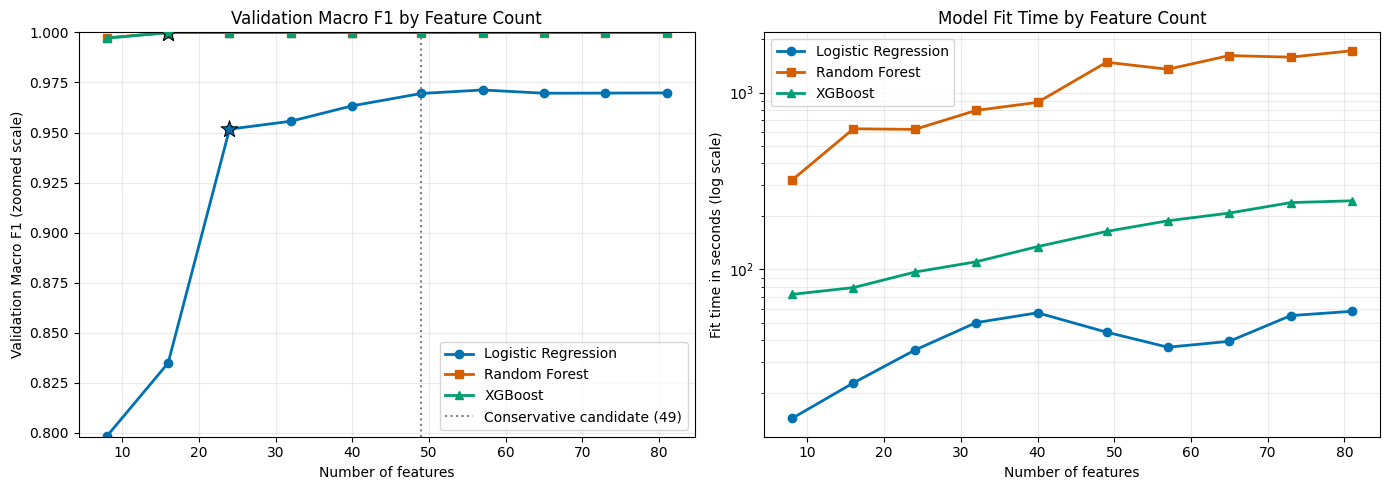

In [ ]:
# Compare the three validation curves and identify candidate knee points
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_ORDER = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

PERFORMANCE_TOLERANCE = 0.001

curve_sources = {
    "Logistic Regression":
        logistic_feature_curve_df,
    "Random Forest":
        random_forest_feature_curve_df,
    "XGBoost":
        xgboost_feature_curve_df
}

required_columns = {
    "Feature count",
    "Feature reduction (%)",
    "Macro F1",
    "Fit time (s)"
}

combined_curve_frames = []

for model_name in MODEL_ORDER:
    model_curve = curve_sources[model_name].copy()

    missing_columns = (
        required_columns - set(model_curve.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{model_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    model_curve["Model"] = model_name

    combined_curve_frames.append(
        model_curve[
            [
                "Model",
                "Feature count",
                "Feature reduction (%)",
                "Macro F1",
                "Fit time (s)"
            ]
        ]
    )

combined_validation_curve_df = (
    pd.concat(
        combined_curve_frames,
        ignore_index=True
    )
    .sort_values(
        ["Model", "Feature count"]
    )
    .reset_index(drop=True)
)


def calculate_geometric_knee(model_curve):
    ordered_curve = (
        model_curve
        .sort_values("Feature count")
        .reset_index(drop=True)
    )

    feature_counts = ordered_curve[
        "Feature count"
    ].to_numpy(dtype=float)

    macro_f1_scores = ordered_curve[
        "Macro F1"
    ].to_numpy(dtype=float)

    # Prevent minor fluctuations from moving the knee
    performance_envelope = np.maximum.accumulate(
        macro_f1_scores
    )

    x_range = (
        feature_counts.max()
        - feature_counts.min()
    )

    y_range = (
        performance_envelope.max()
        - performance_envelope.min()
    )

    if x_range == 0 or y_range == 0:
        return int(feature_counts[0]), 0.0

    normalised_x = (
        feature_counts - feature_counts.min()
    ) / x_range

    normalised_y = (
        performance_envelope
        - performance_envelope.min()
    ) / y_range

    knee_scores = normalised_y - normalised_x
    knee_index = int(np.argmax(knee_scores))

    return (
        int(feature_counts[knee_index]),
        float(knee_scores[knee_index])
    )


candidate_records = []

for model_name in MODEL_ORDER:
    model_curve = (
        combined_validation_curve_df[
            combined_validation_curve_df[
                "Model"
            ] == model_name
        ]
        .sort_values("Feature count")
        .reset_index(drop=True)
    )

    full_feature_row = model_curve.loc[
        model_curve["Feature count"].idxmax()
    ]

    best_observed_row = model_curve.loc[
        model_curve["Macro F1"].idxmax()
    ]

    full_feature_macro_f1 = float(
        full_feature_row["Macro F1"]
    )

    retention_threshold = (
        full_feature_macro_f1
        - PERFORMANCE_TOLERANCE
    )

    eligible_rows = model_curve[
        model_curve["Macro F1"]
        >= retention_threshold
    ].sort_values("Feature count")

    tolerance_row = eligible_rows.iloc[0]

    geometric_knee_count, knee_score = (
        calculate_geometric_knee(model_curve)
    )

    candidate_records.append(
        {
            "Model": model_name,
            "Full-feature Macro F1":
                full_feature_macro_f1,
            "Best observed feature count":
                int(best_observed_row["Feature count"]),
            "Best observed Macro F1":
                float(best_observed_row["Macro F1"]),
            "Geometric knee count":
                geometric_knee_count,
            "Geometric knee score":
                knee_score,
            "Tolerance candidate count":
                int(tolerance_row["Feature count"]),
            "Tolerance candidate Macro F1":
                float(tolerance_row["Macro F1"]),
            "Gap from full model":
                (
                    full_feature_macro_f1
                    - float(tolerance_row["Macro F1"])
                ),
            "Feature reduction at candidate (%)":
                float(
                    tolerance_row[
                        "Feature reduction (%)"
                    ]
                ),
            "Fit time at candidate (s)":
                float(tolerance_row["Fit time (s)"])
        }
    )

candidate_knee_summary_df = pd.DataFrame(
    candidate_records
)

cross_model_candidate_count = int(
    candidate_knee_summary_df[
        "Tolerance candidate count"
    ].max()
)

combined_validation_curve_df.to_csv(
    "/content/cross_model_validation_curves.csv",
    index=False
)

candidate_knee_summary_df.to_csv(
    "/content/candidate_knee_summary.csv",
    index=False
)

print(
    "Provisional cross-model candidate:",
    cross_model_candidate_count,
    "features"
)

display(candidate_knee_summary_df.round(6))


# Create thesis-ready validation figures
colour_map = {
    "Logistic Regression": "#0072B2",
    "Random Forest": "#D55E00",
    "XGBoost": "#009E73"
}

marker_map = {
    "Logistic Regression": "o",
    "Random Forest": "s",
    "XGBoost": "^"
}

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for model_name in MODEL_ORDER:
    model_curve = (
        combined_validation_curve_df[
            combined_validation_curve_df[
                "Model"
            ] == model_name
        ]
        .sort_values("Feature count")
    )

    axes[0].plot(
        model_curve["Feature count"],
        model_curve["Macro F1"],
        marker=marker_map[model_name],
        linewidth=2,
        markersize=6,
        color=colour_map[model_name],
        label=model_name
    )

    knee_count = int(
        candidate_knee_summary_df.loc[
            candidate_knee_summary_df[
                "Model"
            ] == model_name,
            "Geometric knee count"
        ].iloc[0]
    )

    knee_row = model_curve[
        model_curve["Feature count"]
        == knee_count
    ].iloc[0]

    axes[0].scatter(
        knee_row["Feature count"],
        knee_row["Macro F1"],
        marker="*",
        s=160,
        color=colour_map[model_name],
        edgecolor="black",
        linewidth=0.7,
        zorder=5
    )

    axes[1].plot(
        model_curve["Feature count"],
        model_curve["Fit time (s)"],
        marker=marker_map[model_name],
        linewidth=2,
        markersize=6,
        color=colour_map[model_name],
        label=model_name
    )

minimum_macro_f1 = float(
    combined_validation_curve_df[
        "Macro F1"
    ].min()
)

axes[0].axvline(
    cross_model_candidate_count,
    color="grey",
    linestyle=":",
    linewidth=1.5,
    label=(
        "Conservative candidate "
        f"({cross_model_candidate_count})"
    )
)

axes[0].set_ylim(
    max(0.0, minimum_macro_f1 - 0.0002),
    1.00005
)

axes[0].set_title(
    "Validation Macro F1 by Feature Count"
)
axes[0].set_xlabel("Number of features")
axes[0].set_ylabel(
    "Validation Macro F1 (zoomed scale)"
)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title(
    "Model Fit Time by Feature Count"
)
axes[1].set_xlabel("Number of features")
axes[1].set_ylabel(
    "Fit time in seconds (log scale)"
)
axes[1].set_yscale("log")
axes[1].grid(
    alpha=0.25,
    which="both"
)
axes[1].legend()

figure.tight_layout()

figure.savefig(
    "/content/cross_model_validation_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interim Summary of Progressive Feature-Reduction Findings

The progressive feature-reduction experiment evaluated Logistic Regression, Random Forest, and XGBoost across ten identical nested feature subsets ranging from 8 to 81 features. All comparisons used the same training and validation partitions, Mutual Information ranking, decision threshold, random seed, and evaluation metrics. The held-out test partition has not been used at this stage.

The results demonstrate a clear difference between the linear and tree-based classifiers. Logistic Regression was strongly affected by aggressive feature reduction. Its performance improved substantially as the feature count increased, reaching a geometric knee at 24 features and its highest observed validation Macro F1-score at 57 features. A minimum of 49 features was required for Logistic Regression to remain within 0.001 of its own 81-feature performance.

Random Forest and XGBoost were considerably more robust to feature reduction. Both models reached their geometric knee at only 16 features, corresponding to an 80.25% reduction from the original 81-feature space. Random Forest achieved a validation Macro F1-score of 0.999878 with 16 features, compared with 0.999948 when all 81 features were used. XGBoost achieved 0.999917 with 16 features and 0.999987 with all features. Therefore, the additional 65 features produced only marginal improvements for the two tree-based models.

The computational comparison also favours XGBoost. At 16 features, XGBoost required approximately 79 seconds for fitting, compared with approximately 624 seconds for Random Forest, while producing slightly stronger validation performance. Logistic Regression remained the fastest model but achieved substantially lower Macro F1-scores than the tree-based alternatives.

Overall, the findings indicate that most of the binary discriminatory information is concentrated within a relatively small group of highly ranked features. XGBoost currently provides the strongest predictive-performance and computational-cost trade-off. Nevertheless, the aggregate binary metrics cannot establish whether the reduced subsets detect every attack category reliably. The candidate feature counts of 16, 24, 49, and 81 will therefore be retained for further investigation, and the final operating point will be selected only after examining per-attack detection, rare-attack behaviour, robustness across random seeds, and held-out test performance.

### XGBoost Per-Attack Validation Across Feature Counts

XGBoost is selected for detailed per-attack analysis because it achieved the strongest validation performance–runtime trade-off. The selected configuration is refitted across the same ten nested feature subsets, using only the training and validation partitions. For each effective attack category, the detection rate is calculated as the proportion of its validation flows classified as malicious. Attempted-attack flows are excluded because they are treated as benign under the corrected dataset methodology. Attack categories representing less than 0.1% of the training partition are marked as rare. Wilson 95% confidence intervals are calculated because several rare categories contain very few observations. The held-out test partition remains untouched.

In [ ]:
# XGBoost per-attack validation across all feature counts
from xgboost import XGBClassifier
from time import perf_counter
import gc
import numpy as np
import pandas as pd

XGBOOST_DECISION_THRESHOLD = 0.5
RARE_ATTACK_PREVALENCE_THRESHOLD = 0.001
WILSON_Z_VALUE = 1.959963984540054

validation_attack_labels = np.char.strip(
    np.asarray(
        diagnostic_labels_validation
    ).astype(str)
)

if len(validation_attack_labels) != len(y_validation):
    raise ValueError(
        "Validation diagnostic labels do not match "
        "the binary validation target."
    )

if "diagnostic_labels_train" in globals():
    rarity_reference_labels = np.char.strip(
        np.asarray(
            diagnostic_labels_train
        ).astype(str)
    )
    rarity_reference_name = "training partition"
else:
    rarity_reference_labels = (
        validation_attack_labels.copy()
    )
    rarity_reference_name = "validation partition"

reference_label_counts = (
    pd.Series(rarity_reference_labels)
    .value_counts()
)


def is_effective_attack_label(label):
    normalised_label = label.strip().upper()

    return (
        normalised_label != "BENIGN"
        and "ATTEMPTED" not in normalised_label
    )


effective_attack_labels = sorted(
    label
    for label in np.unique(
        validation_attack_labels
    )
    if is_effective_attack_label(label)
)


def wilson_confidence_interval(
    detected_count,
    support_count,
    z_value=WILSON_Z_VALUE
):
    if support_count == 0:
        return np.nan, np.nan

    proportion = (
        detected_count / support_count
    )

    denominator = (
        1.0
        + (z_value ** 2) / support_count
    )

    centre = (
        proportion
        + (z_value ** 2)
        / (2.0 * support_count)
    ) / denominator

    half_width = (
        z_value
        * np.sqrt(
            (
                proportion
                * (1.0 - proportion)
                / support_count
            )
            + (
                z_value ** 2
                / (4.0 * support_count ** 2)
            )
        )
        / denominator
    )

    return (
        max(0.0, centre - half_width),
        min(1.0, centre + half_width)
    )


# Retain completed feature counts if the cell is resumed
if (
    "xgboost_per_attack_validation_df"
    in globals()
    and isinstance(
        xgboost_per_attack_validation_df,
        pd.DataFrame
    )
):
    xgboost_per_attack_records = (
        xgboost_per_attack_validation_df
        .to_dict("records")
    )
else:
    xgboost_per_attack_records = []

completed_per_attack_counts = {
    int(record["Feature count"])
    for record in xgboost_per_attack_records
}

for feature_count in np.asarray(
    initial_feature_counts,
    dtype=int
):
    feature_count = int(feature_count)

    if feature_count in completed_per_attack_counts:
        print(
            "Skipping completed per-attack count:",
            feature_count
        )
        continue

    print(
        f"XGBoost per-attack validation: "
        f"{feature_count}/81 features..."
    )

    selected_indices = np.asarray(
        ranked_feature_indices[:feature_count],
        dtype=int
    )

    per_attack_model = XGBClassifier(
        **selected_xgboost_parameters,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=PRIMARY_SEED,
        n_jobs=-1,
        verbosity=0
    )

    fit_start_time = perf_counter()

    per_attack_model.fit(
        X_train[:, selected_indices],
        y_train
    )

    fit_time_seconds = (
        perf_counter() - fit_start_time
    )

    validation_probability = (
        per_attack_model.predict_proba(
            X_validation[:, selected_indices]
        )[:, 1]
    )

    validation_prediction = (
        validation_probability
        >= XGBOOST_DECISION_THRESHOLD
    ).astype(np.int8)

    for attack_label in effective_attack_labels:
        attack_mask = (
            validation_attack_labels
            == attack_label
        )

        support_count = int(
            attack_mask.sum()
        )

        if support_count == 0:
            continue

        if not np.all(
            y_validation[attack_mask] == 1
        ):
            raise ValueError(
                f"Effective attack label "
                f"{attack_label!r} contains "
                f"non-attack binary targets."
            )

        detected_count = int(
            validation_prediction[
                attack_mask
            ].sum()
        )

        missed_count = (
            support_count - detected_count
        )

        detection_rate = (
            detected_count / support_count
        )

        confidence_lower, confidence_upper = (
            wilson_confidence_interval(
                detected_count,
                support_count
            )
        )

        reference_support = int(
            reference_label_counts.get(
                attack_label,
                0
            )
        )

        reference_prevalence = (
            reference_support
            / len(rarity_reference_labels)
        )

        is_rare_attack = bool(
            reference_prevalence
            < RARE_ATTACK_PREVALENCE_THRESHOLD
        )

        xgboost_per_attack_records.append(
            {
                "Model": "XGBoost",
                "Feature count": feature_count,
                "Feature reduction (%)": (
                    100.0
                    * (
                        1.0
                        - feature_count
                        / X_train.shape[1]
                    )
                ),
                "Attack label": attack_label,
                "Validation support":
                    support_count,
                "Detected flows":
                    detected_count,
                "Missed flows":
                    missed_count,
                "Detection rate":
                    detection_rate,
                "Wilson 95% lower":
                    confidence_lower,
                "Wilson 95% upper":
                    confidence_upper,
                "Rarity-reference support":
                    reference_support,
                "Rarity-reference prevalence":
                    reference_prevalence,
                "Rare attack":
                    is_rare_attack,
                "Fit time (s)":
                    fit_time_seconds,
                "Seed":
                    int(PRIMARY_SEED),
                "Threshold":
                    XGBOOST_DECISION_THRESHOLD
            }
        )

    completed_per_attack_counts.add(
        feature_count
    )

    xgboost_per_attack_validation_df = (
        pd.DataFrame(
            xgboost_per_attack_records
        )
        .sort_values(
            [
                "Feature count",
                "Attack label"
            ]
        )
        .reset_index(drop=True)
    )

    xgboost_per_attack_validation_df.to_csv(
        "/content/"
        "xgboost_per_attack_validation_progress.csv",
        index=False
    )

    completed_rows = (
        xgboost_per_attack_validation_df[
            xgboost_per_attack_validation_df[
                "Feature count"
            ] == feature_count
        ]
    )

    print(
        "Mean per-attack detection rate:",
        round(
            completed_rows[
                "Detection rate"
            ].mean(),
            6
        )
    )
    print(
        f"Progress saved after "
        f"{feature_count} features."
    )

    del per_attack_model
    del validation_probability
    del validation_prediction
    gc.collect()

print(
    "\nPer-attack validation completed."
)
print(
    "Rarity reference:",
    rarity_reference_name
)
print(
    "Effective attack categories:",
    len(effective_attack_labels)
)
print(
    "Feature counts completed:",
    sorted(completed_per_attack_counts)
)

XGBoost per-attack validation: 8/81 features...
Mean per-attack detection rate: 0.915422
Progress saved after 8 features.
XGBoost per-attack validation: 16/81 features...
Mean per-attack detection rate: 0.986523
Progress saved after 16 features.
XGBoost per-attack validation: 24/81 features...
Mean per-attack detection rate: 0.973193
Progress saved after 24 features.
XGBoost per-attack validation: 32/81 features...
Mean per-attack detection rate: 0.953318
Progress saved after 32 features.
XGBoost per-attack validation: 40/81 features...
Mean per-attack detection rate: 0.953321
Progress saved after 40 features.
XGBoost per-attack validation: 49/81 features...
Mean per-attack detection rate: 0.953318
Progress saved after 49 features.
XGBoost per-attack validation: 57/81 features...
Mean per-attack detection rate: 0.953324
Progress saved after 57 features.
XGBoost per-attack validation: 65/81 features...
Mean per-attack detection rate: 0.953324
Progress saved after 65 features.
XGBoost pe

In [ ]:
# Identify the available diagnostic-label variables
for variable_name, variable_value in sorted(
    globals().items()
):
    if (
        not variable_name.startswith("_")
        and any(
            word in variable_name.lower()
            for word in [
                "label",
                "diagnostic",
                "attack"
            ]
        )
    ):
        variable_shape = getattr(
            variable_value,
            "shape",
            None
        )

        print(
            f"{variable_name}: "
            f"{type(variable_value).__name__}, "
            f"shape={variable_shape}"
        )

RARE_ATTACK_PREVALENCE_THRESHOLD: float, shape=None
diagnostic_labels: Series, shape=(96641,)
diagnostic_labels_test: ndarray, shape=(312709,)
labels: Series, shape=(96641,)
modeling_label_counts: Counter, shape=None
modeling_labels: Series, shape=(96641,)
provided_label_counts: Counter, shape=None
provided_labels: Series, shape=(96641,)
stratification_labels: ndarray, shape=(2084721,)


In [ ]:
# Inspect the full stratification-label array
stratification_label_series = pd.Series(
    np.asarray(stratification_labels)
)

print(
    "Total labels:",
    len(stratification_label_series)
)
print(
    "Data type:",
    stratification_label_series.dtype
)
print("\nMost frequent values:")

display(
    stratification_label_series
    .value_counts()
    .head(25)
    .rename_axis("Label")
    .reset_index(name="Count")
)

Total labels: 2084721
Data type: object

Most frequent values:


,Label,Count
0,BENIGN,1582444
1,Portscan,159059
2,DoS Hulk,158468
3,DDoS,95144
4,Infiltration - Portscan,68620
5,DoS GoldenEye,7567
6,FTP-Patator,3972
7,DoS Slowloris,3859
8,SSH-Patator,2961
9,DoS Slowhttptest,1740


In [ ]:
# Reconstruct training and validation diagnostic attack labels
all_diagnostic_labels = np.char.strip(
    np.asarray(stratification_labels).astype(str)
)

total_row_count = len(all_diagnostic_labels)

training_reference_mask = np.ones(
    total_row_count,
    dtype=bool
)

training_reference_mask[
    np.asarray(validation_indices, dtype=int)
] = False

training_reference_mask[
    np.asarray(test_indices, dtype=int)
] = False

training_reference_indices = np.flatnonzero(
    training_reference_mask
)

diagnostic_labels_train = (
    all_diagnostic_labels[
        training_reference_indices
    ]
)

diagnostic_labels_validation = (
    all_diagnostic_labels[
        np.asarray(validation_indices, dtype=int)
    ]
)

expected_validation_target = (
    diagnostic_labels_validation != "BENIGN"
).astype(np.int8)

if len(diagnostic_labels_train) != len(y_train):
    raise ValueError(
        "Reconstructed training-label count "
        "does not match y_train."
    )

if not np.array_equal(
    expected_validation_target,
    y_validation
):
    raise ValueError(
        "The reconstructed validation labels "
        "do not match y_validation."
    )

print(
    "Training diagnostic labels:",
    diagnostic_labels_train.shape
)
print(
    "Validation diagnostic labels:",
    diagnostic_labels_validation.shape
)
print(
    "Validation labels match y_validation:",
    True
)
print(
    "Effective validation attack categories:",
    len(
        np.unique(
            diagnostic_labels_validation[
                diagnostic_labels_validation
                != "BENIGN"
            ]
        )
    )
)

Training diagnostic labels: (1459304,)
Validation diagnostic labels: (312708,)
Validation labels match y_validation: True
Effective validation attack categories: 15


### Per-Attack Detection Heatmap and Rare-Attack Summary

Per-attack detection rates are examined across all ten XGBoost feature subsets. An unweighted macro average gives equal importance to every effective attack category, while a support-weighted detection rate reflects the proportion of all malicious validation flows detected. Rare attacks are marked separately because their small validation support can produce large changes from only one or two missed flows. A heatmap is used to identify which attack categories benefit from, or deteriorate under, different levels of feature reduction. Wilson confidence intervals are retained for interpreting uncertain estimates from very small samples.

Rare-attack definition:
Training prevalence below 0.001

Attack-category metadata:


,Attack label,Validation support,Rarity-reference support,Rarity-reference prevalence,Rare attack
0,Heartbleed,2,8,0.000005,True
1,Web Attack - SQL Injection,2,9,0.000006,True
2,Web Attack - XSS,3,13,0.000009,True
3,Infiltration,5,25,0.000017,True
4,Web Attack - Brute Force,11,51,0.000035,True
5,Botnet,110,515,0.000353,True
6,DoS Slowhttptest,261,1218,0.000835,True
7,SSH-Patator,444,2073,0.001421,False
8,DoS Slowloris,579,2701,0.001851,False
9,FTP-Patator,596,2780,0.001905,False



Per-attack summary by feature count:


,Feature count,Macro per-attack detection rate,Support-weighted attack detection rate,Macro rare-attack detection rate,Support-weighted rare-attack detection rate,Lowest attack detection rate,Lowest-performing attack
0,8,0.915422,0.997398,0.820665,0.982234,0.5,Web Attack - SQL Injection
1,16,0.986523,0.999907,0.971429,0.997462,0.8,Infiltration
2,24,0.973193,0.999894,0.942857,0.994924,0.6,Infiltration
3,32,0.953318,0.999920,0.900000,0.994924,0.5,Web Attack - SQL Injection
4,40,0.953321,0.999934,0.900000,0.994924,0.5,Web Attack - SQL Injection
5,49,0.953318,0.999934,0.900000,0.994924,0.5,Web Attack - SQL Injection
6,57,0.953324,0.999947,0.900000,0.994924,0.5,Web Attack - SQL Injection
7,65,0.953324,0.999947,0.900000,0.994924,0.5,Web Attack - SQL Injection
8,73,0.986657,0.999960,0.971429,0.997462,0.8,Infiltration
9,81,0.986657,0.999960,0.971429,0.997462,0.8,Infiltration



Rare-attack results for candidate feature counts:


,Feature count,Attack label,Validation support,Detected flows,Missed flows,Detection rate,Wilson 95% lower,Wilson 95% upper
0,16,Botnet,110,110,0,1.0,0.966256,1.000000
1,24,Botnet,110,110,0,1.0,0.966256,1.000000
2,49,Botnet,110,110,0,1.0,0.966256,1.000000
3,81,Botnet,110,110,0,1.0,0.966256,1.000000
4,16,DoS Slowhttptest,261,261,0,1.0,0.985495,1.000000
5,24,DoS Slowhttptest,261,261,0,1.0,0.985495,1.000000
6,49,DoS Slowhttptest,261,261,0,1.0,0.985495,1.000000
7,81,DoS Slowhttptest,261,261,0,1.0,0.985495,1.000000
8,16,Heartbleed,2,2,0,1.0,0.342380,1.000000
9,24,Heartbleed,2,2,0,1.0,0.342380,1.000000


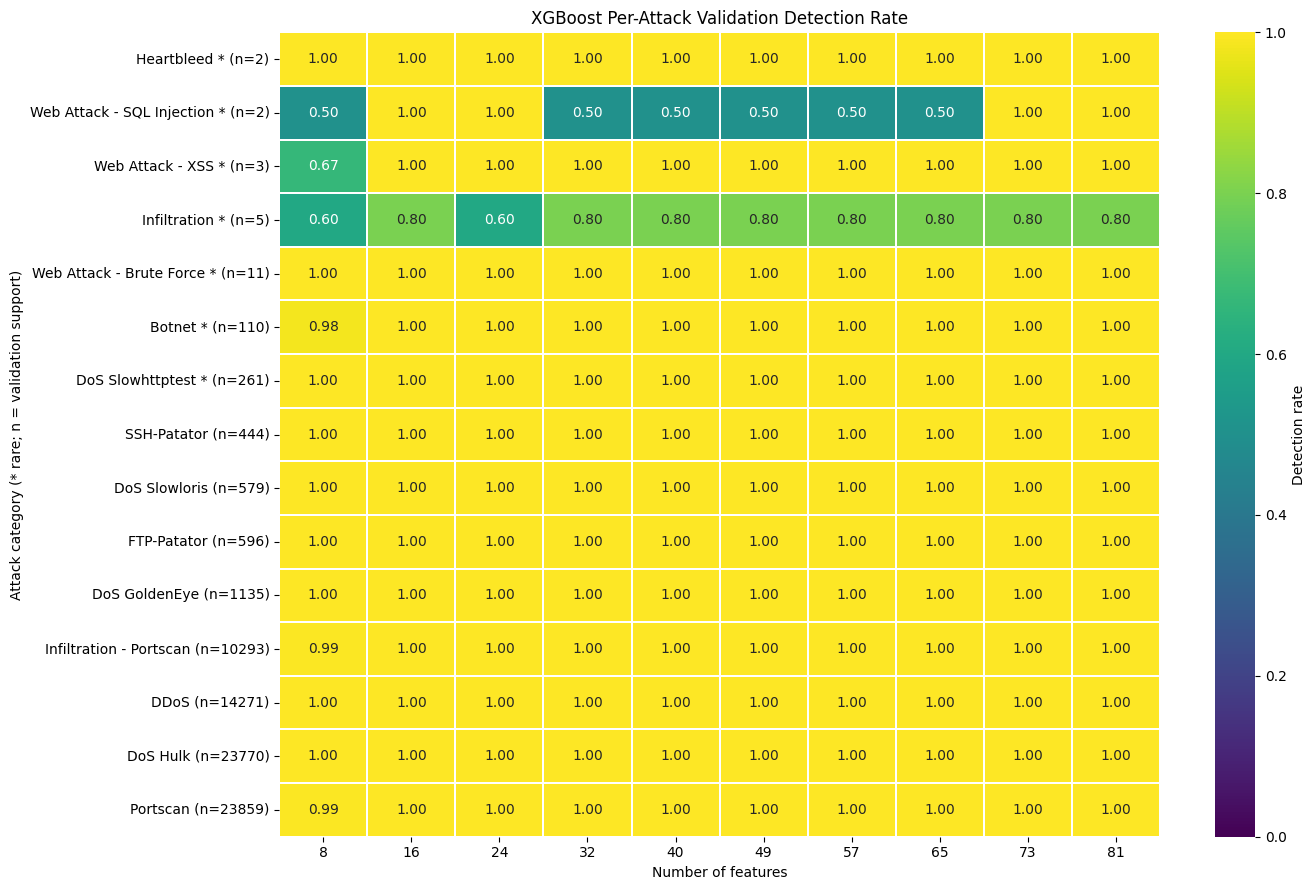

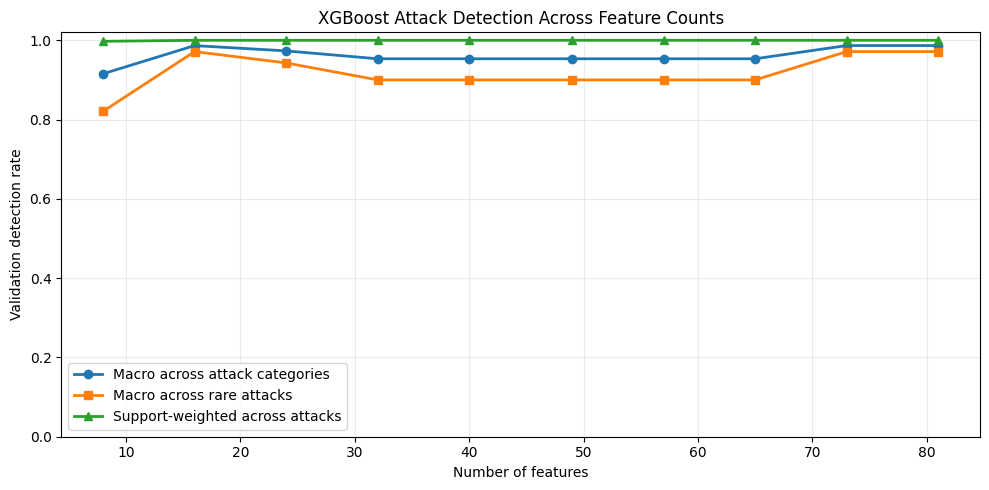

In [ ]:
# Summarise and visualise per-attack validation performance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

per_attack_results = (
    xgboost_per_attack_validation_df.copy()
)

per_attack_results["Rare attack"] = (
    per_attack_results["Rare attack"]
    .astype(bool)
)

feature_count_order = sorted(
    per_attack_results[
        "Feature count"
    ].astype(int).unique()
)

attack_metadata_df = (
    per_attack_results
    .sort_values("Feature count")
    .groupby(
        "Attack label",
        as_index=False
    )
    .first()[
        [
            "Attack label",
            "Validation support",
            "Rarity-reference support",
            "Rarity-reference prevalence",
            "Rare attack"
        ]
    ]
    .sort_values(
        [
            "Rare attack",
            "Rarity-reference prevalence"
        ],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

attack_order = attack_metadata_df[
    "Attack label"
].tolist()

attack_display_labels = {
    row["Attack label"]: (
        f"{row['Attack label']}"
        f"{' *' if row['Rare attack'] else ''}"
        f" (n={int(row['Validation support'])})"
    )
    for _, row in attack_metadata_df.iterrows()
}

summary_records = []

for feature_count in feature_count_order:
    feature_rows = per_attack_results[
        per_attack_results[
            "Feature count"
        ] == feature_count
    ]

    rare_rows = feature_rows[
        feature_rows["Rare attack"]
    ]

    total_support = int(
        feature_rows[
            "Validation support"
        ].sum()
    )

    total_detected = int(
        feature_rows[
            "Detected flows"
        ].sum()
    )

    rare_support = int(
        rare_rows[
            "Validation support"
        ].sum()
    )

    rare_detected = int(
        rare_rows[
            "Detected flows"
        ].sum()
    )

    lowest_row = feature_rows.loc[
        feature_rows[
            "Detection rate"
        ].idxmin()
    ]

    summary_records.append(
        {
            "Feature count":
                int(feature_count),
            "Macro per-attack detection rate":
                float(
                    feature_rows[
                        "Detection rate"
                    ].mean()
                ),
            "Support-weighted attack detection rate":
                (
                    total_detected
                    / total_support
                ),
            "Macro rare-attack detection rate":
                float(
                    rare_rows[
                        "Detection rate"
                    ].mean()
                ),
            "Support-weighted rare-attack detection rate":
                (
                    rare_detected
                    / rare_support
                    if rare_support > 0
                    else np.nan
                ),
            "Lowest attack detection rate":
                float(
                    lowest_row[
                        "Detection rate"
                    ]
                ),
            "Lowest-performing attack":
                lowest_row[
                    "Attack label"
                ]
        }
    )

per_attack_summary_df = pd.DataFrame(
    summary_records
)

candidate_feature_counts = [
    count
    for count in [16, 24, 49, 81]
    if count in feature_count_order
]

rare_candidate_results_df = (
    per_attack_results[
        per_attack_results[
            "Rare attack"
        ]
        & per_attack_results[
            "Feature count"
        ].isin(candidate_feature_counts)
    ][
        [
            "Feature count",
            "Attack label",
            "Validation support",
            "Detected flows",
            "Missed flows",
            "Detection rate",
            "Wilson 95% lower",
            "Wilson 95% upper"
        ]
    ]
    .sort_values(
        [
            "Attack label",
            "Feature count"
        ]
    )
    .reset_index(drop=True)
)

per_attack_summary_df.to_csv(
    "/content/xgboost_per_attack_summary.csv",
    index=False
)

rare_candidate_results_df.to_csv(
    "/content/xgboost_rare_attack_candidates.csv",
    index=False
)

print("Rare-attack definition:")
print(
    "Training prevalence below",
    RARE_ATTACK_PREVALENCE_THRESHOLD
)
print("\nAttack-category metadata:")

display(
    attack_metadata_df.round(6)
)

print("\nPer-attack summary by feature count:")

display(
    per_attack_summary_df.round(6)
)

print(
    "\nRare-attack results for "
    "candidate feature counts:"
)

display(
    rare_candidate_results_df.round(6)
)


# Heatmap of detection rate by attack and feature count
heatmap_data = (
    per_attack_results
    .pivot(
        index="Attack label",
        columns="Feature count",
        values="Detection rate"
    )
    .reindex(
        index=attack_order,
        columns=feature_count_order
    )
)

heatmap_data.index = [
    attack_display_labels[label]
    for label in heatmap_data.index
]

heatmap_figure, heatmap_axis = plt.subplots(
    figsize=(14, 9)
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.35,
    linecolor="white",
    cbar_kws={
        "label": "Detection rate"
    },
    ax=heatmap_axis
)

heatmap_axis.set_title(
    "XGBoost Per-Attack Validation Detection Rate"
)
heatmap_axis.set_xlabel(
    "Number of features"
)
heatmap_axis.set_ylabel(
    "Attack category "
    "(* rare; n = validation support)"
)

heatmap_figure.tight_layout()

heatmap_figure.savefig(
    "/content/"
    "xgboost_per_attack_detection_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Summary of overall and rare-attack behaviour
summary_figure, summary_axis = plt.subplots(
    figsize=(10, 5)
)

summary_axis.plot(
    per_attack_summary_df[
        "Feature count"
    ],
    per_attack_summary_df[
        "Macro per-attack detection rate"
    ],
    marker="o",
    linewidth=2,
    label="Macro across attack categories"
)

summary_axis.plot(
    per_attack_summary_df[
        "Feature count"
    ],
    per_attack_summary_df[
        "Macro rare-attack detection rate"
    ],
    marker="s",
    linewidth=2,
    label="Macro across rare attacks"
)

summary_axis.plot(
    per_attack_summary_df[
        "Feature count"
    ],
    per_attack_summary_df[
        "Support-weighted attack detection rate"
    ],
    marker="^",
    linewidth=2,
    label="Support-weighted across attacks"
)

summary_axis.set_ylim(0.0, 1.02)
summary_axis.set_title(
    "XGBoost Attack Detection Across Feature Counts"
)
summary_axis.set_xlabel(
    "Number of features"
)
summary_axis.set_ylabel(
    "Validation detection rate"
)
summary_axis.grid(alpha=0.25)
summary_axis.legend()

summary_figure.tight_layout()

summary_figure.savefig(
    "/content/"
    "xgboost_attack_detection_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Per-Attack Validation Findings

The per-attack analysis demonstrates why aggregate binary metrics alone are insufficient for feature-reduction assessment. Support-weighted attack detection remained above 0.9998 for nearly every feature subset because the largest attack categories were detected almost perfectly. In contrast, the unweighted per-attack and rare-attack measures revealed meaningful variation among the smallest attack categories.

The 16-feature XGBoost configuration produced the strongest reduced-feature result. It achieved a macro rare-attack detection rate of 0.971429 and a support-weighted overall attack detection rate of 0.999907. Its rare-attack detection profile was identical to the 81-feature configuration: every rare category was detected completely except Infiltration, for which four of five validation flows were identified. This result was obtained while reducing the feature space by 80.25%.

Increasing the feature count did not produce monotonic improvements. At 24 features, Infiltration detection declined from 0.80 to 0.60. Between 32 and 65 features, Web Attack – SQL Injection detection declined to 0.50 because one of its two validation flows was missed. Performance recovered at 73 and 81 features. These changes demonstrate that additional features can alter decision boundaries without necessarily improving category-level reliability.

The rare-category estimates must nevertheless be interpreted cautiously. Heartbleed and Web Attack – SQL Injection contain only two validation observations, Web Attack – XSS contains three, and Infiltration contains five. Their Wilson confidence intervals are consequently wide, meaning that one missed flow can produce a large change in the reported detection rate. Subject to robustness testing and final held-out evaluation, the 16-feature XGBoost configuration is retained as the provisional operating point.

### Per-Attack Analysis Checkpoint

The cross-model comparison, candidate knee-point analysis, and completed XGBoost per-attack validation results are saved in an updated checkpoint. This preserves the current analytical state before robustness testing and final held-out evaluation.

In [ ]:
# Save the completed cross-model and per-attack analyses
import pickle
from pathlib import Path
from google.colab import files
import pandas as pd

if "updated_progress" in globals():
    checkpoint_base = dict(updated_progress)
else:
    checkpoint_base = dict(restored_progress)

checkpoint_base.update(
    {
        "combined_validation_curve_df":
            combined_validation_curve_df.copy(),
        "candidate_knee_summary_df":
            candidate_knee_summary_df.copy(),
        "cross_model_candidate_count":
            cross_model_candidate_count,
        "xgboost_per_attack_records":
            xgboost_per_attack_records,
        "xgboost_per_attack_validation_df":
            xgboost_per_attack_validation_df.copy(),
        "per_attack_summary_df":
            per_attack_summary_df.copy(),
        "rare_candidate_results_df":
            rare_candidate_results_df.copy(),
        "provisional_xgboost_feature_count":
            16,
        "candidate_feature_counts":
            [16, 24, 49, 81],
        "saved_at_utc":
            pd.Timestamp.now(tz="UTC").isoformat()
    }
)

PER_ATTACK_PROGRESS_FILE = Path(
    "/content/thesis_progress_after_per_attack.pkl"
)

with open(
    PER_ATTACK_PROGRESS_FILE,
    "wb"
) as file:
    pickle.dump(
        checkpoint_base,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )

with open(
    PER_ATTACK_PROGRESS_FILE,
    "rb"
) as file:
    verified_progress = pickle.load(file)

verified_per_attack_df = verified_progress[
    "xgboost_per_attack_validation_df"
]

assert (
    verified_per_attack_df[
        "Feature count"
    ].nunique()
    == 10
)

assert (
    verified_per_attack_df[
        "Attack label"
    ].nunique()
    == 15
)

print("Per-attack checkpoint created successfully.")
print(
    "Feature counts:",
    verified_per_attack_df[
        "Feature count"
    ].nunique()
)
print(
    "Attack categories:",
    verified_per_attack_df[
        "Attack label"
    ].nunique()
)
print(
    "Provisional XGBoost operating point:",
    verified_progress[
        "provisional_xgboost_feature_count"
    ]
)
print(
    f"File size: "
    f"{PER_ATTACK_PROGRESS_FILE.stat().st_size / (1024**2):.2f} MB"
)

files.download(
    str(PER_ATTACK_PROGRESS_FILE)
)

Per-attack checkpoint created successfully.
Feature counts: 10
Attack categories: 15
Provisional XGBoost operating point: 16
File size: 37.00 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## XGBoost Robustness Across Random Seeds

The provisional 16-feature XGBoost configuration is compared with the full 81-feature baseline across five prespecified random seeds. The feature ranking, selected hyperparameters, decision threshold, and training–validation partitions remain unchanged. The held-out test partition is not accessed during this analysis.

This experiment evaluates whether the performance advantage of the reduced feature set is stable rather than dependent on a single stochastic model fit. Aggregate validation metrics and per-attack detection rates will be recorded for each seed. Mean performance, variability, confidence intervals, and paired differences between the 16-feature and 81-feature configurations will then be examined before final model selection.

In [ ]:
# XGBoost robustness experiment across five prespecified random seeds

from collections import Counter
from pathlib import Path
from time import perf_counter
from xgboost import XGBClassifier
import gc
import numpy as np
import pandas as pd

required_objects = [
    "X_train",
    "X_validation",
    "y_train",
    "y_validation",
    "ranked_feature_indices",
    "selected_xgboost_parameters",
    "calculate_binary_metrics",
    "diagnostic_labels_train",
    "diagnostic_labels_validation",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Missing objects required for the robustness experiment: "
        f"{missing_objects}"
    )


# Prespecified experimental settings
ROBUSTNESS_SEEDS = [7, 21, 42, 84, 123]
ROBUSTNESS_FEATURE_COUNTS = [16, 81]
ROBUSTNESS_DECISION_THRESHOLD = float(
    globals().get("DECISION_THRESHOLD", 0.5)
)

aggregate_progress_path = Path(
    "/content/xgboost_seed_robustness_progress.csv"
)
per_attack_progress_path = Path(
    "/content/xgboost_seed_per_attack_progress.csv"
)


# Restore any partially completed results from the active runtime
if aggregate_progress_path.exists():
    xgboost_seed_robustness_records = (
        pd.read_csv(aggregate_progress_path)
        .to_dict("records")
    )
else:
    xgboost_seed_robustness_records = list(
        globals().get(
            "xgboost_seed_robustness_records",
            []
        )
    )

if per_attack_progress_path.exists():
    xgboost_seed_per_attack_records = (
        pd.read_csv(per_attack_progress_path)
        .to_dict("records")
    )
else:
    xgboost_seed_per_attack_records = list(
        globals().get(
            "xgboost_seed_per_attack_records",
            []
        )
    )


# Define attack categories and rarity using the training partition
training_diagnostic_labels = np.char.strip(
    np.asarray(diagnostic_labels_train).astype(str)
)
validation_diagnostic_labels = np.char.strip(
    np.asarray(diagnostic_labels_validation).astype(str)
)

excluded_diagnostic_labels = {
    "BENIGN",
    "Attempted",
}

effective_attack_labels = sorted(
    label
    for label in np.unique(validation_diagnostic_labels)
    if label not in excluded_diagnostic_labels
)

training_label_counts = Counter(
    training_diagnostic_labels
)
training_reference_size = len(
    training_diagnostic_labels
)

rare_attack_lookup = {
    label: (
        training_label_counts.get(label, 0)
        / training_reference_size
        < 0.001
    )
    for label in effective_attack_labels
}


completed_pairs = {
    (
        int(record["Seed"]),
        int(record["Feature count"])
    )
    for record in xgboost_seed_robustness_records
}

print("Random seeds:", ROBUSTNESS_SEEDS)
print("Feature counts:", ROBUSTNESS_FEATURE_COUNTS)
print(
    "Decision threshold:",
    ROBUSTNESS_DECISION_THRESHOLD
)
print(
    "Attack categories:",
    len(effective_attack_labels)
)
print()


for seed in ROBUSTNESS_SEEDS:
    for feature_count in ROBUSTNESS_FEATURE_COUNTS:

        experiment_pair = (
            int(seed),
            int(feature_count)
        )

        if experiment_pair in completed_pairs:
            print(
                "Skipping completed experiment: "
                f"seed={seed}, features={feature_count}"
            )
            continue

        print(
            "XGBoost robustness experiment: "
            f"seed={seed}, "
            f"features={feature_count}/81..."
        )

        selected_indices = np.asarray(
            ranked_feature_indices[:feature_count],
            dtype=int
        )

        model_parameters = dict(
            selected_xgboost_parameters
        )
        model_parameters.update({
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "random_state": int(seed),
            "n_jobs": -1,
            "tree_method": "hist",
            "verbosity": 0,
        })

        robustness_model = XGBClassifier(
            **model_parameters
        )

        fit_start_time = perf_counter()

        robustness_model.fit(
            X_train[:, selected_indices],
            y_train
        )

        fit_time_seconds = (
            perf_counter() - fit_start_time
        )

        prediction_start_time = perf_counter()

        validation_probability = (
            robustness_model.predict_proba(
                X_validation[:, selected_indices]
            )[:, 1]
        )

        prediction_time_seconds = (
            perf_counter() - prediction_start_time
        )

        validation_prediction = (
            validation_probability
            >= ROBUSTNESS_DECISION_THRESHOLD
        ).astype(np.int8)

        validation_metrics = calculate_binary_metrics(
            y_validation,
            validation_prediction,
            validation_probability
        )

        aggregate_record = {
            "Seed": int(seed),
            "Feature count": int(feature_count),
            **validation_metrics,
            "Fit time (s)": fit_time_seconds,
            "Prediction time (s)":
                prediction_time_seconds,
        }

        xgboost_seed_robustness_records.append(
            aggregate_record
        )

        rare_detection_rates = []

        for attack_label in effective_attack_labels:
            attack_mask = (
                validation_diagnostic_labels
                == attack_label
            )

            validation_support = int(
                attack_mask.sum()
            )
            detected_flows = int(
                validation_prediction[
                    attack_mask
                ].sum()
            )
            detection_rate = (
                detected_flows
                / validation_support
                if validation_support > 0
                else np.nan
            )

            is_rare_attack = bool(
                rare_attack_lookup[attack_label]
            )

            if is_rare_attack:
                rare_detection_rates.append(
                    detection_rate
                )

            xgboost_seed_per_attack_records.append({
                "Seed": int(seed),
                "Feature count": int(feature_count),
                "Attack label": attack_label,
                "Validation support":
                    validation_support,
                "Detected flows": detected_flows,
                "Missed flows":
                    validation_support
                    - detected_flows,
                "Detection rate": detection_rate,
                "Rare attack": is_rare_attack,
            })

        mean_rare_detection_rate = float(
            np.mean(rare_detection_rates)
        )

        pd.DataFrame(
            xgboost_seed_robustness_records
        ).to_csv(
            aggregate_progress_path,
            index=False
        )

        pd.DataFrame(
            xgboost_seed_per_attack_records
        ).to_csv(
            per_attack_progress_path,
            index=False
        )

        completed_pairs.add(experiment_pair)

        print(
            "Validation Macro F1:",
            round(
                validation_metrics["Macro F1"],
                6
            )
        )
        print(
            "Mean rare-attack detection rate:",
            round(
                mean_rare_detection_rate,
                6
            )
        )
        print("Progress saved.\n")

        del robustness_model
        del validation_probability
        del validation_prediction
        gc.collect()


xgboost_seed_robustness_df = (
    pd.DataFrame(
        xgboost_seed_robustness_records
    )
    .sort_values(
        ["Seed", "Feature count"]
    )
    .reset_index(drop=True)
)

xgboost_seed_per_attack_df = (
    pd.DataFrame(
        xgboost_seed_per_attack_records
    )
    .sort_values(
        [
            "Seed",
            "Feature count",
            "Attack label",
        ]
    )
    .reset_index(drop=True)
)

print(
    "\nXGBoost random-seed robustness "
    "experiments completed."
)
print(
    "Aggregate experiments:",
    len(xgboost_seed_robustness_df)
)
print(
    "Per-attack records:",
    len(xgboost_seed_per_attack_df)
)

display(
    xgboost_seed_robustness_df[
        [
            "Seed",
            "Feature count",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)",
        ]
    ]
)

Random seeds: [7, 21, 42, 84, 123]
Feature counts: [16, 81]
Decision threshold: 0.5
Attack categories: 15

XGBoost robustness experiment: seed=7, features=16/81...
Validation Macro F1: 0.999921
Mean rare-attack detection rate: 0.971429
Progress saved.

XGBoost robustness experiment: seed=7, features=81/81...
Validation Macro F1: 0.999983
Mean rare-attack detection rate: 0.971429
Progress saved.

XGBoost robustness experiment: seed=21, features=16/81...
Validation Macro F1: 0.999917
Mean rare-attack detection rate: 0.971429
Progress saved.

XGBoost robustness experiment: seed=21, features=81/81...
Validation Macro F1: 0.999987
Mean rare-attack detection rate: 0.971429
Progress saved.

XGBoost robustness experiment: seed=42, features=16/81...
Validation Macro F1: 0.999917
Mean rare-attack detection rate: 0.971429
Progress saved.

XGBoost robustness experiment: seed=42, features=81/81...
Validation Macro F1: 0.999987
Mean rare-attack detection rate: 0.971429
Progress saved.

XGBoost robus

,Seed,Feature count,Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s)
0,7,16,0.999921,0.999926,0.999843,1.0,1.000000,0.000042,84.347767,3.718149
1,7,81,0.999983,0.999978,0.999965,1.0,0.999999,0.000004,264.051081,3.817581
2,21,16,0.999917,0.999928,0.999834,1.0,1.000000,0.000051,78.706993,3.825790
3,21,81,0.999987,0.999980,0.999974,1.0,0.999999,0.000000,263.201010,4.881212
4,42,16,0.999917,0.999928,0.999834,1.0,1.000000,0.000051,79.289685,3.720461
5,42,81,0.999987,0.999980,0.999974,1.0,0.999999,0.000000,257.005973,4.039337
6,84,16,0.999921,0.999930,0.999843,1.0,1.000000,0.000046,77.979207,3.708615
7,84,81,0.999974,0.999969,0.999948,1.0,0.999999,0.000008,258.797901,4.903670
8,123,16,0.999917,0.999924,0.999834,1.0,1.000000,0.000046,77.802427,5.350288
9,123,81,0.999983,0.999978,0.999965,1.0,0.999999,0.000004,261.413242,3.805143


In [ ]:
# Save the completed random-seed robustness experiment

import pickle
from pathlib import Path
from google.colab import files
import pandas as pd

if "checkpoint_base" in globals():
    seed_checkpoint = dict(checkpoint_base)
elif "updated_progress" in globals():
    seed_checkpoint = dict(updated_progress)
else:
    seed_checkpoint = dict(restored_progress)

seed_checkpoint.update({
    "xgboost_seed_robustness_records":
        xgboost_seed_robustness_records,
    "xgboost_seed_robustness_df":
        xgboost_seed_robustness_df.copy(),
    "xgboost_seed_per_attack_records":
        xgboost_seed_per_attack_records,
    "xgboost_seed_per_attack_df":
        xgboost_seed_per_attack_df.copy(),
    "ROBUSTNESS_SEEDS":
        list(ROBUSTNESS_SEEDS),
    "ROBUSTNESS_FEATURE_COUNTS":
        list(ROBUSTNESS_FEATURE_COUNTS),
    "ROBUSTNESS_DECISION_THRESHOLD":
        ROBUSTNESS_DECISION_THRESHOLD,
    "saved_at_utc":
        pd.Timestamp.now(tz="UTC").isoformat(),
})

SEED_PROGRESS_FILE = Path(
    "/content/thesis_progress_after_seed_robustness.pkl"
)

with open(SEED_PROGRESS_FILE, "wb") as file:
    pickle.dump(
        seed_checkpoint,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )

with open(SEED_PROGRESS_FILE, "rb") as file:
    verified_seed_checkpoint = pickle.load(file)

verified_aggregate_df = verified_seed_checkpoint[
    "xgboost_seed_robustness_df"
]
verified_per_attack_df = verified_seed_checkpoint[
    "xgboost_seed_per_attack_df"
]

assert len(verified_aggregate_df) == 10
assert len(verified_per_attack_df) == 150

print("Random-seed checkpoint created successfully.")
print(
    "Aggregate experiments:",
    len(verified_aggregate_df)
)
print(
    "Per-attack records:",
    len(verified_per_attack_df)
)
print(
    "Seeds:",
    sorted(
        verified_aggregate_df["Seed"]
        .astype(int)
        .unique()
        .tolist()
    )
)
print(
    "Feature counts:",
    sorted(
        verified_aggregate_df["Feature count"]
        .astype(int)
        .unique()
        .tolist()
    )
)
print(
    "File size:",
    f"{SEED_PROGRESS_FILE.stat().st_size / (1024**2):.2f} MB"
)

files.download(str(SEED_PROGRESS_FILE))

Random-seed checkpoint created successfully.
Aggregate experiments: 10
Per-attack records: 150
Seeds: [7, 21, 42, 84, 123]
Feature counts: [16, 81]
File size: 37.02 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Summarise robustness across random seeds

from scipy.stats import t as student_t
import numpy as np
import pandas as pd


def calculate_mean_confidence_interval(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    sample_size = len(values)
    mean_value = float(np.mean(values))

    if sample_size < 2:
        return {
            "Mean": mean_value,
            "Standard deviation": np.nan,
            "CI lower": np.nan,
            "CI upper": np.nan,
        }

    standard_deviation = float(
        np.std(values, ddof=1)
    )
    standard_error = (
        standard_deviation
        / np.sqrt(sample_size)
    )
    critical_value = student_t.ppf(
        0.975,
        df=sample_size - 1
    )
    margin = critical_value * standard_error

    return {
        "Mean": mean_value,
        "Standard deviation":
            standard_deviation,
        "CI lower": mean_value - margin,
        "CI upper": mean_value + margin,
    }


# Normalise the rare-attack indicator
per_attack_seed_results = (
    xgboost_seed_per_attack_df.copy()
)

if (
    per_attack_seed_results["Rare attack"].dtype
    != bool
):
    per_attack_seed_results["Rare attack"] = (
        per_attack_seed_results["Rare attack"]
        .astype(str)
        .str.lower()
        .eq("true")
    )


# Calculate macro and support-weighted rare-attack
# detection for every seed and feature count
rare_seed_records = []

for (
    seed,
    feature_count
), group in per_attack_seed_results.groupby(
    ["Seed", "Feature count"]
):
    rare_group = group[
        group["Rare attack"]
    ].copy()

    macro_rare_detection_rate = float(
        rare_group["Detection rate"].mean()
    )

    weighted_rare_detection_rate = float(
        np.average(
            rare_group["Detection rate"],
            weights=rare_group[
                "Validation support"
            ]
        )
    )

    rare_seed_records.append({
        "Seed": int(seed),
        "Feature count": int(feature_count),
        "Macro rare-attack detection rate":
            macro_rare_detection_rate,
        "Support-weighted rare-attack detection rate":
            weighted_rare_detection_rate,
    })

seed_rare_summary_df = pd.DataFrame(
    rare_seed_records
)


# Combine aggregate and rare-attack results
seed_level_robustness_df = (
    xgboost_seed_robustness_df.merge(
        seed_rare_summary_df,
        on=["Seed", "Feature count"],
        how="left",
        validate="one_to_one"
    )
)


# Summarise each feature configuration
summary_metrics = [
    "Macro F1",
    "Balanced Accuracy",
    "MCC",
    "Benign FPR",
    "Macro rare-attack detection rate",
    "Support-weighted rare-attack detection rate",
    "Fit time (s)",
    "Prediction time (s)",
]

summary_records = []

for feature_count, group in (
    seed_level_robustness_df.groupby(
        "Feature count"
    )
):
    summary_record = {
        "Feature count": int(feature_count),
        "Number of seeds": len(group),
    }

    for metric in summary_metrics:
        statistics = (
            calculate_mean_confidence_interval(
                group[metric]
            )
        )

        summary_record[
            f"{metric} mean"
        ] = statistics["Mean"]
        summary_record[
            f"{metric} standard deviation"
        ] = statistics["Standard deviation"]
        summary_record[
            f"{metric} 95% CI lower"
        ] = statistics["CI lower"]
        summary_record[
            f"{metric} 95% CI upper"
        ] = statistics["CI upper"]

    summary_records.append(summary_record)

seed_robustness_summary_df = (
    pd.DataFrame(summary_records)
    .sort_values("Feature count")
    .reset_index(drop=True)
)


# Calculate paired reduced-minus-full differences
paired_metrics = [
    "Macro F1",
    "Balanced Accuracy",
    "MCC",
    "Benign FPR",
    "Macro rare-attack detection rate",
    "Support-weighted rare-attack detection rate",
]

paired_difference_records = []

for metric in paired_metrics:
    metric_pivot = (
        seed_level_robustness_df.pivot(
            index="Seed",
            columns="Feature count",
            values=metric
        )
        .sort_index()
    )

    paired_differences = (
        metric_pivot[16]
        - metric_pivot[81]
    )

    statistics = (
        calculate_mean_confidence_interval(
            paired_differences
        )
    )

    paired_difference_records.append({
        "Metric": metric,
        "Mean difference (16 - 81)":
            statistics["Mean"],
        "Standard deviation":
            statistics["Standard deviation"],
        "95% CI lower":
            statistics["CI lower"],
        "95% CI upper":
            statistics["CI upper"],
    })

paired_seed_difference_df = pd.DataFrame(
    paired_difference_records
)


# Calculate the training-time speed-up for every seed
fit_time_pivot = (
    seed_level_robustness_df.pivot(
        index="Seed",
        columns="Feature count",
        values="Fit time (s)"
    )
    .sort_index()
)

seed_speedup_df = pd.DataFrame({
    "Seed": fit_time_pivot.index.astype(int),
    "Training speed-up (81 / 16)":
        fit_time_pivot[81]
        / fit_time_pivot[16],
}).reset_index(drop=True)

mean_training_speedup = float(
    seed_speedup_df[
        "Training speed-up (81 / 16)"
    ].mean()
)


print("Random-seed robustness summary:")
display(
    seed_robustness_summary_df[
        [
            "Feature count",
            "Number of seeds",
            "Macro F1 mean",
            "Macro F1 standard deviation",
            "Macro F1 95% CI lower",
            "Macro F1 95% CI upper",
            "Macro rare-attack detection rate mean",
            "Macro rare-attack detection rate standard deviation",
            "Fit time (s) mean",
            "Fit time (s) standard deviation",
        ]
    ].round(8)
)

print("\nPaired differences:")
display(
    paired_seed_difference_df.round(8)
)

print(
    "\nMean training speed-up with 16 features:",
    f"{mean_training_speedup:.2f}x"
)

display(
    seed_speedup_df.round(4)
)

Random-seed robustness summary:


,Feature count,Number of seeds,Macro F1 mean,Macro F1 standard deviation,Macro F1 95% CI lower,Macro F1 95% CI upper,Macro rare-attack detection rate mean,Macro rare-attack detection rate standard deviation,Fit time (s) mean,Fit time (s) standard deviation
0,16,5,0.999919,0.000002,0.999916,0.999922,0.957143,0.031944,79.625216,2.706017
1,81,5,0.999983,0.000005,0.999976,0.999989,0.965714,0.012778,260.893842,2.960973



Paired differences:


,Metric,Mean difference (16 - 81),Standard deviation,95% CI lower,95% CI upper
0,Macro F1,-0.000064,0.000007,-0.000073,-0.000055
1,Balanced Accuracy,-0.000050,0.000006,-0.000057,-0.000042
2,MCC,-0.000128,0.000015,-0.000146,-0.000109
3,Benign FPR,0.000044,0.000006,0.000036,0.000052
4,Macro rare-attack detection rate,-0.008571,0.037253,-0.054827,0.037684
5,Support-weighted rare-attack detection rate,0.000000,0.001795,-0.002228,0.002228



Mean training speed-up with 16 features: 3.28x


,Seed,Training speed-up (81 / 16)
0,7,3.1305
1,21,3.3441
2,42,3.2414
3,84,3.3188
4,123,3.3600


### Random-Seed Robustness Findings

The five-seed robustness experiment showed highly stable validation performance for both XGBoost configurations. The 16-feature model achieved a mean Macro F1-score of 0.999919 (standard deviation: 0.000002; 95% CI: 0.999916–0.999922), compared with 0.999983 for the full 81-feature model (standard deviation: 0.000005; 95% CI: 0.999976–0.999989).

The mean paired Macro F1 difference between the reduced and full configurations was −0.000064. Balanced accuracy and MCC showed similarly small reductions, while the benign false-positive rate increased by only 0.000044. Therefore, the full model was consistently but only marginally better on the aggregate validation measures. The Macro F1 difference remained far below the predefined tolerance of 0.001.

For rare attacks, the mean macro detection rate was 0.957143 with 16 features and 0.965714 with 81 features. The paired difference was −0.008571, but its 95% confidence interval crossed zero (−0.054827 to 0.037684), indicating that no consistent rare-attack advantage was demonstrated for either configuration across the five seeds. The support-weighted rare-attack detection difference was effectively zero. These results must be interpreted cautiously because several rare categories contain very few validation examples.

The mean fitting time decreased from 260.89 seconds with 81 features to 79.63 seconds with 16 features. Consequently, the reduced model was approximately 3.28 times faster while removing 80.25% of the original features.

Overall, the robustness analysis supports retaining the 16-feature XGBoost configuration as the provisional operating point. It preserves practically equivalent validation performance while substantially reducing computational cost. The held-out test partition remains untouched and will only be used after the remaining experimental-integrity checks and final model selection.

## Experimental Integrity and Cross-Partition Overlap Audit

The near-perfect validation results require explicit integrity checks before final model selection and held-out test evaluation. First, the saved partition indices are examined to confirm that the validation and test partitions are disjoint and that their complement has the expected training size.

The final 81-feature matrices are then converted into deterministic row fingerprints. These fingerprints are used to identify identical preprocessed feature vectors occurring within or across the training, validation, and test partitions. Validation labels are examined only to determine whether any feature-identical training and validation observations have contradictory binary targets. Test labels are not accessed during this audit.

The presence of repeated feature vectors does not automatically demonstrate data leakage, because network-flow datasets can legitimately contain identical observations. However, substantial cross-partition duplication could make randomly partitioned validation results overly optimistic and would require an additional sensitivity analysis. This audit is therefore used to determine whether further grouped or duplicate-aware evaluation is necessary before drawing final conclusions.

In [ ]:
# Audit partition integrity and identical feature rows across partitions

from pathlib import Path
import gc
import numpy as np
import pandas as pd


required_audit_objects = [
    "X_train",
    "X_validation",
    "X_test",
    "y_train",
    "y_validation",
    "validation_indices",
    "test_indices",
]

missing_audit_objects = [
    name for name in required_audit_objects
    if name not in globals()
]

if missing_audit_objects:
    raise NameError(
        "Missing objects required for the integrity audit: "
        f"{missing_audit_objects}"
    )



# 1. Verify the saved partition indices


total_observations = (
    len(X_train)
    + len(X_validation)
    + len(X_test)
)

validation_index_array = np.asarray(
    validation_indices,
    dtype=np.int64
)
test_index_array = np.asarray(
    test_indices,
    dtype=np.int64
)

unique_validation_indices = np.unique(
    validation_index_array
)
unique_test_indices = np.unique(
    test_index_array
)

shared_validation_test_indices = np.intersect1d(
    unique_validation_indices,
    unique_test_indices,
    assume_unique=True
)

validation_test_union = np.union1d(
    unique_validation_indices,
    unique_test_indices
)

implied_training_size = (
    total_observations
    - len(validation_test_union)
)

indices_within_bounds = bool(
    np.all(
        (validation_index_array >= 0)
        & (validation_index_array < total_observations)
    )
    and np.all(
        (test_index_array >= 0)
        & (test_index_array < total_observations)
    )
)

partition_integrity_passed = bool(
    len(validation_index_array)
    == len(unique_validation_indices)
    and len(test_index_array)
    == len(unique_test_indices)
    and len(shared_validation_test_indices) == 0
    and implied_training_size == len(X_train)
    and indices_within_bounds
)

partition_integrity_df = pd.DataFrame([{
    "Total observations": total_observations,
    "Training rows": len(X_train),
    "Validation rows": len(X_validation),
    "Test rows": len(X_test),
    "Duplicate validation indices":
        len(validation_index_array)
        - len(unique_validation_indices),
    "Duplicate test indices":
        len(test_index_array)
        - len(unique_test_indices),
    "Shared validation-test indices":
        len(shared_validation_test_indices),
    "Implied training-complement size":
        implied_training_size,
    "All indices within bounds":
        indices_within_bounds,
    "Partition integrity passed":
        partition_integrity_passed,
}])



# 2. Create deterministic 64-bit feature-row fingerprints


def fingerprint_matrix(
    matrix,
    partition_name,
    chunk_size=100_000
):
    matrix = np.asarray(matrix)
    fingerprints = np.empty(
        matrix.shape[0],
        dtype=np.uint64
    )

    for start in range(
        0,
        matrix.shape[0],
        chunk_size
    ):
        stop = min(
            start + chunk_size,
            matrix.shape[0]
        )

        matrix_chunk = pd.DataFrame(
            matrix[start:stop],
            copy=False
        )

        fingerprints[start:stop] = (
            pd.util.hash_pandas_object(
                matrix_chunk,
                index=False
            )
            .to_numpy(
                dtype=np.uint64,
                copy=False
            )
        )

        print(
            f"{partition_name}: "
            f"{stop:,}/{matrix.shape[0]:,} rows fingerprinted",
            end="\r"
        )

    print(
        f"{partition_name}: "
        f"{matrix.shape[0]:,} fingerprints completed."
    )

    return fingerprints


training_fingerprints = fingerprint_matrix(
    X_train,
    "Training"
)
validation_fingerprints = fingerprint_matrix(
    X_validation,
    "Validation"
)
test_fingerprints = fingerprint_matrix(
    X_test,
    "Test"
)



# 3. Measure within-partition duplication


training_unique, training_counts = np.unique(
    training_fingerprints,
    return_counts=True
)
validation_unique, validation_counts = np.unique(
    validation_fingerprints,
    return_counts=True
)
test_unique, test_counts = np.unique(
    test_fingerprints,
    return_counts=True
)


def create_duplicate_summary(
    partition_name,
    fingerprints,
    unique_fingerprints,
    fingerprint_counts
):
    duplicate_group_rows = int(
        fingerprint_counts[
            fingerprint_counts > 1
        ].sum()
    )
    redundant_rows = int(
        len(fingerprints)
        - len(unique_fingerprints)
    )

    return {
        "Partition": partition_name,
        "Total rows": len(fingerprints),
        "Unique fingerprints":
            len(unique_fingerprints),
        "Rows beyond first duplicate":
            redundant_rows,
        "Rows beyond first duplicate (%)":
            100 * redundant_rows
            / len(fingerprints),
        "Rows belonging to duplicate groups":
            duplicate_group_rows,
        "Rows belonging to duplicate groups (%)":
            100 * duplicate_group_rows
            / len(fingerprints),
    }


within_partition_duplicate_df = pd.DataFrame([
    create_duplicate_summary(
        "Training",
        training_fingerprints,
        training_unique,
        training_counts
    ),
    create_duplicate_summary(
        "Validation",
        validation_fingerprints,
        validation_unique,
        validation_counts
    ),
    create_duplicate_summary(
        "Test",
        test_fingerprints,
        test_unique,
        test_counts
    ),
])



# 4. Measure cross-partition fingerprint overlap


validation_matches_training = np.isin(
    validation_fingerprints,
    training_unique,
    assume_unique=False
)

test_matches_training = np.isin(
    test_fingerprints,
    training_unique,
    assume_unique=False
)

test_matches_validation = np.isin(
    test_fingerprints,
    validation_unique,
    assume_unique=False
)

training_validation_unique_union = np.union1d(
    training_unique,
    validation_unique
)

test_matches_training_or_validation = np.isin(
    test_fingerprints,
    training_validation_unique_union,
    assume_unique=False
)

shared_training_validation_fingerprints = (
    np.intersect1d(
        training_unique,
        validation_unique,
        assume_unique=True
    )
)

shared_training_test_fingerprints = (
    np.intersect1d(
        training_unique,
        test_unique,
        assume_unique=True
    )
)

shared_validation_test_fingerprints = (
    np.intersect1d(
        validation_unique,
        test_unique,
        assume_unique=True
    )
)


cross_partition_overlap_df = pd.DataFrame([
    {
        "Comparison":
            "Validation rows matching training",
        "Matching rows":
            int(validation_matches_training.sum()),
        "Partition rows":
            len(validation_fingerprints),
        "Matching rows (%)":
            100
            * validation_matches_training.mean(),
        "Shared unique fingerprints":
            len(
                shared_training_validation_fingerprints
            ),
    },
    {
        "Comparison":
            "Test rows matching training",
        "Matching rows":
            int(test_matches_training.sum()),
        "Partition rows":
            len(test_fingerprints),
        "Matching rows (%)":
            100
            * test_matches_training.mean(),
        "Shared unique fingerprints":
            len(
                shared_training_test_fingerprints
            ),
    },
    {
        "Comparison":
            "Test rows matching validation",
        "Matching rows":
            int(test_matches_validation.sum()),
        "Partition rows":
            len(test_fingerprints),
        "Matching rows (%)":
            100
            * test_matches_validation.mean(),
        "Shared unique fingerprints":
            len(
                shared_validation_test_fingerprints
            ),
    },
    {
        "Comparison":
            "Test rows matching training or validation",
        "Matching rows":
            int(
                test_matches_training_or_validation.sum()
            ),
        "Partition rows":
            len(test_fingerprints),
        "Matching rows (%)":
            100
            * test_matches_training_or_validation.mean(),
        "Shared unique fingerprints":
            np.nan,
    },
])



# 5. Check target consistency for shared train-validation rows
# Test labels are deliberately not accessed

if len(
    shared_training_validation_fingerprints
) > 0:
    shared_training_mask = np.isin(
        training_fingerprints,
        shared_training_validation_fingerprints
    )
    shared_validation_mask = np.isin(
        validation_fingerprints,
        shared_training_validation_fingerprints
    )

    shared_label_df = pd.concat(
        [
            pd.DataFrame({
                "Fingerprint":
                    training_fingerprints[
                        shared_training_mask
                    ],
                "Target":
                    np.asarray(y_train)[
                        shared_training_mask
                    ],
            }),
            pd.DataFrame({
                "Fingerprint":
                    validation_fingerprints[
                        shared_validation_mask
                    ],
                "Target":
                    np.asarray(y_validation)[
                        shared_validation_mask
                    ],
            }),
        ],
        ignore_index=True
    )

    shared_target_ranges = (
        shared_label_df.groupby(
            "Fingerprint"
        )["Target"]
        .agg(["min", "max"])
    )

    conflicting_fingerprints = (
        shared_target_ranges.index[
            shared_target_ranges["min"]
            != shared_target_ranges["max"]
        ]
        .to_numpy(dtype=np.uint64)
    )

    validation_rows_with_conflicting_target = int(
        np.isin(
            validation_fingerprints,
            conflicting_fingerprints
        ).sum()
    )
else:
    conflicting_fingerprints = np.array(
        [],
        dtype=np.uint64
    )
    validation_rows_with_conflicting_target = 0


target_consistency_df = pd.DataFrame([{
    "Shared train-validation fingerprints":
        len(shared_training_validation_fingerprints),
    "Fingerprints with contradictory targets":
        len(conflicting_fingerprints),
    "Validation rows linked to contradictory targets":
        validation_rows_with_conflicting_target,
    "Test labels accessed": False,
}])


# Save the compact audit tables in the active runtime
partition_integrity_df.to_csv(
    "/content/partition_integrity_audit.csv",
    index=False
)
within_partition_duplicate_df.to_csv(
    "/content/within_partition_duplicate_audit.csv",
    index=False
)
cross_partition_overlap_df.to_csv(
    "/content/cross_partition_overlap_audit.csv",
    index=False
)
target_consistency_df.to_csv(
    "/content/train_validation_target_consistency_audit.csv",
    index=False
)


print("\nPartition integrity:")
display(partition_integrity_df)

print("\nWithin-partition duplicate fingerprints:")
display(
    within_partition_duplicate_df.round(6)
)

print("\nCross-partition overlap:")
display(
    cross_partition_overlap_df.round(6)
)

print("\nTrain-validation target consistency:")
display(target_consistency_df)

gc.collect()

Training: 1,459,304 fingerprints completed.
Validation: 312,708 fingerprints completed.
Test: 312,709 fingerprints completed.

Partition integrity:


,Total observations,Training rows,Validation rows,Test rows,Duplicate validation indices,Duplicate test indices,Shared validation-test indices,Implied training-complement size,All indices within bounds,Partition integrity passed
0,2084721,1459304,312708,312709,0,0,0,1459304,True,True



Within-partition duplicate fingerprints:


,Partition,Total rows,Unique fingerprints,Rows beyond first duplicate,Rows beyond first duplicate (%),Rows belonging to duplicate groups,Rows belonging to duplicate groups (%)
0,Training,1459304,1459104,200,0.013705,358,0.024532
1,Validation,312708,312695,13,0.004157,26,0.008314
2,Test,312709,312699,10,0.003198,18,0.005756



Cross-partition overlap:


,Comparison,Matching rows,Partition rows,Matching rows (%),Shared unique fingerprints
0,Validation rows matching training,67,312708,0.021426,61.0
1,Test rows matching training,65,312709,0.020786,60.0
2,Test rows matching validation,12,312709,0.003837,12.0
3,Test rows matching training or validation,71,312709,0.022705,NaN



Train-validation target consistency:


,Shared train-validation fingerprints,Fingerprints with contradictory targets,Validation rows linked to contradictory targets,Test labels accessed
0,61,0,0,False


0

### Experimental Integrity Audit Findings

The saved partition indices passed all integrity checks. The validation and test indices were unique, mutually disjoint, within the expected range, and their complement contained exactly the 1,459,304 training observations.

Within-partition repetition was very limited. Only 200 training rows (0.0137%), 13 validation rows (0.0042%), and 10 test rows (0.0032%) occurred beyond the first observation with the same 81-feature fingerprint.

Cross-partition overlap was also negligible. Sixty-seven validation observations, representing 0.0214% of the validation partition, matched a training fingerprint. Sixty-five test observations matched training fingerprints, while the total number of test observations matching either training or validation was 71, corresponding to 0.0227% of the test partition. No test labels were accessed during this audit.

The 61 fingerprints shared between training and validation had fully consistent binary targets, with no contradictory labels. Therefore, the near-perfect validation performance cannot reasonably be attributed to substantial exact cross-partition duplication. Nevertheless, because some individual attack categories have very small support, the diagnostic labels of the 67 overlapping validation observations will be inspected before the overlap is considered methodologically negligible.

In [ ]:
# Inspect the diagnostic labels of validation rows
# whose feature fingerprints also occur in training

validation_diagnostic_array = np.char.strip(
    np.asarray(
        diagnostic_labels_validation
    ).astype(str)
)

if (
    len(validation_diagnostic_array)
    != len(validation_fingerprints)
):
    raise ValueError(
        "Validation diagnostic labels and fingerprints "
        "do not have the same length."
    )

overlapping_validation_labels = (
    validation_diagnostic_array[
        validation_matches_training
    ]
)

overlapping_validation_targets = (
    np.asarray(y_validation)[
        validation_matches_training
    ]
)

validation_label_support = (
    pd.Series(
        validation_diagnostic_array,
        name="Diagnostic label"
    )
    .value_counts()
)

overlap_label_counts = (
    pd.Series(
        overlapping_validation_labels,
        name="Diagnostic label"
    )
    .value_counts()
)

overlap_label_records = []

for diagnostic_label, overlap_count in (
    overlap_label_counts.items()
):
    total_label_support = int(
        validation_label_support[
            diagnostic_label
        ]
    )

    is_rare_attack = bool(
        rare_attack_lookup.get(
            diagnostic_label,
            False
        )
    )

    overlap_label_records.append({
        "Diagnostic label":
            diagnostic_label,
        "Overlapping validation rows":
            int(overlap_count),
        "Total validation support":
            total_label_support,
        "Category overlap (%)":
            100
            * int(overlap_count)
            / total_label_support,
        "Share of all overlapping rows (%)":
            100
            * int(overlap_count)
            / len(overlapping_validation_labels),
        "Rare attack":
            is_rare_attack,
    })

validation_overlap_label_df = (
    pd.DataFrame(overlap_label_records)
    .sort_values(
        [
            "Overlapping validation rows",
            "Diagnostic label",
        ],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

overlap_binary_target_df = (
    pd.Series(
        overlapping_validation_targets,
        name="Binary target"
    )
    .value_counts()
    .sort_index()
    .rename_axis("Binary target")
    .reset_index(name="Overlapping rows")
)

rare_overlap_rows = int(
    validation_overlap_label_df.loc[
        validation_overlap_label_df[
            "Rare attack"
        ],
        "Overlapping validation rows"
    ].sum()
)

print(
    "Total overlapping validation rows:",
    len(overlapping_validation_labels)
)
print(
    "Rare-attack rows among the overlap:",
    rare_overlap_rows
)

print("\nDiagnostic-label distribution:")
display(
    validation_overlap_label_df.round(6)
)

print("\nBinary-target distribution:")
display(overlap_binary_target_df)

validation_overlap_label_df.to_csv(
    "/content/validation_overlap_label_audit.csv",
    index=False
)

Total overlapping validation rows: 67
Rare-attack rows among the overlap: 0

Diagnostic-label distribution:


,Diagnostic label,Overlapping validation rows,Total validation support,Category overlap (%),Share of all overlapping rows (%),Rare attack
0,BENIGN,67,237367,0.028226,100.0,False



Binary-target distribution:


,Binary target,Overlapping rows
0,0,67


#### Overlap Composition and Methodological Decision

All 67 validation observations whose feature fingerprints also occurred in the training partition were labelled BENIGN. They represented only 0.0282% of the 237,367 benign validation observations. No attack observations, including no rare attacks, were present in the train–validation overlap.

Consequently, the observed overlap cannot inflate attack-detection rates or explain the strong rare-attack results. Its potential effect on the benign false-positive rate is also negligible because of its extremely small proportion. A duplicate-exclusion model-retraining experiment was therefore considered unnecessary. The overlap is documented transparently, while the original prespecified partitions are retained for consistency with all preceding experiments.

## Feature-Level Leakage and Shortcut Audit

A final feature-level audit is performed before accessing the held-out test partition. The 81 retained feature names are inspected for explicit outcome variables, attack labels, flow identifiers, IP addresses, timestamps, or other fields that could directly reveal the target. Source and destination ports and protocol are treated separately as shortcut-sensitive behavioural variables because they may legitimately describe network activity while also encoding dataset-specific attack patterns.

Each feature is then evaluated individually on the validation partition using a direction-neutral ROC-AUC score. Training-class value ranges are also examined to determine whether any single feature provides perfect numerical separation between benign and attack observations. This analysis does not use the test partition.

High univariate predictive power does not by itself demonstrate leakage. Some network-flow statistics can be genuinely discriminative. However, an explicit label-related column, perfect single-feature class separation, or an unexplained near-deterministic proxy would require investigation before the final model could be considered methodologically reliable.

In [ ]:
# Audit retained features for explicit leakage and strong univariate proxies

from sklearn.metrics import roc_auc_score
import gc
import re
import numpy as np
import pandas as pd


required_feature_audit_objects = [
    "X_train",
    "X_validation",
    "y_train",
    "y_validation",
    "feature_names",
    "ranked_feature_indices",
]

missing_feature_audit_objects = [
    name for name in required_feature_audit_objects
    if name not in globals()
]

if missing_feature_audit_objects:
    raise NameError(
        "Missing objects required for the feature audit: "
        f"{missing_feature_audit_objects}"
    )


feature_name_array = np.asarray(
    feature_names
).astype(str)

if (
    X_train.shape[1] != len(feature_name_array)
    or X_validation.shape[1]
    != len(feature_name_array)
):
    raise ValueError(
        "Feature-name and matrix dimensions do not match."
    )

training_target = np.asarray(
    y_train,
    dtype=np.int8
)
validation_target = np.asarray(
    y_validation,
    dtype=np.int8
)

training_benign_mask = training_target == 0
training_attack_mask = training_target == 1


def normalise_feature_name(feature_name):
    normalised_name = feature_name.lower()
    normalised_name = re.sub(
        r"[_\-]+",
        " ",
        normalised_name
    )
    normalised_name = re.sub(
        r"\s+",
        " ",
        normalised_name
    )
    return normalised_name.strip()


explicit_outcome_or_identifier_names = {
    "label",
    "attack label",
    "binary label",
    "target",
    "binary target",
    "class",
    "class label",
    "row id",
    "flow id",
    "source ip",
    "destination ip",
    "src ip",
    "dst ip",
    "timestamp",
    "time stamp",
}

shortcut_sensitive_names = {
    "source port",
    "destination port",
    "src port",
    "dst port",
    "protocol",
}


# Recover Mutual Information values when available
mutual_information_lookup = {}

if "mutual_information_df" in globals():
    mi_columns = {
        str(column).lower(): column
        for column in mutual_information_df.columns
    }

    feature_column = mi_columns.get("feature")
    mi_score_column = mi_columns.get(
        "mutual information"
    )

    if (
        feature_column is not None
        and mi_score_column is not None
    ):
        mutual_information_lookup = dict(
            zip(
                mutual_information_df[
                    feature_column
                ].astype(str),
                mutual_information_df[
                    mi_score_column
                ].astype(float)
            )
        )


# Convert the saved ranking into one-based positions
ranking_positions = np.empty(
    len(feature_name_array),
    dtype=int
)

ranking_positions[
    np.asarray(
        ranked_feature_indices,
        dtype=int
    )
] = np.arange(
    1,
    len(feature_name_array) + 1
)

selected_16_indices = set(
    np.asarray(
        ranked_feature_indices[:16],
        dtype=int
    ).tolist()
)


feature_audit_records = []

for feature_index, feature_name in enumerate(
    feature_name_array
):
    normalised_name = normalise_feature_name(
        feature_name
    )

    explicit_name_flag = bool(
        normalised_name
        in explicit_outcome_or_identifier_names
        or "timestamp" in normalised_name
        or normalised_name.endswith(" label")
    )

    shortcut_sensitive_flag = bool(
        normalised_name
        in shortcut_sensitive_names
    )

    training_feature = np.asarray(
        X_train[:, feature_index]
    )
    validation_feature = np.asarray(
        X_validation[:, feature_index]
    )

    benign_values = training_feature[
        training_benign_mask
    ]
    attack_values = training_feature[
        training_attack_mask
    ]

    benign_minimum = float(
        np.min(benign_values)
    )
    benign_maximum = float(
        np.max(benign_values)
    )
    attack_minimum = float(
        np.min(attack_values)
    )
    attack_maximum = float(
        np.max(attack_values)
    )

    higher_attack_separation = bool(
        benign_maximum < attack_minimum
    )
    lower_attack_separation = bool(
        attack_maximum < benign_minimum
    )

    perfect_training_range_separation = bool(
        higher_attack_separation
        or lower_attack_separation
    )

    if np.unique(validation_feature).size < 2:
        raw_validation_auc = 0.5
    else:
        raw_validation_auc = float(
            roc_auc_score(
                validation_target,
                validation_feature
            )
        )

    direction_neutral_auc = max(
        raw_validation_auc,
        1.0 - raw_validation_auc
    )

    if raw_validation_auc >= 0.5:
        predictive_direction = (
            "Higher values associated with attack"
        )
    else:
        predictive_direction = (
            "Lower values associated with attack"
        )

    if explicit_name_flag:
        audit_flag = (
            "Explicit outcome/identifier name"
        )
    elif shortcut_sensitive_flag:
        audit_flag = (
            "Shortcut-sensitive behavioural field"
        )
    elif perfect_training_range_separation:
        audit_flag = (
            "Perfect training-range separation"
        )
    elif direction_neutral_auc >= 0.999:
        audit_flag = (
            "Near-deterministic univariate signal"
        )
    else:
        audit_flag = "No direct proxy flag"

    feature_audit_records.append({
        "Feature": feature_name,
        "Feature index": feature_index,
        "MI rank":
            int(ranking_positions[feature_index]),
        "Mutual Information":
            mutual_information_lookup.get(
                feature_name,
                np.nan
            ),
        "Direction-neutral validation ROC-AUC":
            direction_neutral_auc,
        "Predictive direction":
            predictive_direction,
        "Perfect training-range separation":
            perfect_training_range_separation,
        "Explicit outcome/identifier name":
            explicit_name_flag,
        "Shortcut-sensitive behavioural field":
            shortcut_sensitive_flag,
        "Included in top 16":
            feature_index in selected_16_indices,
        "Audit flag": audit_flag,
    })

    print(
        "Features audited:",
        f"{feature_index + 1}/{len(feature_name_array)}",
        end="\r"
    )

    del training_feature
    del validation_feature
    del benign_values
    del attack_values


print(
    "Features audited:",
    f"{len(feature_name_array)}/{len(feature_name_array)}"
)

feature_leakage_audit_df = (
    pd.DataFrame(feature_audit_records)
    .sort_values(
        [
            "Direction-neutral validation ROC-AUC",
            "Mutual Information",
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

feature_name_flags_df = (
    feature_leakage_audit_df[
        feature_leakage_audit_df[
            "Explicit outcome/identifier name"
        ]
        | feature_leakage_audit_df[
            "Shortcut-sensitive behavioural field"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

perfect_separation_features_df = (
    feature_leakage_audit_df[
        feature_leakage_audit_df[
            "Perfect training-range separation"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

near_deterministic_features_df = (
    feature_leakage_audit_df[
        feature_leakage_audit_df[
            "Direction-neutral validation ROC-AUC"
        ] >= 0.999
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "\nExplicit outcome/identifier features:",
    int(
        feature_leakage_audit_df[
            "Explicit outcome/identifier name"
        ].sum()
    )
)
print(
    "Shortcut-sensitive behavioural features:",
    int(
        feature_leakage_audit_df[
            "Shortcut-sensitive behavioural field"
        ].sum()
    )
)
print(
    "Features with perfect training-range separation:",
    len(perfect_separation_features_df)
)
print(
    "Features with univariate ROC-AUC >= 0.999:",
    len(near_deterministic_features_df)
)
print("Test partition accessed: False")


print("\nName-based flags:")
display(
    feature_name_flags_df[
        [
            "Feature",
            "MI rank",
            "Direction-neutral validation ROC-AUC",
            "Included in top 16",
            "Audit flag",
        ]
    ].round(6)
)


print("\nTop 15 individual features by validation ROC-AUC:")
display(
    feature_leakage_audit_df[
        [
            "Feature",
            "MI rank",
            "Mutual Information",
            "Direction-neutral validation ROC-AUC",
            "Predictive direction",
            "Perfect training-range separation",
            "Shortcut-sensitive behavioural field",
            "Included in top 16",
            "Audit flag",
        ]
    ]
    .head(15)
    .round(6)
)


if len(perfect_separation_features_df) > 0:
    print(
        "\nFeatures with perfect training-range separation:"
    )
    display(
        perfect_separation_features_df[
            [
                "Feature",
                "MI rank",
                "Direction-neutral validation ROC-AUC",
                "Included in top 16",
                "Audit flag",
            ]
        ].round(6)
    )


feature_leakage_audit_df.to_csv(
    "/content/feature_leakage_and_proxy_audit.csv",
    index=False
)

gc.collect()

Features audited: 81/81

Explicit outcome/identifier features: 0
Shortcut-sensitive behavioural features: 3
Features with perfect training-range separation: 0
Features with univariate ROC-AUC >= 0.999: 0
Test partition accessed: False

Name-based flags:


,Feature,MI rank,Direction-neutral validation ROC-AUC,Included in top 16,Audit flag
0,Protocol,41,0.810960,False,Shortcut-sensitive behavioural field
1,Dst Port,12,0.787825,True,Shortcut-sensitive behavioural field
2,Src Port,42,0.606679,False,Shortcut-sensitive behavioural field



Top 15 individual features by validation ROC-AUC:


,Feature,MI rank,Mutual Information,Direction-neutral validation ROC-AUC,Predictive direction,Perfect training-range separation,Shortcut-sensitive behavioural field,Included in top 16,Audit flag
0,RST Flag Count,19,0.319277,0.900408,Higher values associated with attack,False,False,False,No direct proxy flag
1,Fwd Seg Size Min,24,0.280812,0.847964,Higher values associated with attack,False,False,False,No direct proxy flag
2,Packet Length Min,37,0.193198,0.812219,Lower values associated with attack,False,False,False,No direct proxy flag
3,Fwd Packet Length Min,36,0.193403,0.811801,Lower values associated with attack,False,False,False,No direct proxy flag
4,Bwd Packet Length Min,40,0.189315,0.811378,Lower values associated with attack,False,False,False,No direct proxy flag
5,Protocol,41,0.188693,0.810960,Lower values associated with attack,False,True,False,Shortcut-sensitive behavioural field
6,FWD Init Win Bytes,21,0.308149,0.789815,Higher values associated with attack,False,False,False,No direct proxy flag
7,Dst Port,12,0.398469,0.787825,Higher values associated with attack,False,True,True,Shortcut-sensitive behavioural field
8,SYN Flag Count,28,0.256768,0.774687,Higher values associated with attack,False,False,False,No direct proxy flag
9,Fwd Packet Length Mean,17,0.350286,0.765784,Lower values associated with attack,False,False,False,No direct proxy flag


0

### Feature-Level Leakage and Shortcut Audit Findings

No retained feature had an explicit outcome, attack-label, row-identifier, IP-address, Flow-ID, or timestamp-related name. Furthermore, no individual feature produced perfect numerical separation between benign and attack observations in the training partition, and no feature achieved a direction-neutral validation ROC-AUC of 0.999 or higher.

The strongest individual feature was `RST Flag Count`, with a validation ROC-AUC of 0.900408. This indicates substantial legitimate discriminatory information but remains far below the near-perfect performance obtained by the multivariate XGBoost model. The result therefore suggests that the model's performance arises from combinations of network-flow characteristics rather than from a single deterministic label proxy.

Three retained variables were classified as shortcut-sensitive behavioural fields. `Protocol` achieved a univariate ROC-AUC of 0.810960, `Dst Port` achieved 0.787825, and `Src Port` achieved 0.606679. Only `Dst Port`, ranked twelfth by Mutual Information, was included in the provisional 16-feature subset. Ports and protocol are legitimate network-flow descriptors, but their predictive relationships may be specific to the collection environment.

A controlled validation ablation will therefore remove all source-port, destination-port, and protocol variables from the feature-ranking sequence. The resulting 16-feature XGBoost model will be compared with the original 16-feature candidate using the primary random seed. This provides an additional check that the reported performance is not dependent on shortcut-sensitive connection metadata.

In [ ]:
# Primary-seed ablation of shortcut-sensitive behavioural fields

from time import perf_counter
from xgboost import XGBClassifier
import gc
import numpy as np
import pandas as pd


PRIMARY_ABLATION_SEED = 42
ABLATION_FEATURE_COUNT = 16

shortcut_sensitive_indices = set(
    feature_leakage_audit_df.loc[
        feature_leakage_audit_df[
            "Shortcut-sensitive behavioural field"
        ],
        "Feature index"
    ]
    .astype(int)
    .tolist()
)

original_16_indices = np.asarray(
    ranked_feature_indices[:ABLATION_FEATURE_COUNT],
    dtype=int
)

shortcut_free_ranking = np.asarray(
    [
        int(feature_index)
        for feature_index in ranked_feature_indices
        if int(feature_index)
        not in shortcut_sensitive_indices
    ],
    dtype=int
)

shortcut_free_16_indices = (
    shortcut_free_ranking[
        :ABLATION_FEATURE_COUNT
    ]
)

removed_feature_indices = sorted(
    set(original_16_indices.tolist())
    - set(shortcut_free_16_indices.tolist())
)

replacement_feature_indices = sorted(
    set(shortcut_free_16_indices.tolist())
    - set(original_16_indices.tolist())
)

removed_feature_names = (
    feature_name_array[
        removed_feature_indices
    ].tolist()
)

replacement_feature_names = (
    feature_name_array[
        replacement_feature_indices
    ].tolist()
)

print("Removed shortcut-sensitive features:")
print(removed_feature_names)

print("\nReplacement features:")
print(replacement_feature_names)

print("\nTraining shortcut-free 16-feature XGBoost model...")


ablation_model_parameters = dict(
    selected_xgboost_parameters
)

ablation_model_parameters.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": PRIMARY_ABLATION_SEED,
    "n_jobs": -1,
    "tree_method": "hist",
    "verbosity": 0,
})

shortcut_free_model = XGBClassifier(
    **ablation_model_parameters
)

ablation_fit_start = perf_counter()

shortcut_free_model.fit(
    X_train[:, shortcut_free_16_indices],
    y_train
)

shortcut_free_fit_time = (
    perf_counter() - ablation_fit_start
)

ablation_prediction_start = perf_counter()

shortcut_free_validation_probability = (
    shortcut_free_model.predict_proba(
        X_validation[
            :,
            shortcut_free_16_indices
        ]
    )[:, 1]
)

shortcut_free_prediction_time = (
    perf_counter()
    - ablation_prediction_start
)

shortcut_free_validation_prediction = (
    shortcut_free_validation_probability
    >= ROBUSTNESS_DECISION_THRESHOLD
).astype(np.int8)

shortcut_free_metrics = calculate_binary_metrics(
    y_validation,
    shortcut_free_validation_prediction,
    shortcut_free_validation_probability
)


# Recover the matching original seed-42 result
original_seed_result = (
    xgboost_seed_robustness_df[
        (
            xgboost_seed_robustness_df["Seed"]
            == PRIMARY_ABLATION_SEED
        )
        & (
            xgboost_seed_robustness_df[
                "Feature count"
            ]
            == ABLATION_FEATURE_COUNT
        )
    ]
    .iloc[0]
)


# Calculate per-attack detection for the ablated model
shortcut_free_per_attack_records = []

for attack_label in effective_attack_labels:
    attack_mask = (
        validation_diagnostic_labels
        == attack_label
    )

    validation_support = int(
        attack_mask.sum()
    )
    detected_flows = int(
        shortcut_free_validation_prediction[
            attack_mask
        ].sum()
    )
    detection_rate = (
        detected_flows / validation_support
        if validation_support > 0
        else np.nan
    )

    shortcut_free_per_attack_records.append({
        "Configuration":
            "Shortcut-free top 16",
        "Attack label":
            attack_label,
        "Validation support":
            validation_support,
        "Detected flows":
            detected_flows,
        "Missed flows":
            validation_support
            - detected_flows,
        "Detection rate":
            detection_rate,
        "Rare attack":
            bool(
                rare_attack_lookup[
                    attack_label
                ]
            ),
    })

shortcut_free_per_attack_df = pd.DataFrame(
    shortcut_free_per_attack_records
)


# Recover per-attack results for the original
# 16-feature model with the same seed
original_16_per_attack_df = (
    xgboost_seed_per_attack_df[
        (
            xgboost_seed_per_attack_df["Seed"]
            == PRIMARY_ABLATION_SEED
        )
        & (
            xgboost_seed_per_attack_df[
                "Feature count"
            ]
            == ABLATION_FEATURE_COUNT
        )
    ]
    [
        [
            "Attack label",
            "Validation support",
            "Detected flows",
            "Missed flows",
            "Detection rate",
            "Rare attack",
        ]
    ]
    .copy()
)

original_16_per_attack_df.insert(
    0,
    "Configuration",
    "Original top 16"
)

shortcut_ablation_per_attack_df = pd.concat(
    [
        original_16_per_attack_df,
        shortcut_free_per_attack_df,
    ],
    ignore_index=True
)


def summarise_rare_attack_detection(
    per_attack_dataframe
):
    rare_rows = per_attack_dataframe[
        per_attack_dataframe["Rare attack"]
    ]

    return {
        "Macro rare-attack detection rate":
            float(
                rare_rows[
                    "Detection rate"
                ].mean()
            ),
        "Support-weighted rare-attack detection rate":
            float(
                np.average(
                    rare_rows["Detection rate"],
                    weights=rare_rows[
                        "Validation support"
                    ]
                )
            ),
    }


original_rare_summary = (
    summarise_rare_attack_detection(
        original_16_per_attack_df
    )
)

shortcut_free_rare_summary = (
    summarise_rare_attack_detection(
        shortcut_free_per_attack_df
    )
)


shortcut_ablation_comparison_df = pd.DataFrame([
    {
        "Configuration": "Original top 16",
        "Feature count": 16,
        "Macro F1":
            float(original_seed_result["Macro F1"]),
        "Balanced Accuracy":
            float(
                original_seed_result[
                    "Balanced Accuracy"
                ]
            ),
        "MCC":
            float(original_seed_result["MCC"]),
        "ROC-AUC":
            float(
                original_seed_result["ROC-AUC"]
            ),
        "PR-AUC":
            float(
                original_seed_result["PR-AUC"]
            ),
        "Benign FPR":
            float(
                original_seed_result["Benign FPR"]
            ),
        **original_rare_summary,
        "Fit time (s)":
            float(
                original_seed_result[
                    "Fit time (s)"
                ]
            ),
        "Prediction time (s)":
            float(
                original_seed_result[
                    "Prediction time (s)"
                ]
            ),
    },
    {
        "Configuration": "Shortcut-free top 16",
        "Feature count": 16,
        **shortcut_free_metrics,
        **shortcut_free_rare_summary,
        "Fit time (s)":
            shortcut_free_fit_time,
        "Prediction time (s)":
            shortcut_free_prediction_time,
    },
])


comparison_metrics = [
    "Macro F1",
    "Balanced Accuracy",
    "MCC",
    "ROC-AUC",
    "PR-AUC",
    "Benign FPR",
    "Macro rare-attack detection rate",
    "Support-weighted rare-attack detection rate",
]

shortcut_ablation_difference_df = pd.DataFrame([
    {
        "Metric": metric,
        "Difference (shortcut-free - original)":
            float(
                shortcut_ablation_comparison_df.loc[
                    shortcut_ablation_comparison_df[
                        "Configuration"
                    ]
                    == "Shortcut-free top 16",
                    metric
                ].iloc[0]
                -
                shortcut_ablation_comparison_df.loc[
                    shortcut_ablation_comparison_df[
                        "Configuration"
                    ]
                    == "Original top 16",
                    metric
                ].iloc[0]
            )
    }
    for metric in comparison_metrics
])


print("\nShortcut-sensitive feature ablation results:")
display(
    shortcut_ablation_comparison_df.round(8)
)

print("\nAblation differences:")
display(
    shortcut_ablation_difference_df.round(8)
)

print("\nPer-attack comparison:")
display(
    shortcut_ablation_per_attack_df.pivot(
        index="Attack label",
        columns="Configuration",
        values="Detection rate"
    ).round(6)
)


shortcut_ablation_comparison_df.to_csv(
    "/content/shortcut_feature_ablation_summary.csv",
    index=False
)

shortcut_ablation_per_attack_df.to_csv(
    "/content/shortcut_feature_ablation_per_attack.csv",
    index=False
)

del shortcut_free_model
del shortcut_free_validation_probability
del shortcut_free_validation_prediction
gc.collect()

Removed shortcut-sensitive features:
['Dst Port']

Replacement features:
['Fwd Packet Length Mean']

Training shortcut-free 16-feature XGBoost model...

Shortcut-sensitive feature ablation results:


,Configuration,Feature count,Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Macro rare-attack detection rate,Support-weighted rare-attack detection rate,Fit time (s),Prediction time (s),Precision,Recall,TN,FP,FN,TP
0,Original top 16,16,0.999917,0.999928,0.999834,1.0,1.000000,0.000051,0.971429,0.997462,79.289685,3.720461,NaN,NaN,NaN,NaN,NaN,NaN
1,Shortcut-free top 16,16,0.999908,0.999906,0.999816,1.0,0.999999,0.000042,0.900000,0.994924,116.124054,3.852194,0.999867,0.999854,237357.0,10.0,11.0,75330.0



Ablation differences:


,Metric,Difference (shortcut-free - original)
0,Macro F1,-8.750000e-06
1,Balanced Accuracy,-2.233000e-05
2,MCC,-1.749000e-05
3,ROC-AUC,-3.200000e-07
4,PR-AUC,-1.080000e-06
5,Benign FPR,-8.430000e-06
6,Macro rare-attack detection rate,-7.142857e-02
7,Support-weighted rare-attack detection rate,-2.538070e-03



Per-attack comparison:


Configuration,Original top 16,Shortcut-free top 16
Attack label,,
Botnet,1.000000,1.000000
DDoS,1.000000,1.000000
DoS GoldenEye,1.000000,1.000000
DoS Hulk,1.000000,1.000000
DoS Slowhttptest,1.000000,1.000000
DoS Slowloris,0.998273,0.998273
FTP-Patator,1.000000,0.998322
Heartbleed,1.000000,1.000000
Infiltration,0.800000,0.800000


0

### Shortcut-Sensitive Feature Ablation Findings

Removing source port, destination port, and protocol from the ranking sequence produced only a negligible reduction in aggregate validation performance. With the primary seed, Macro F1 decreased from 0.999917 to 0.999908, a difference of only −0.00000875. Balanced accuracy decreased by 0.000022, while the benign false-positive rate improved slightly from 0.000051 to 0.000042. The aggregate performance therefore remained effectively unchanged.

The macro rare-attack detection rate decreased from 0.971429 to 0.900000. However, this difference was caused by a single additional missed `Web Attack - SQL Injection` observation: detection changed from 2/2 to 1/2. All other rare-attack results were either unchanged or differed only marginally. Because this category contains only two validation observations, the resulting change in the unweighted rare-attack macro average is highly sensitive to one prediction and should not be interpreted as strong evidence of dependence on destination-port information.

The shortcut-free model required 116.12 seconds to fit, compared with 79.29 seconds for the original 16-feature model. It nevertheless remained considerably faster than the 81-feature baseline.

These findings demonstrate that the near-perfect aggregate performance is not dependent on port or protocol metadata. The original 16-feature configuration is retained as the primary operating point because `Dst Port` is a legitimate behavioural network-flow characteristic, the feature-level audit found no direct leakage, and the configuration offers the strongest observed balance between detection and computational efficiency. The shortcut-free result is retained as a sensitivity analysis and as evidence that the central conclusion remains stable when shortcut-sensitive fields are excluded.

In [ ]:
# Create the complete pre-test checkpoint

import pickle
from pathlib import Path
from google.colab import files
import pandas as pd

if "seed_checkpoint" in globals():
    pre_test_checkpoint = dict(seed_checkpoint)
elif "verified_seed_checkpoint" in globals():
    pre_test_checkpoint = dict(
        verified_seed_checkpoint
    )
elif "checkpoint_base" in globals():
    pre_test_checkpoint = dict(checkpoint_base)
else:
    pre_test_checkpoint = dict(
        restored_progress
    )


pre_test_checkpoint.update({
    # Random-seed statistical summaries
    "seed_rare_summary_df":
        seed_rare_summary_df.copy(),
    "seed_level_robustness_df":
        seed_level_robustness_df.copy(),
    "seed_robustness_summary_df":
        seed_robustness_summary_df.copy(),
    "paired_seed_difference_df":
        paired_seed_difference_df.copy(),
    "seed_speedup_df":
        seed_speedup_df.copy(),
    "mean_training_speedup":
        mean_training_speedup,

    # Partition and overlap audits
    "partition_integrity_df":
        partition_integrity_df.copy(),
    "within_partition_duplicate_df":
        within_partition_duplicate_df.copy(),
    "cross_partition_overlap_df":
        cross_partition_overlap_df.copy(),
    "target_consistency_df":
        target_consistency_df.copy(),
    "validation_overlap_label_df":
        validation_overlap_label_df.copy(),

    # Feature leakage and proxy audit
    "feature_leakage_audit_df":
        feature_leakage_audit_df.copy(),
    "feature_name_flags_df":
        feature_name_flags_df.copy(),
    "perfect_separation_features_df":
        perfect_separation_features_df.copy(),
    "near_deterministic_features_df":
        near_deterministic_features_df.copy(),

    # Shortcut-sensitive feature ablation
    "shortcut_ablation_comparison_df":
        shortcut_ablation_comparison_df.copy(),
    "shortcut_ablation_difference_df":
        shortcut_ablation_difference_df.copy(),
    "shortcut_ablation_per_attack_df":
        shortcut_ablation_per_attack_df.copy(),
    "original_16_feature_indices":
        original_16_indices.copy(),
    "shortcut_free_16_feature_indices":
        shortcut_free_16_indices.copy(),
    "removed_shortcut_feature_names":
        list(removed_feature_names),
    "replacement_feature_names":
        list(replacement_feature_names),

    # Final pre-test decision
    "final_selected_model":
        "XGBoost",
    "final_selected_feature_count":
        16,
    "final_selected_feature_indices":
        original_16_indices.copy(),
    "final_selected_feature_names":
        feature_name_array[
            original_16_indices
        ].tolist(),
    "test_partition_evaluated":
        False,
    "saved_at_utc":
        pd.Timestamp.now(
            tz="UTC"
        ).isoformat(),
})


PRE_TEST_PROGRESS_FILE = Path(
    "/content/thesis_progress_before_final_test.pkl"
)

with open(
    PRE_TEST_PROGRESS_FILE,
    "wb"
) as file:
    pickle.dump(
        pre_test_checkpoint,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )


with open(
    PRE_TEST_PROGRESS_FILE,
    "rb"
) as file:
    verified_pre_test_checkpoint = (
        pickle.load(file)
    )


assert (
    len(
        verified_pre_test_checkpoint[
            "xgboost_seed_robustness_df"
        ]
    )
    == 10
)

assert bool(
    verified_pre_test_checkpoint[
        "partition_integrity_df"
    ]["Partition integrity passed"].iloc[0]
)

assert (
    verified_pre_test_checkpoint[
        "final_selected_feature_count"
    ]
    == 16
)

assert (
    verified_pre_test_checkpoint[
        "test_partition_evaluated"
    ]
    is False
)


print("Complete pre-test checkpoint created successfully.")
print(
    "Seed experiments:",
    len(
        verified_pre_test_checkpoint[
            "xgboost_seed_robustness_df"
        ]
    )
)
print(
    "Partition integrity passed:",
    bool(
        verified_pre_test_checkpoint[
            "partition_integrity_df"
        ]["Partition integrity passed"].iloc[0]
    )
)
print(
    "Explicit leakage features:",
    int(
        verified_pre_test_checkpoint[
            "feature_leakage_audit_df"
        ][
            "Explicit outcome/identifier name"
        ].sum()
    )
)
print(
    "Final selected model:",
    verified_pre_test_checkpoint[
        "final_selected_model"
    ]
)
print(
    "Final selected feature count:",
    verified_pre_test_checkpoint[
        "final_selected_feature_count"
    ]
)
print(
    "Test partition evaluated:",
    verified_pre_test_checkpoint[
        "test_partition_evaluated"
    ]
)
print(
    "File size:",
    f"{PRE_TEST_PROGRESS_FILE.stat().st_size / (1024**2):.2f} MB"
)

files.download(
    str(PRE_TEST_PROGRESS_FILE)
)

Complete pre-test checkpoint created successfully.
Seed experiments: 10
Partition integrity passed: True
Explicit leakage features: 0
Final selected model: XGBoost
Final selected feature count: 16
Test partition evaluated: False
File size: 37.05 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# Verify that the Colab runtime state survived the page refresh

critical_objects = [
    "X_train",
    "X_validation",
    "X_test",
    "y_train",
    "y_validation",
    "y_test",
    "selected_xgboost_parameters",
    "ranked_feature_indices",
    "calculate_binary_metrics",
    "verified_pre_test_checkpoint",
]

missing_critical_objects = [
    name for name in critical_objects
    if name not in globals()
]

print(
    "Runtime ready:",
    len(missing_critical_objects) == 0
)

if missing_critical_objects:
    print(
        "Missing objects:",
        missing_critical_objects
    )
else:
    print("Training matrix:", X_train.shape)
    print("Validation matrix:", X_validation.shape)
    print("Test matrix:", X_test.shape)
    print(
        "Final selected feature count:",
        verified_pre_test_checkpoint[
            "final_selected_feature_count"
        ]
    )

Runtime ready: True
Training matrix: (1459304, 81)
Validation matrix: (312708, 81)
Test matrix: (312709, 81)
Final selected feature count: 16


## Final Held-Out Test Evaluation

All preprocessing decisions, feature rankings, hyperparameters, random seeds, evaluation metrics, and the final 16-feature operating point were fixed before accessing the held-out test labels. The test partition is now used for the first and only final performance evaluation.

Two prespecified XGBoost configurations are evaluated: the selected 16-feature model and the full 81-feature baseline. For each configuration, the model is refitted using the combined training and validation partitions. This allows all non-test observations to contribute to the final model after the validation-based selection process has been completed. The original training-derived imputation values, feature ranking, selected hyperparameters, decision threshold, and primary random seed remain unchanged.

The two models are evaluated on the same untouched test partition using aggregate binary-classification metrics, fitting and prediction time, and detection rates for every attack category. Rare-attack status continues to be defined using prevalence in the original training partition rather than test-set frequency. No further model, feature, or threshold changes will be made in response to the test results.

In [35]:
# Final held-out test evaluation
# The test results must not be used for further model selection

from pathlib import Path
from time import perf_counter
from xgboost import XGBClassifier
import gc
import pickle
import numpy as np
import pandas as pd


required_final_test_objects = [
    "X_train",
    "X_validation",
    "X_test",
    "y_train",
    "y_validation",
    "y_test",
    "diagnostic_labels_test",
    "selected_xgboost_parameters",
    "ranked_feature_indices",
    "original_16_indices",
    "calculate_binary_metrics",
    "effective_attack_labels",
    "rare_attack_lookup",
]

missing_final_test_objects = [
    name for name in required_final_test_objects
    if name not in globals()
]

if missing_final_test_objects:
    raise NameError(
        "Missing objects required for final test evaluation: "
        f"{missing_final_test_objects}"
    )


FINAL_TEST_SEED = 42
FINAL_TEST_DECISION_THRESHOLD = float(
    globals().get(
        "ROBUSTNESS_DECISION_THRESHOLD",
        0.5
    )
)

FINAL_TEST_CONFIGURATIONS = {
    "Selected XGBoost (16 features)":
        np.asarray(
            original_16_indices,
            dtype=int
        ),
    "Full XGBoost (81 features)":
        np.asarray(
            ranked_feature_indices[:81],
            dtype=int
        ),
}

FINAL_TEST_PROGRESS_FILE = Path(
    "/content/final_test_evaluation_progress.pkl"
)


# Restore partial progress if this cell was interrupted
if FINAL_TEST_PROGRESS_FILE.exists():
    with open(
        FINAL_TEST_PROGRESS_FILE,
        "rb"
    ) as file:
        final_test_progress = pickle.load(file)

    final_test_records = list(
        final_test_progress.get(
            "aggregate_records",
            []
        )
    )
    final_test_per_attack_records = list(
        final_test_progress.get(
            "per_attack_records",
            []
        )
    )
    final_test_prediction_store = dict(
        final_test_progress.get(
            "prediction_store",
            {}
        )
    )
else:
    final_test_records = list(
        globals().get(
            "final_test_records",
            []
        )
    )
    final_test_per_attack_records = list(
        globals().get(
            "final_test_per_attack_records",
            []
        )
    )
    final_test_prediction_store = dict(
        globals().get(
            "final_test_prediction_store",
            {}
        )
    )


completed_final_configurations = {
    record["Configuration"]
    for record in final_test_records
}

combined_training_target = np.concatenate(
    [
        np.asarray(y_train),
        np.asarray(y_validation),
    ]
)

test_target = np.asarray(
    y_test,
    dtype=np.int8
)

test_diagnostic_array = np.char.strip(
    np.asarray(
        diagnostic_labels_test
    ).astype(str)
)

if len(test_diagnostic_array) != len(test_target):
    raise ValueError(
        "Test diagnostic labels and binary targets "
        "do not have the same length."
    )


def build_combined_feature_matrix(
    training_matrix,
    validation_matrix,
    selected_indices,
    chunk_size=100_000
):
    total_rows = (
        training_matrix.shape[0]
        + validation_matrix.shape[0]
    )

    combined_matrix = np.empty(
        (
            total_rows,
            len(selected_indices),
        ),
        dtype=training_matrix.dtype
    )

    output_start = 0

    for source_matrix in [
        training_matrix,
        validation_matrix,
    ]:
        for source_start in range(
            0,
            source_matrix.shape[0],
            chunk_size
        ):
            source_stop = min(
                source_start + chunk_size,
                source_matrix.shape[0]
            )
            number_of_rows = (
                source_stop - source_start
            )
            output_stop = (
                output_start + number_of_rows
            )

            combined_matrix[
                output_start:output_stop
            ] = source_matrix[
                source_start:source_stop,
                selected_indices
            ]

            output_start = output_stop

    return combined_matrix


def predict_probabilities_in_batches(
    model,
    matrix,
    selected_indices,
    chunk_size=100_000
):
    probabilities = np.empty(
        matrix.shape[0],
        dtype=np.float32
    )

    for start in range(
        0,
        matrix.shape[0],
        chunk_size
    ):
        stop = min(
            start + chunk_size,
            matrix.shape[0]
        )

        probabilities[start:stop] = (
            model.predict_proba(
                matrix[
                    start:stop,
                    selected_indices
                ]
            )[:, 1]
        )

    return probabilities


def wilson_confidence_interval(
    detected_flows,
    support,
    z_value=1.959963984540054
):
    if support == 0:
        return np.nan, np.nan

    observed_rate = (
        detected_flows / support
    )
    denominator = (
        1
        + z_value**2 / support
    )

    centre = (
        observed_rate
        + z_value**2 / (2 * support)
    ) / denominator

    margin = (
        z_value
        * np.sqrt(
            (
                observed_rate
                * (1 - observed_rate)
                / support
            )
            + (
                z_value**2
                / (4 * support**2)
            )
        )
        / denominator
    )

    return (
        max(0.0, centre - margin),
        min(1.0, centre + margin),
    )


print("Final test seed:", FINAL_TEST_SEED)
print(
    "Decision threshold:",
    FINAL_TEST_DECISION_THRESHOLD
)
print(
    "Combined training rows:",
    len(combined_training_target)
)
print("Held-out test rows:", len(test_target))
print()


for (
    configuration_name,
    selected_indices
) in FINAL_TEST_CONFIGURATIONS.items():

    if (
        configuration_name
        in completed_final_configurations
    ):
        print(
            "Skipping completed final configuration:",
            configuration_name
        )
        continue

    feature_count = len(selected_indices)

    print(
        "Final test evaluation:",
        configuration_name
    )
    print(
        "Preparing combined training matrix..."
    )

    combined_training_features = (
        build_combined_feature_matrix(
            X_train,
            X_validation,
            selected_indices
        )
    )

    final_model_parameters = dict(
        selected_xgboost_parameters
    )
    final_model_parameters.update({
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": FINAL_TEST_SEED,
        "n_jobs": -1,
        "tree_method": "hist",
        "verbosity": 0,
    })

    final_xgboost_model = XGBClassifier(
        **final_model_parameters
    )

    fit_start_time = perf_counter()

    final_xgboost_model.fit(
        combined_training_features,
        combined_training_target
    )

    fit_time_seconds = (
        perf_counter() - fit_start_time
    )

    prediction_start_time = perf_counter()

    test_probability = (
        predict_probabilities_in_batches(
            final_xgboost_model,
            X_test,
            selected_indices
        )
    )

    prediction_time_seconds = (
        perf_counter() - prediction_start_time
    )

    test_prediction = (
        test_probability
        >= FINAL_TEST_DECISION_THRESHOLD
    ).astype(np.int8)

    test_metrics = calculate_binary_metrics(
        test_target,
        test_prediction,
        test_probability
    )

    final_test_records.append({
        "Configuration":
            configuration_name,
        "Feature count":
            feature_count,
        "Training rows":
            len(combined_training_target),
        "Test rows":
            len(test_target),
        **test_metrics,
        "Fit time (s)":
            fit_time_seconds,
        "Prediction time (s)":
            prediction_time_seconds,
    })

    for attack_label in effective_attack_labels:
        attack_mask = (
            test_diagnostic_array
            == attack_label
        )

        test_support = int(
            attack_mask.sum()
        )
        detected_flows = int(
            test_prediction[
                attack_mask
            ].sum()
        )
        missed_flows = (
            test_support - detected_flows
        )
        detection_rate = (
            detected_flows / test_support
            if test_support > 0
            else np.nan
        )

        ci_lower, ci_upper = (
            wilson_confidence_interval(
                detected_flows,
                test_support
            )
        )

        final_test_per_attack_records.append({
            "Configuration":
                configuration_name,
            "Feature count":
                feature_count,
            "Attack label":
                attack_label,
            "Test support":
                test_support,
            "Detected flows":
                detected_flows,
            "Missed flows":
                missed_flows,
            "Detection rate":
                detection_rate,
            "Wilson 95% lower":
                ci_lower,
            "Wilson 95% upper":
                ci_upper,
            "Rare attack":
                bool(
                    rare_attack_lookup[
                        attack_label
                    ]
                ),
        })

    final_test_prediction_store[
        configuration_name
    ] = {
        "Feature count":
            feature_count,
        "Probability":
            test_probability.copy(),
        "Prediction":
            test_prediction.copy(),
    }

    final_test_progress = {
        "aggregate_records":
            final_test_records,
        "per_attack_records":
            final_test_per_attack_records,
        "prediction_store":
            final_test_prediction_store,
        "seed":
            FINAL_TEST_SEED,
        "decision_threshold":
            FINAL_TEST_DECISION_THRESHOLD,
    }

    with open(
        FINAL_TEST_PROGRESS_FILE,
        "wb"
    ) as file:
        pickle.dump(
            final_test_progress,
            file,
            protocol=pickle.HIGHEST_PROTOCOL
        )

    completed_final_configurations.add(
        configuration_name
    )

    print(
        "Test Macro F1:",
        round(
            test_metrics["Macro F1"],
            6
        )
    )
    print(
        "Test Balanced Accuracy:",
        round(
            test_metrics[
                "Balanced Accuracy"
            ],
            6
        )
    )
    print(
        "Progress saved.\n"
    )

    del final_xgboost_model
    del combined_training_features
    del test_probability
    del test_prediction
    gc.collect()


final_test_results_df = (
    pd.DataFrame(final_test_records)
    .sort_values("Feature count")
    .reset_index(drop=True)
)

final_test_per_attack_df = (
    pd.DataFrame(
        final_test_per_attack_records
    )
    .sort_values(
        [
            "Feature count",
            "Attack label",
        ]
    )
    .reset_index(drop=True)
)


# Create compact per-attack summaries
final_attack_summary_records = []

for configuration_name, group in (
    final_test_per_attack_df.groupby(
        "Configuration"
    )
):
    rare_group = group[
        group["Rare attack"]
    ]

    lowest_row = group.loc[
        group["Detection rate"].idxmin()
    ]

    final_attack_summary_records.append({
        "Configuration":
            configuration_name,
        "Feature count":
            int(group["Feature count"].iloc[0]),
        "Macro attack detection rate":
            float(
                group[
                    "Detection rate"
                ].mean()
            ),
        "Support-weighted attack detection rate":
            float(
                np.average(
                    group["Detection rate"],
                    weights=group[
                        "Test support"
                    ]
                )
            ),
        "Macro rare-attack detection rate":
            float(
                rare_group[
                    "Detection rate"
                ].mean()
            ),
        "Support-weighted rare-attack detection rate":
            float(
                np.average(
                    rare_group["Detection rate"],
                    weights=rare_group[
                        "Test support"
                    ]
                )
            ),
        "Lowest attack detection rate":
            float(
                lowest_row["Detection rate"]
            ),
        "Lowest-performing attack":
            lowest_row["Attack label"],
    })

final_test_attack_summary_df = (
    pd.DataFrame(
        final_attack_summary_records
    )
    .sort_values("Feature count")
    .reset_index(drop=True)
)


print("\nFinal held-out test results:")
display(
    final_test_results_df[
        [
            "Configuration",
            "Feature count",
            "Macro F1",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "PR-AUC",
            "Benign FPR",
            "Fit time (s)",
            "Prediction time (s)",
            "TN",
            "FP",
            "FN",
            "TP",
        ]
    ].round(8)
)

print("\nFinal per-attack test summary:")
display(
    final_test_attack_summary_df.round(8)
)

print("\nPer-attack test detection rates:")
display(
    final_test_per_attack_df.pivot(
        index="Attack label",
        columns="Feature count",
        values="Detection rate"
    ).round(6)
)

print(
    "\nFinal test evaluation completed:",
    len(final_test_results_df) == 2
)

Final test seed: 42
Decision threshold: 0.5
Combined training rows: 1772012
Held-out test rows: 312709

Final test evaluation: Selected XGBoost (16 features)
Preparing combined training matrix...
Test Macro F1: 0.999926
Test Balanced Accuracy: 0.999914
Progress saved.

Final test evaluation: Full XGBoost (81 features)
Preparing combined training matrix...
Test Macro F1: 0.999974
Test Balanced Accuracy: 0.999969
Progress saved.


Final held-out test results:


,Configuration,Feature count,Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,Benign FPR,Fit time (s),Prediction time (s),TN,FP,FN,TP
0,Selected XGBoost (16 features),16,0.999926,0.999914,0.999851,1.0,1.0,0.000025,114.037560,5.047528,237361,6,11,75331
1,Full XGBoost (81 features),81,0.999974,0.999969,0.999948,1.0,1.0,0.000008,328.568045,4.342849,237365,2,4,75338



Final per-attack test summary:


,Configuration,Feature count,Macro attack detection rate,Support-weighted attack detection rate,Macro rare-attack detection rate,Support-weighted rare-attack detection rate,Lowest attack detection rate,Lowest-performing attack
0,Selected XGBoost (16 features),16,0.944102,0.999854,0.880405,0.989848,0.500000,Web Attack - SQL Injection
1,Full XGBoost (81 features),81,0.977769,0.999947,0.952381,0.994924,0.666667,Infiltration



Per-attack test detection rates:


Feature count,16,81
Attack label,,
Botnet,1.000000,1.000000
DDoS,1.000000,1.000000
DoS GoldenEye,0.999119,1.000000
DoS Hulk,1.000000,1.000000
DoS Slowhttptest,0.996169,1.000000
DoS Slowloris,1.000000,1.000000
FTP-Patator,1.000000,1.000000
Heartbleed,1.000000,1.000000
Infiltration,0.666667,0.666667



Final test evaluation completed: True


In [36]:
# Save the complete final thesis experiment checkpoint

import pickle
from pathlib import Path
from google.colab import files
import pandas as pd

if "verified_pre_test_checkpoint" in globals():
    final_checkpoint = dict(
        verified_pre_test_checkpoint
    )
elif "pre_test_checkpoint" in globals():
    final_checkpoint = dict(
        pre_test_checkpoint
    )
else:
    final_checkpoint = dict(
        seed_checkpoint
    )


final_checkpoint.update({
    "final_test_records":
        final_test_records,
    "final_test_results_df":
        final_test_results_df.copy(),
    "final_test_per_attack_records":
        final_test_per_attack_records,
    "final_test_per_attack_df":
        final_test_per_attack_df.copy(),
    "final_test_attack_summary_df":
        final_test_attack_summary_df.copy(),
    "final_test_prediction_store":
        final_test_prediction_store,

    "final_test_seed":
        FINAL_TEST_SEED,
    "final_test_decision_threshold":
        FINAL_TEST_DECISION_THRESHOLD,
    "final_training_method":
        "Combined training and validation partitions",
    "final_selected_model":
        "XGBoost",
    "final_selected_feature_count":
        16,
    "final_baseline_feature_count":
        81,
    "test_partition_evaluated":
        True,
    "no_post_test_model_changes":
        True,
    "saved_at_utc":
        pd.Timestamp.now(
            tz="UTC"
        ).isoformat(),
})


FINAL_RESULTS_FILE = Path(
    "/content/thesis_progress_final_results.pkl"
)

with open(
    FINAL_RESULTS_FILE,
    "wb"
) as file:
    pickle.dump(
        final_checkpoint,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )


with open(
    FINAL_RESULTS_FILE,
    "rb"
) as file:
    verified_final_checkpoint = (
        pickle.load(file)
    )


verified_final_results = (
    verified_final_checkpoint[
        "final_test_results_df"
    ]
)

verified_final_per_attack = (
    verified_final_checkpoint[
        "final_test_per_attack_df"
    ]
)

assert len(verified_final_results) == 2
assert len(verified_final_per_attack) == 30
assert (
    verified_final_checkpoint[
        "test_partition_evaluated"
    ]
    is True
)
assert (
    verified_final_checkpoint[
        "no_post_test_model_changes"
    ]
    is True
)

for configuration_name in [
    "Selected XGBoost (16 features)",
    "Full XGBoost (81 features)",
]:
    assert (
        len(
            verified_final_checkpoint[
                "final_test_prediction_store"
            ][configuration_name]["Prediction"]
        )
        == len(y_test)
    )


final_test_results_df.to_csv(
    "/content/final_test_aggregate_results.csv",
    index=False
)

final_test_per_attack_df.to_csv(
    "/content/final_test_per_attack_results.csv",
    index=False
)

final_test_attack_summary_df.to_csv(
    "/content/final_test_attack_summary.csv",
    index=False
)


print("Final thesis checkpoint created successfully.")
print(
    "Final configurations:",
    len(verified_final_results)
)
print(
    "Per-attack test records:",
    len(verified_final_per_attack)
)
print(
    "Test partition evaluated:",
    verified_final_checkpoint[
        "test_partition_evaluated"
    ]
)
print(
    "No post-test model changes:",
    verified_final_checkpoint[
        "no_post_test_model_changes"
    ]
)
print(
    "File size:",
    f"{FINAL_RESULTS_FILE.stat().st_size / (1024**2):.2f} MB"
)

files.download(
    str(FINAL_RESULTS_FILE)
)

Final thesis checkpoint created successfully.
Final configurations: 2
Per-attack test records: 30
Test partition evaluated: True
No post-test model changes: True
File size: 40.04 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Final Held-Out Test Findings

After validation-based model selection was completed, the selected 16-feature XGBoost model and the full 81-feature baseline were refitted using the combined 1,772,012 training and validation observations. Both models were then evaluated once on the untouched test partition of 312,709 observations.

The selected 16-feature model achieved a test Macro F1-score of 0.999926, balanced accuracy of 0.999914, MCC of 0.999851, and a benign false-positive rate of 0.000025. It produced 6 false positives and 11 false negatives. The full 81-feature model achieved a Macro F1-score of 0.999974, balanced accuracy of 0.999969, MCC of 0.999948, and a benign false-positive rate of 0.000008, with 2 false positives and 4 false negatives.

The Macro F1 difference between the two configurations was only 0.000048, which remained substantially below the predefined tolerance of 0.001. The selected configuration therefore preserved practically equivalent aggregate test performance while removing 80.25% of the features. Its fitting time was 114.04 seconds, compared with 328.57 seconds for the full model, making the reduced configuration approximately 2.88 times faster.

The per-attack analysis revealed a more nuanced result. The 16-feature model achieved a support-weighted attack detection rate of 0.999854, compared with 0.999947 for the full model. However, its unweighted macro attack detection rate was 0.944102, compared with 0.977769, and its macro rare-attack detection rate was 0.880405, compared with 0.952381.

Most attack categories were detected perfectly or almost perfectly by both configurations. The largest difference involved `Web Attack - SQL Injection`, for which the selected model detected 1 of 2 test observations while the full model detected 2 of 2. Both models detected 2 of the 3 `Infiltration` observations. Because these categories contain extremely small test supports, a single prediction produces a large change in the unweighted macro detection rate and the corresponding uncertainty intervals remain wide.

The final test results confirm the central trade-off identified by the study. Progressive feature reduction can preserve near-identical aggregate intrusion-detection performance while substantially reducing computational cost. Nevertheless, aggregate metrics can conceal instability within extremely rare attack categories. The 16-feature XGBoost model remains the prespecified primary operating point because it satisfies the aggregate tolerance criterion and provides a substantial efficiency gain. The 81-feature model offers a small additional detection benefit at considerably greater computational cost. No model, threshold, or feature-selection decisions were changed after observing the test results.